# IMPORTO LIBRERIE E DF

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [214]:
pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

%matplotlib inline

In [215]:
#importo i df delle centraline

data_dir = os.path.join("..", "data")

df_merge_SF = pd.read_parquet(os.path.join(data_dir, "df_SF.parquet"))
df_merge_VC = pd.read_parquet(os.path.join(data_dir, "df_VC.parquet"))
df_merge_GM = pd.read_parquet(os.path.join(data_dir, "df_GM.parquet"))

In [216]:
df_NO2_SF = pd.read_parquet(os.path.join(data_dir,'df_NO2_SF.parquet'))
df_NO2_GM = pd.read_parquet(os.path.join(data_dir,'df_NO2_GM.parquet'))
df_NO2_VC = pd.read_parquet(os.path.join(data_dir,'df_NO2_VC.parquet'))

In [217]:
df_O3_GM = pd.read_parquet(os.path.join(data_dir,'df_O3_GM.parquet'))
df_O3_VC = pd.read_parquet(os.path.join(data_dir,'df_O3_VC.parquet'))

In [218]:
df = pd.read_parquet(os.path.join(data_dir,'dati_centraline_bologna_storico.parquet'))

# ANALISI DEI VALORI MANCANTI

* I missing sono analizzati per capire se derivano da assenza di misurazione o da problemi di preprocessing.
* Gli zeri vengono controllati separatamente, perché possono avere significato fisico oppure indicare limiti strumentali.


+ Cerchiamo di capire se le distribuzioni delle stesse variabili presenti in diverse centraline sono le stesse
+ Confrontiamo le distribuzioni delle variabili in comune
+ Non andiamo a sostituire gli outliers qui, ma più su

## CONFRONTO NO2

Queste sono le distribuzioni del NO2 per le tre centraline:                  SF            GM            VC
count  16309.000000  16336.000000  16090.000000
mean      30.031087     14.797564     16.011684
std       14.827678     10.848388     10.682822
min        2.000000      0.000000      0.000000
25%       19.000000      7.000000      8.000000
50%       28.000000     12.000000     14.000000
75%       39.000000     20.000000     22.000000
max      107.000000    126.000000     82.000000


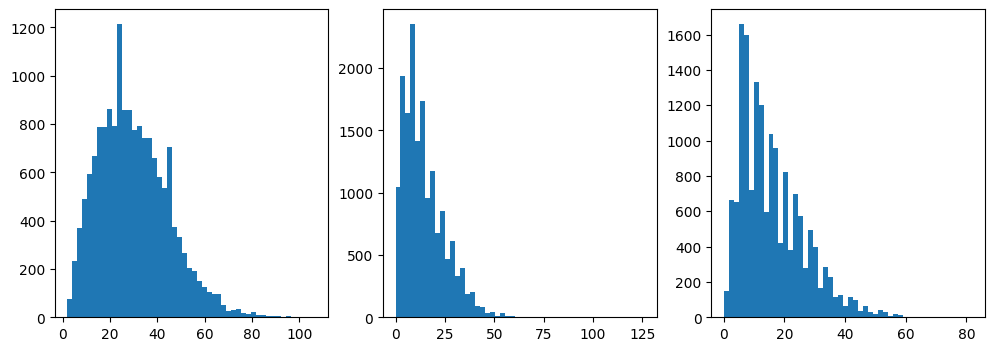

In [219]:
desc = pd.concat([
    df_NO2_SF['valore'].describe(),
    df_NO2_GM['valore'].describe(),
    df_NO2_VC['valore'].describe()
], axis=1)

desc.columns = ['SF', 'GM', 'VC']

print(f'Queste sono le distribuzioni del NO2 per le tre centraline: {desc}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(df_NO2_SF['valore'],bins=50)
axes[1].hist(df_NO2_GM['valore'],bins=50)
axes[2].hist(df_NO2_VC['valore'],bins=50)

plt.show()

## CONFRONTO PM2.5

Queste sono le distribuzioni del NO2 per le tre centraline:                SF          GM
count  680.000000  678.000000
mean    13.989706   13.922566
std     11.629081   12.090909
min      0.000000    1.000000
25%      7.000000    6.000000
50%     10.000000   10.000000
75%     18.000000   17.000000
max     82.000000   96.000000


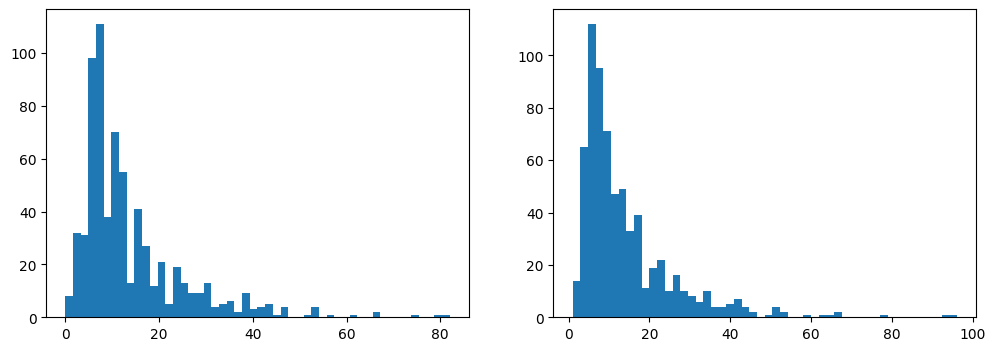

In [220]:
desc = pd.concat([
    df_merge_SF['PM2.5'].describe(),
    df_merge_GM['PM2.5'].describe(),
], axis=1)

desc.columns = ['SF', 'GM']

print(f'Queste sono le distribuzioni del NO2 per le tre centraline: {desc}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_merge_SF['PM2.5'],bins=50)
axes[1].hist(df_merge_GM['PM2.5'],bins=50)

plt.show()

## CONFRONTO O3

Queste sono le distribuzioni del NO2 per le tre centraline:                  GM            VC
count  16290.000000  16245.000000
mean      46.027072     42.668144
std       35.319423     36.900828
min        0.000000      0.000000
25%       16.000000     12.000000
50%       39.000000     34.000000
75%       72.000000     64.000000
max      185.000000    210.000000


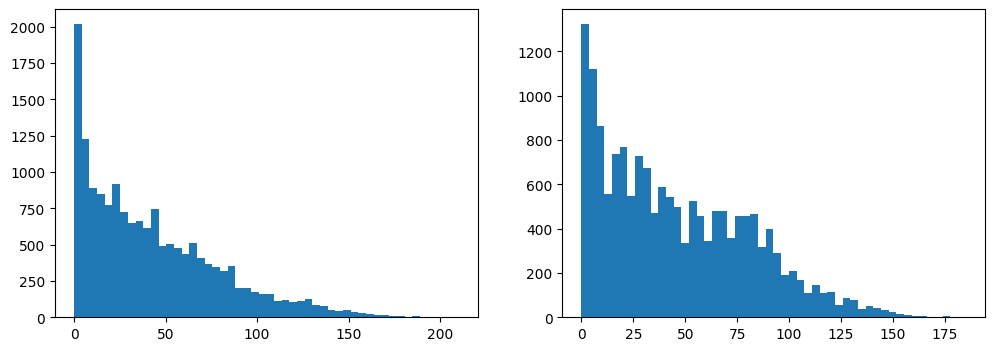

In [221]:

desc = pd.concat([
    df_O3_GM['valore'].describe(),
    df_O3_VC['valore'].describe()
], axis=1)

desc.columns = ['GM', 'VC']

print(f'Queste sono le distribuzioni del NO2 per le tre centraline: {desc}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_O3_VC['valore'],bins=50)
axes[1].hist(df_O3_GM['valore'],bins=50)

plt.show()

## ANDAMENTO TEMPORALE DELLE VARIABILI

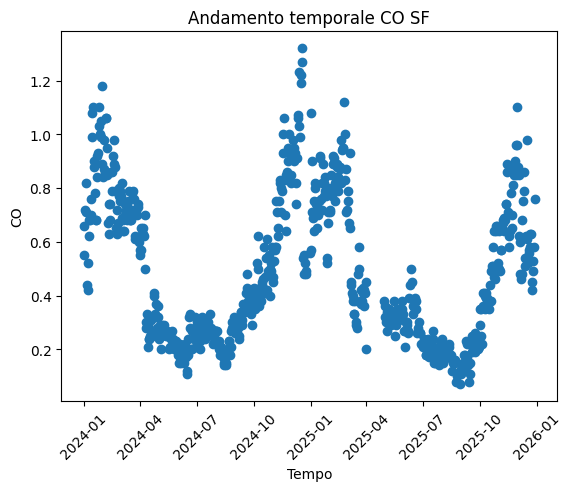

In [222]:

plt.scatter(df_merge_SF['giorno'],df_merge_SF['media_CO'])
plt.title("Andamento temporale CO SF")
plt.xlabel("Tempo")
plt.ylabel("CO")
plt.xticks(rotation=45)
plt.show()

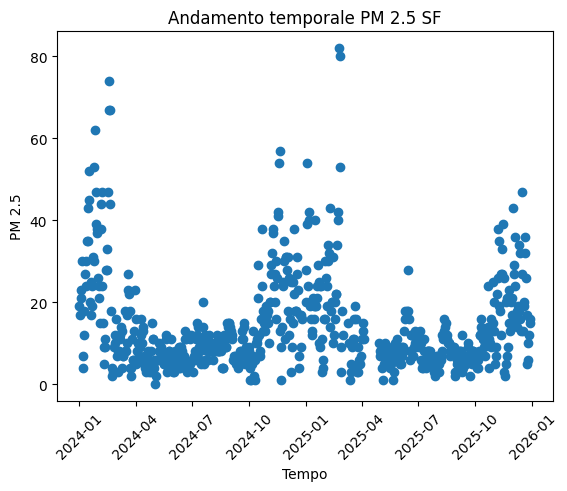

In [223]:
plt.scatter(df_merge_SF['giorno'],df_merge_SF['PM2.5'])
plt.title("Andamento temporale PM 2.5 SF")
plt.xlabel("Tempo")
plt.ylabel("PM 2.5")
plt.xticks(rotation=45)
plt.show()

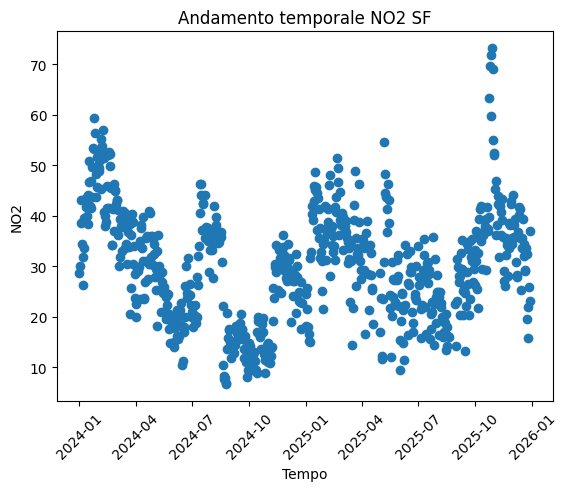

In [224]:
plt.scatter(df_merge_SF['giorno'],df_merge_SF['media_NO2'])
plt.title("Andamento temporale NO2 SF")
plt.xlabel("Tempo")
plt.ylabel("NO2")
plt.xticks(rotation=45)
plt.show()

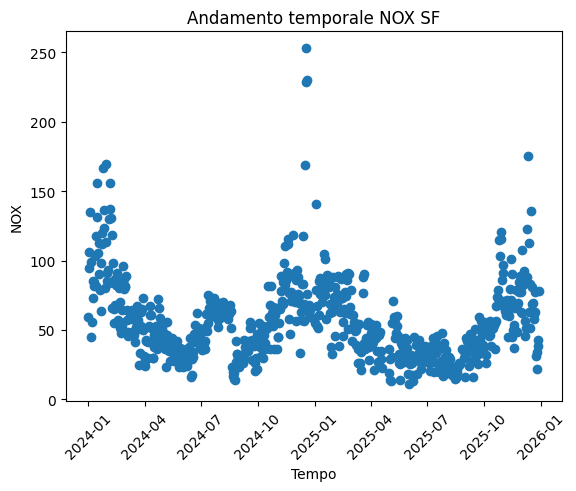

In [225]:
plt.scatter(df_merge_SF['giorno'],df_merge_SF['media_NOX'])
plt.title("Andamento temporale NOX SF")
plt.xlabel("Tempo")
plt.ylabel("NOX")
plt.xticks(rotation=45)
plt.show()

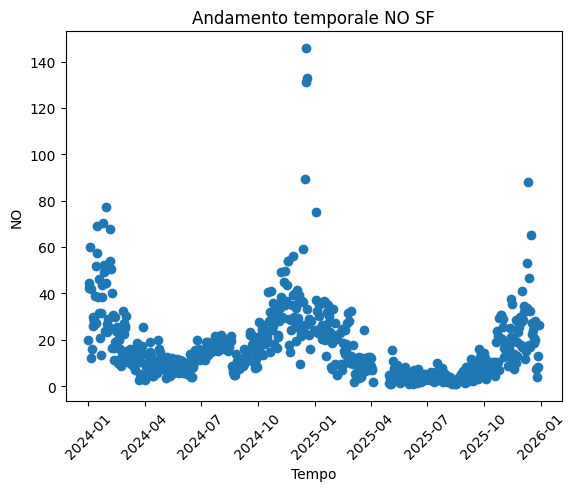

In [226]:
plt.scatter(df_merge_SF['giorno'],df_merge_SF['media_NO'])
plt.title("Andamento temporale NO SF")
plt.xlabel("Tempo")
plt.ylabel("NO")
plt.xticks(rotation=45)
plt.show()

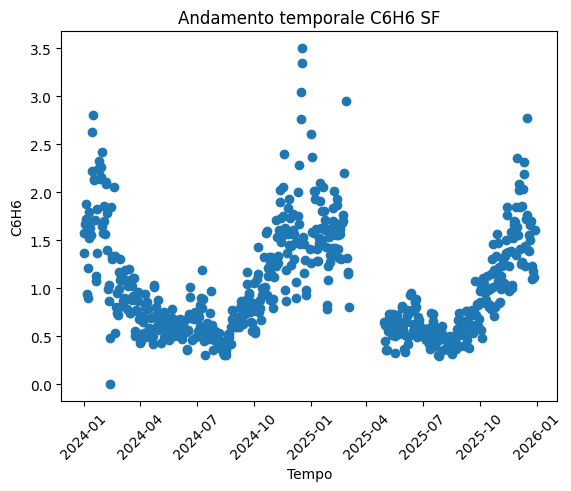

In [227]:
plt.scatter(df_merge_SF['giorno'],df_merge_SF['media_C6H6'])
plt.title("Andamento temporale C6H6 SF")
plt.xlabel("Tempo")
plt.ylabel("C6H6")
plt.xticks(rotation=45)
plt.show()

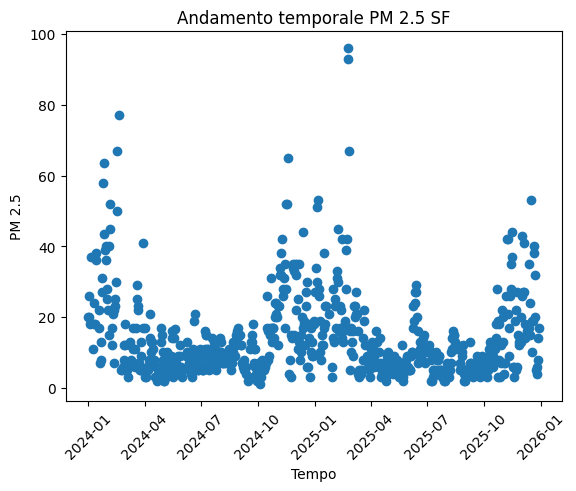

In [228]:
plt.scatter(df_merge_GM['giorno'],df_merge_GM['PM2.5'])
plt.title("Andamento temporale PM 2.5 SF")
plt.xlabel("Tempo")
plt.ylabel("PM 2.5")
plt.xticks(rotation=45)
plt.show()

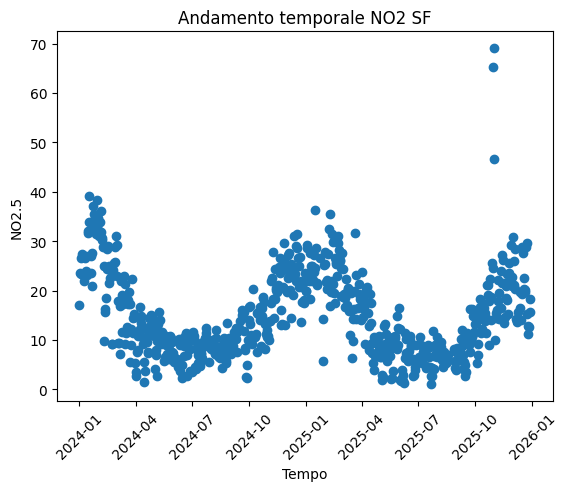

In [229]:
plt.scatter(df_merge_GM['giorno'],df_merge_GM['media_NO2'])
plt.title("Andamento temporale NO2 SF")
plt.xlabel("Tempo")
plt.ylabel("NO2.5")
plt.xticks(rotation=45)
plt.show()

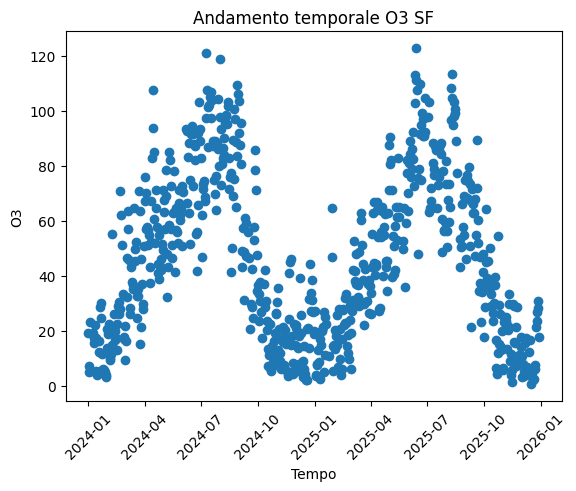

In [230]:
plt.scatter(df_merge_GM['giorno'],df_merge_GM['media_O3'])
plt.title("Andamento temporale O3 SF")
plt.xlabel("Tempo")
plt.ylabel("O3")
plt.xticks(rotation=45)
plt.show()

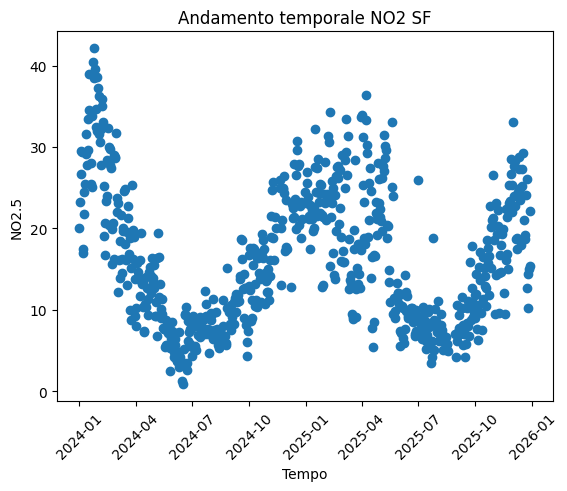

In [231]:
plt.scatter(df_merge_VC['giorno'],df_merge_VC['media_NO2'])
plt.title("Andamento temporale NO2 SF")
plt.xlabel("Tempo")
plt.ylabel("NO2.5")
plt.xticks(rotation=45)
plt.show()

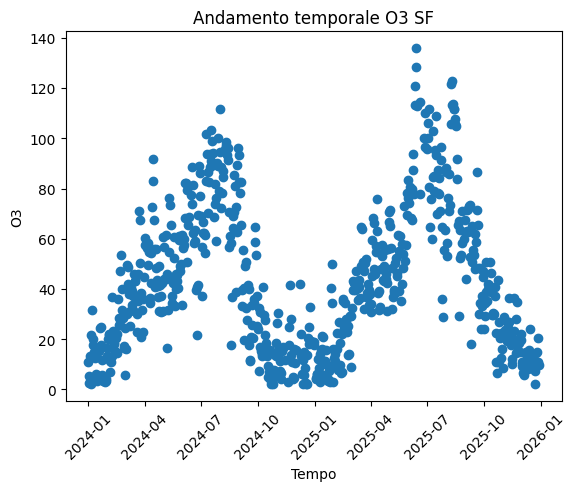

In [232]:
plt.scatter(df_merge_VC['giorno'],df_merge_VC['media_O3'])
plt.title("Andamento temporale O3 SF")
plt.xlabel("Tempo")
plt.ylabel("O3")
plt.xticks(rotation=45)
plt.show()

# IMPUTAZIONE DEI MISSING

*Strategia generale:* 

* Gap brevi: interpolazione lineare limitata.
* Gap lunghi: uso di centraline alternative (dato che abbiamo osservato che le varie centraline hanno distribuzioni simili per agenti) quando possibile, altrimenti utilizzare i dati degli anni precedenti (sempre osservando le distribuzioni degli agenti).

Per decidere la strategia da seguire si fa riferimento a questo articolo
https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0306303


In [233]:
#creo dataframe che riempirò
df_filled_SF = df_merge_SF.copy()
df_filled_GM = df_merge_GM.copy()
df_filled_VC = df_merge_VC.copy()

## IMPUTAZIONE PM2.5

*PM2.5 è misurato solo dalle centraline SF (San Felice) e GM (Giardini MArgherita)*


Per prima cosa stampo, per entrambi i df, le righe in cui il valore di PM2.5 è missing per farmi un'idea di che tipo di missing si tratta (manca solo quel valore, ne mancano altri, sono giorni isolati)

In [234]:
#righe missing SF
df_merge_SF.loc[(df_merge_SF['PM2.5'].isna()),:]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6
89,2024-03-31,129.0,NaN,0.57,0.6,0.7,31.46,30.0,53.0,23.71,24.0,40.0,5.04,4.0,14.0,0.52,0.5,0.9
418,2025-03-02,26.0,NaN,0.75,0.7,1.1,41.73,44.0,56.0,33.17,30.0,62.0,11.00,10.0,14.0,1.17,1.0,2.0
419,2025-03-03,22.0,NaN,0.79,0.7,1.5,60.87,60.0,164.0,38.38,40.5,79.0,17.56,15.0,56.0,1.15,1.0,3.3
420,2025-03-04,29.0,NaN,0.67,0.6,0.8,52.04,50.0,136.0,37.29,34.0,87.0,9.67,9.5,32.0,0.80,0.8,0.8
421,2025-03-05,33.0,NaN,0.93,0.8,1.2,55.88,47.5,190.0,38.08,34.5,92.0,1.67,2.0,2.0,NaN,NaN,NaN
422,2025-03-06,33.0,NaN,0.65,0.6,0.9,52.54,53.0,96.0,39.00,37.5,70.0,11.17,11.0,13.0,NaN,NaN,NaN
423,2025-03-07,28.0,NaN,0.45,0.4,0.7,49.42,46.5,97.0,36.88,36.0,67.0,5.43,3.0,18.0,NaN,NaN,NaN
424,2025-03-08,28.0,NaN,0.44,0.4,1.2,49.92,38.5,200.0,35.67,29.5,96.0,9.38,6.0,68.0,NaN,NaN,NaN
425,2025-03-09,32.0,NaN,0.41,0.4,0.6,39.38,40.5,61.0,30.62,31.0,47.0,5.71,6.0,11.0,NaN,NaN,NaN
428,2025-03-12,9.0,NaN,0.33,0.3,0.6,36.50,36.5,37.0,31.54,28.5,79.0,9.30,6.0,40.0,NaN,NaN,NaN


In [235]:
#righe missing GM
df_filled_GM.loc[(df_filled_GM['PM2.5'].isna()),:]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2
11,2024-01-15,44.0,4.21,3.0,15.0,NaN,32.12,32.0,46.0
12,2024-01-16,55.0,3.96,3.0,14.0,NaN,33.88,35.5,61.0
13,2024-01-17,45.0,5.00,3.5,13.0,NaN,39.17,38.0,49.0
45,2024-02-18,86.0,28.92,20.0,79.0,NaN,21.50,20.0,39.0
47,2024-02-20,45.0,26.12,22.0,63.0,NaN,24.17,22.5,49.0
48,2024-02-21,21.0,27.88,25.0,60.0,NaN,24.75,20.5,55.0
49,2024-02-22,5.0,70.79,79.5,90.0,NaN,9.29,4.0,51.0
85,2024-03-31,113.0,50.79,53.5,79.0,NaN,5.43,4.0,13.0
307,2024-11-19,74.0,3.54,3.0,6.0,NaN,26.67,27.0,43.0
308,2024-11-20,29.0,24.21,27.5,58.0,NaN,23.58,21.0,35.0


### SF 

Filliamo SF con i valori del PM2.5 registrati da GM

In [236]:
#conto quanti missing ci sono
df_filled_SF['PM2.5'].isna().sum()

np.int64(26)

In [237]:
#mi stampo i giorni in cui PM2.5 è missing in SF
df_filled_SF.loc[(df_filled_SF['PM2.5'].isna()),:]['giorno']

89     2024-03-31
418    2025-03-02
419    2025-03-03
420    2025-03-04
421    2025-03-05
422    2025-03-06
423    2025-03-07
424    2025-03-08
425    2025-03-09
428    2025-03-12
445    2025-03-30
451    2025-04-05
452    2025-04-06
453    2025-04-07
454    2025-04-08
455    2025-04-09
456    2025-04-10
457    2025-04-11
458    2025-04-12
459    2025-04-13
460    2025-04-14
461    2025-04-15
462    2025-04-16
463    2025-04-17
464    2025-04-18
465    2025-04-19
Name: giorno, dtype: object

In [238]:
#creo lista con i giorni in cui PM2.5 è missing in SF
lista_missing_PM2 = [
    "2024-03-31",
    "2025-03-02",
    "2025-03-03",
    "2025-03-04",
    "2025-03-05",
    "2025-03-06",
    "2025-03-07",
    "2025-03-08",
    "2025-03-09",
    "2025-03-12",
    "2025-03-30",
    "2025-04-05",
    "2025-04-06",
    "2025-04-07",
    "2025-04-08",
    "2025-04-09",
    "2025-04-10",
    "2025-04-11",
    "2025-04-12",
    "2025-04-13",
    "2025-04-14",
    "2025-04-15",
    "2025-04-16",
    "2025-04-17",
    "2025-04-18",
    "2025-04-19",
]

lista_missing_PM2 = pd.to_datetime(lista_missing_PM2)
#controllo lunghezza della lista (voglio che sia 26)
len(lista_missing_PM2)

26

In [239]:
#trasformo per sicurezza i valori della colonna giorno dei due df nello stesso formato (datetime)

df_filled_SF["giorno"] = pd.to_datetime(df_filled_SF["giorno"])
df_filled_GM["giorno"] = pd.to_datetime(df_filled_GM["giorno"])

In [240]:
# creo una flag che mi dice in quali giorni PM2.5 è missing
df_filled_SF['flag_PM25_missing'] = pd.to_datetime(df_filled_SF['giorno']).isin(lista_missing_PM2)

df_filled_SF.flag_PM25_missing.value_counts()

flag_PM25_missing
False    680
True      26
Name: count, dtype: int64

In [241]:
#creo minidataframe che contiene solo data e valore di PM2.5 registrato da GM
mappa_PM2 = df_filled_GM.set_index("giorno")["PM2.5"]

#creo flag che mi dice se il giorno in df_filled_SF sta 
# nella lista dei giorni da riempire
mask_PM2 = df_filled_SF["giorno"].isin(lista_missing_PM2)

#riempio le caselle della colonna PM2.5 che stanno nelle righe 
# flagged con i valori di PM2.5 del df GM
df_filled_SF.loc[mask_PM2, "PM2.5"] = df_filled_SF.loc[mask_PM2, "giorno"].map(mappa_PM2)

In [242]:
#controllo se sono rimasti dei missing

df_filled_SF.loc[(df_filled_SF['PM2.5'].isna()),:]

#ce ne sono due isolati, li posso riempire interpolando

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing
89,2024-03-31,129.0,NaN,0.57,0.6,0.7,31.46,30.0,53.0,23.71,24.0,40.0,5.04,4.0,14.0,0.52,0.5,0.9,True
445,2025-03-30,15.0,NaN,0.41,0.4,0.7,37.76,36.0,71.0,27.50,28.0,51.0,7.00,7.0,13.0,NaN,NaN,NaN,True


In [243]:
#riempio i due valori rimasti interpolando
df_filled_SF['PM2.5'] = df_filled_SF['PM2.5'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

In [244]:
#flaggo i valori che ho riempito con la torretta GM
lista_filled_PM25 =  [
    "2025-03-02",
    "2025-03-03",
    "2025-03-04",
    "2025-03-05",
    "2025-03-06",
    "2025-03-07",
    "2025-03-08",
    "2025-03-09",
    "2025-03-12",
    "2025-04-05",
    "2025-04-06",
    "2025-04-07",
    "2025-04-08",
    "2025-04-09",
    "2025-04-10",
    "2025-04-11",
    "2025-04-12",
    "2025-04-13",
    "2025-04-14",
    "2025-04-15",
    "2025-04-16",
    "2025-04-17",
    "2025-04-18",
    "2025-04-19",
]
lista_filled_PM25 = pd.to_datetime(lista_filled_PM25)

df_filled_SF['flag_PM25_GM'] =  df_filled_SF['giorno'].isin(lista_filled_PM25)


In [245]:
#controllo di aver flaggato 24 righe

df_filled_SF.flag_PM25_GM.value_counts()

flag_PM25_GM
False    682
True      24
Name: count, dtype: int64

In [246]:
#flaggo i valori che ho interpolato
lista_interpol_PM25 = ["2024-03-31", "2025-03-30"]
lista_interpol_PM25 = pd.to_datetime(lista_interpol_PM25)

df_filled_SF['flag_PM25_interpol'] = df_filled_SF['giorno'].isin(lista_interpol_PM25)

In [247]:
#controllo di avere flaggato 2 righe
df_filled_SF.flag_PM25_interpol.value_counts()

flag_PM25_interpol
False    704
True       2
Name: count, dtype: int64

In [248]:
#confronto missing prima e dopo imputazione dei missing
df_merge_SF['PM2.5'].isna().sum(),  df_filled_SF['PM2.5'].isna().sum()


(np.int64(26), np.int64(0))

### GM

Ora faccio la stessa cosa invertendo i ruoli dei df SF e GM

In [249]:
#conto quanti missing ci sono
df_filled_GM['PM2.5'].isna().sum()

np.int64(14)

In [250]:
#stampo i giorni in cui PM2.5 è missing
df_filled_GM.loc[(df_merge_GM['PM2.5'].isna()),:]['giorno']

11    2024-01-15
12    2024-01-16
13    2024-01-17
45    2024-02-18
47    2024-02-20
48    2024-02-21
49    2024-02-22
85    2024-03-31
307   2024-11-19
308   2024-11-20
352   2025-01-03
429   2025-03-30
486   2025-05-27
599   2025-09-26
Name: giorno, dtype: datetime64[s]

In [251]:
#creo lista dei giorni in cui PM2.5 è missing, la converto in datetime e  ne
#controllo la lunghezza

lista_missing_PM25_GM =[
    "2024-01-15",
    "2024-01-16",
    "2024-01-17",
    "2024-02-18",
    "2024-02-20",
    "2024-02-21",
    "2024-02-22",
    "2024-03-31",
    "2024-11-19",
    "2024-11-20",
    "2025-01-03",
    "2025-03-30",
    "2025-05-27",
    "2025-09-26",
]

lista_missing_PM25_GM = pd.to_datetime(lista_missing_PM25_GM)

len(lista_missing_PM25_GM)

14

In [252]:
# creo una flag che mi dice in quali giorni PM2.5 è missing
df_filled_GM['flag_PM25_missing'] = df_filled_GM['giorno'].isin(lista_missing_PM25_GM)
df_filled_GM.flag_PM25_missing.value_counts()

flag_PM25_missing
False    678
True      14
Name: count, dtype: int64

In [253]:
#creo minidataframe che contiene solo data e valore di PM2.5 registrato da SF
mappa_PM2 = df_filled_SF.set_index("giorno")["PM2.5"]

#creo flag che mi dice se il giorno in df_filled_GM sta nella 
#lista dei giorni da riempire
mask_PM2 = df_filled_GM["giorno"].isin(lista_missing_PM25_GM)

#riempio le caselle della colonna PM2.5 che stanno nelle righe flagged 
#con i valori di PM2.5 del df SF
df_filled_GM.loc[mask_PM2, "PM2.5"] = df_filled_GM.loc[mask_PM2, "giorno"].map(mappa_PM2)

In [254]:
#controllo se sono rimesti dei missing 

df_filled_GM['PM2.5'].isna().sum()

#non ce ne sono

np.int64(0)

In [255]:
#creo flag (che sarà uguale a quella missing, ma comunque la metto)

df_filled_GM['flag_PM25_SF'] = df_filled_GM['flag_PM25_missing']
df_filled_GM.head(2)

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF
0,2024-01-01,20.0,19.00,18.0,42.0,20.0,17.12,18.0,27.0,False,False
1,2024-01-02,21.0,4.92,4.5,10.0,20.0,23.62,25.0,33.0,False,False


In [256]:
#controllo di aver flaggato 14 valori 
df_filled_GM.flag_PM25_SF.value_counts()

flag_PM25_SF
False    678
True      14
Name: count, dtype: int64

## IMPUTAZIONE O3

*O3 è misurato da Giardini Margherita e Via Chiarini*

Sostanzialmente ripeto lo stesso ragionamento usato sopra

### GM

In [257]:
#stampo i missing nella colonna media e guardo che siano missing anche mediana e massimo

df_filled_GM.loc[(df_filled_GM['media_O3'].isna()),:]

#lo sono

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF
478,2025-05-18,11.0,NaN,NaN,NaN,3.0,2.12,2.0,4.0,False,False
479,2025-05-19,10.0,NaN,NaN,NaN,5.0,2.38,2.0,7.0,False,False
480,2025-05-20,18.0,NaN,NaN,NaN,6.0,10.42,9.5,36.0,False,False
481,2025-05-21,17.0,NaN,NaN,NaN,12.0,10.54,11.0,16.0,False,False
482,2025-05-22,7.0,NaN,NaN,NaN,4.0,3.71,3.0,11.0,False,False
683,2025-12-21,45.0,NaN,NaN,NaN,40.0,19.62,20.5,26.0,False,False


In [258]:
#conto quanti sono

(df_filled_GM['media_O3'].isna()).sum()

np.int64(6)

In [259]:
#conto anche quelli per mediana e massimo (voglio che siano lo stesso numero)...

(df_filled_GM['mediana_O3'].isna()).sum()

np.int64(6)

In [260]:
(df_filled_GM['massimo_O3'].isna()).sum()

#...sono lo stesso numero 

np.int64(6)

In [261]:
#stampo i giorni in cui O3 è missing in GM

df_filled_GM.loc[(df_filled_GM['media_O3'].isna()),:]['giorno']

478   2025-05-18
479   2025-05-19
480   2025-05-20
481   2025-05-21
482   2025-05-22
683   2025-12-21
Name: giorno, dtype: datetime64[s]

In [262]:
#creo lista dei giorni in cui O3 è missing in GM, la converto in datetime 
# e ne stampo la lunghezza

lista_missing_O3_GM = ['2025-05-18',
                    '2025-05-19',
                    '2025-05-20',
                    '2025-05-21',
                    '2025-05-22',
                    '2025-12-21']

lista_missing_O3_GM = pd.to_datetime(lista_missing_O3_GM)
len(lista_missing_O3_GM)


6

In [263]:
# creo una flag che mi dice in quali giorni O3  è missing in GM

df_filled_GM['flag_O3_missing'] = df_filled_GM['giorno'].isin(lista_missing_O3_GM)
df_filled_GM.flag_O3_missing.value_counts()

flag_O3_missing
False    686
True       6
Name: count, dtype: int64

In [264]:
#trasformo i valori della colonna giorno VC in datetime

df_filled_VC["giorno"] = pd.to_datetime(df_filled_VC["giorno"])



In [265]:
#creo minidataframe che contiene solo data e valore di media, max e mediana di O3
#registrato da VC
mappa_media = df_filled_VC.set_index("giorno")["media_O3"]
mappa_max = df_filled_VC.set_index("giorno")["massimo_O3"]
mappa_mediana = df_filled_VC.set_index("giorno")["mediana_O3"]

#creo flag che mi dice se il giorno in df_filled_SF sta nella lista
# dei giorni da riempire
mask_O3 = df_filled_GM["giorno"].isin(lista_missing_O3_GM)

#riempio le caselle delle colonne relative a O3 che stanno nelle righe 
#flagged di GM con i valori di VC
df_filled_GM.loc[mask_O3, "media_O3"] = df_filled_GM.loc[mask_O3, "giorno"].map(mappa_media)
df_filled_GM.loc[mask_O3, "mediana_O3"] = df_filled_GM.loc[mask_O3, "giorno"].map(mappa_mediana)
df_filled_GM.loc[mask_O3, "massimo_O3"] = df_filled_GM.loc[mask_O3, "giorno"].map(mappa_max)

In [266]:
#controllo che non ci siano più missing

df_filled_GM.loc[(df_filled_GM['media_O3'].isna()),:]

#ce ne è uno isolato, lo posso riempire interpolando

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF,flag_O3_missing
478,2025-05-18,11.0,NaN,NaN,NaN,3.0,2.12,2.0,4.0,False,False,True


In [267]:
#controllo che anche nelle altre colonne ci sia solo un valore missing

(df_filled_GM['media_O3'].isna()).sum(), (df_filled_GM['mediana_O3'].isna()).sum(), (df_filled_GM['massimo_O3'].isna()).sum()

#anche nelle altre colonne c'è solo quel valore missing

(np.int64(1), np.int64(1), np.int64(1))

In [268]:
#riempio il valore rimasto interpolando

df_filled_GM['media_O3'] = df_filled_GM['media_O3'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

df_filled_GM['mediana_O3'] = df_filled_GM['mediana_O3'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)


df_filled_GM['massimo_O3'] = df_filled_GM['massimo_O3'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

In [269]:
#creo lista giorni riempiti con valori di VC

lista_filled_O3_GM = pd.to_datetime(['2025-05-19',
                    '2025-05-20',
                    '2025-05-21',
                    '2025-05-22',
                    '2025-12-21'])

In [270]:
#creo flag giorni riempiti con valori di O3 in VC e controllo di aver
#flaggato il numero giusto di righe

df_filled_GM['flag_O3_VC'] = df_filled_GM['giorno'].isin(lista_filled_O3_GM)

df_filled_GM.flag_O3_VC.value_counts()

flag_O3_VC
False    687
True       5
Name: count, dtype: int64

In [271]:
#creo lista giorni interpolati
lista_interpol_O3_GM = pd.to_datetime(['2025-05-18'])

#creo flag valori ottenuti con interpolazione e controllo numero flag
df_filled_GM['flag_O3_interpol'] = df_filled_GM['giorno'].isin(lista_interpol_O3_GM)
df_filled_GM.flag_O3_interpol.value_counts()

flag_O3_interpol
False    691
True       1
Name: count, dtype: int64

### VC

In [272]:
#stampo le righe in cui media_O3 è missing in VC e controllo che siano missing anche
#mediana e massimo

df_filled_VC.loc[(df_filled_VC['media_O3'].isna()),:]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2
477,2025-05-18,9.0,NaN,NaN,NaN,NaN,NaN,NaN
507,2025-06-21,21.0,NaN,NaN,NaN,10.21,10.0,18.0
508,2025-06-22,11.0,NaN,NaN,NaN,8.58,7.5,18.0
509,2025-06-23,9.0,NaN,NaN,NaN,9.00,9.0,9.0
510,2025-06-24,14.0,NaN,NaN,NaN,NaN,NaN,NaN
511,2025-06-25,20.0,NaN,NaN,NaN,6.79,6.0,15.0
541,2025-07-28,5.0,NaN,NaN,NaN,10.17,11.5,15.0


In [273]:
#conto quanti sono i missing per la media

(df_filled_VC['media_O3'].isna()).sum()

np.int64(7)

In [274]:
#conto anche quelli per mediana e massimo (voglio che siano lo stesso numero)...

(df_filled_VC['mediana_O3'].isna()).sum()

np.int64(7)

In [275]:
(df_filled_VC['massimo_O3'].isna()).sum()

#...sono lo stesso numero 

np.int64(7)

In [276]:
#stampo i giorni in cui O3 è missing in VC

df_filled_VC.loc[(df_filled_VC['media_O3'].isna()),:]['giorno']

477   2025-05-18
507   2025-06-21
508   2025-06-22
509   2025-06-23
510   2025-06-24
511   2025-06-25
541   2025-07-28
Name: giorno, dtype: datetime64[s]

In [277]:
#creo lista in cui O3 è missing, la converto in datetime
#  e ne controllo la lunghezza

lista_missing_O3_VC = ['2025-05-18',
                       '2025-06-21', 
                       '2025-06-22',
                       '2025-06-23',
                       '2025-06-24',
                       '2025-06-25',
                       '2025-07-28']

lista_missing_O3_VC = pd.to_datetime(lista_missing_O3_VC)

len(lista_missing_O3_VC) 


7

In [278]:
#trasformo i valori della colonna in datetime
df_filled_VC["giorno"] = pd.to_datetime(df_filled_VC["giorno"])

In [279]:
# creo una flag che mi dice in quali giorni O3  è missing in VC

df_filled_VC['flag_O3_missing'] = df_filled_VC['giorno'].isin(lista_missing_O3_VC)
df_filled_VC.flag_O3_missing.value_counts()

flag_O3_missing
False    685
True       7
Name: count, dtype: int64

In [280]:
#creo minidataframe che contiene solo data e valore di media, max e mediana di O3
# registrato da GM
mappa_media = df_filled_GM.set_index("giorno")["media_O3"]
mappa_max = df_filled_GM.set_index("giorno")["massimo_O3"]
mappa_mediana = df_filled_GM.set_index("giorno")["mediana_O3"]

#creo flag che mi dice se il giorno in df_filled_VC sta nella 
# lista dei giorni da riempire
mask_O3 = df_filled_VC["giorno"].isin(lista_missing_O3_VC)

#riempio le caselle delle colonne relative a O3 che stanno nelle
#  righe flagged di VC con i valori di GM
df_filled_VC.loc[mask_O3, "media_O3"] = df_filled_VC.loc[mask_O3, "giorno"].map(mappa_media)
df_filled_VC.loc[mask_O3, "mediana_O3"] = df_filled_VC.loc[mask_O3, "giorno"].map(mappa_mediana)
df_filled_VC.loc[mask_O3, "massimo_O3"] = df_filled_VC.loc[mask_O3, "giorno"].map(mappa_max)


In [281]:
#controllo che non ci siano più missing
df_filled_VC.loc[(df_filled_VC['media_O3'].isna()),:]


,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2,flag_O3_missing


In [282]:
#creo flag giorni riempiti con valori di O3 in GM

df_filled_VC['flag_O3_GM'] = df_filled_VC['giorno'].isin(lista_missing_O3_VC)
df_filled_VC.flag_O3_GM.value_counts()

flag_O3_GM
False    685
True       7
Name: count, dtype: int64

## IMPUTAZIONE NO2

*NO2 è disponibile su tutte e tre le centraline: i missing possono essere trattati usando confronti tra centraline e, se necessario, storico.*

Per prima costa stampo i missing di media_NO2 dei tre df per farmi un'idea di quali giorni sono missing

In [283]:
df_filled_SF.loc[(df_filled_SF['media_NO2'].isna()), :]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol
459,2025-04-13,10.0,6.0,NaN,NaN,NaN,26.74,28.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False
466,2025-04-29,22.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
519,2025-06-24,18.0,9.0,0.28,0.3,0.5,29.88,28.5,63.0,NaN,NaN,NaN,3.54,3.0,10.0,0.60,0.6,1.6,False,False,False
574,2025-08-20,22.0,10.0,0.16,0.2,0.2,24.25,24.0,43.0,NaN,NaN,NaN,2.71,2.0,7.0,0.37,0.4,0.6,False,False,False
575,2025-08-21,15.0,7.0,0.16,0.2,0.3,26.12,25.0,39.0,NaN,NaN,NaN,3.96,4.0,8.0,0.45,0.4,0.9,False,False,False
576,2025-08-22,14.0,8.0,0.15,0.1,0.3,24.52,22.0,50.0,NaN,NaN,NaN,3.24,2.0,11.0,0.45,0.4,0.7,False,False,False
577,2025-08-23,14.0,9.0,0.16,0.1,0.4,25.33,24.0,38.0,NaN,NaN,NaN,3.04,3.0,7.0,0.48,0.5,0.9,False,False,False
578,2025-08-24,14.0,8.0,0.08,0.1,0.2,NaN,NaN,NaN,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False
579,2025-08-25,16.0,8.0,0.10,0.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False
580,2025-08-26,19.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False


In [284]:
df_filled_VC.loc[(df_filled_VC['media_NO2'].isna()), :]



,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2,flag_O3_missing,flag_O3_GM
476,2025-05-17,2.0,39.000,39.0,39.0,NaN,NaN,NaN,False,False
477,2025-05-18,9.0,62.955,61.5,75.0,NaN,NaN,NaN,True,True
510,2025-06-24,14.0,97.170,97.5,115.0,NaN,NaN,NaN,True,True
563,2025-08-19,14.0,83.830,87.0,131.0,NaN,NaN,NaN,False,False
564,2025-08-20,21.0,65.540,66.5,125.0,NaN,NaN,NaN,False,False
565,2025-08-21,17.0,29.170,24.0,67.0,NaN,NaN,NaN,False,False
566,2025-08-22,11.0,67.080,68.5,131.0,NaN,NaN,NaN,False,False
567,2025-08-23,11.0,63.540,49.0,128.0,NaN,NaN,NaN,False,False
568,2025-08-24,12.0,52.250,52.0,81.0,NaN,NaN,NaN,False,False
569,2025-08-25,12.0,53.500,52.0,116.0,NaN,NaN,NaN,False,False


In [285]:
df_filled_GM.loc[(df_filled_GM['media_NO2'].isna()), :]

#i suoi missing sono un sottoinx dei missing di VC

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF,flag_O3_missing,flag_O3_VC,flag_O3_interpol
565,2025-08-23,14.0,53.48,41.0,113.0,7.0,NaN,NaN,NaN,False,False,False,False,False
566,2025-08-24,16.0,43.33,44.5,70.0,5.0,NaN,NaN,NaN,False,False,False,False,False
567,2025-08-25,15.0,50.58,49.0,97.0,6.0,NaN,NaN,NaN,False,False,False,False,False
568,2025-08-26,17.0,66.21,60.0,119.0,9.0,NaN,NaN,NaN,False,False,False,False,False


Dopo aver osservato i missing, decido di riempire SF con i valori di GM e utilizzare i valori registrati dalla torretta SF negli anni precedenti al 2024 per riempire eventuali missing rimasti

### SF

In [286]:
#stampo i missing media_NO2 in SF e guardo che siano missing anche max e mediana

df_filled_SF.loc[df_filled_SF['media_NO2'].isna(), :]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol
459,2025-04-13,10.0,6.0,NaN,NaN,NaN,26.74,28.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,False
466,2025-04-29,22.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
519,2025-06-24,18.0,9.0,0.28,0.3,0.5,29.88,28.5,63.0,NaN,NaN,NaN,3.54,3.0,10.0,0.60,0.6,1.6,False,False,False
574,2025-08-20,22.0,10.0,0.16,0.2,0.2,24.25,24.0,43.0,NaN,NaN,NaN,2.71,2.0,7.0,0.37,0.4,0.6,False,False,False
575,2025-08-21,15.0,7.0,0.16,0.2,0.3,26.12,25.0,39.0,NaN,NaN,NaN,3.96,4.0,8.0,0.45,0.4,0.9,False,False,False
576,2025-08-22,14.0,8.0,0.15,0.1,0.3,24.52,22.0,50.0,NaN,NaN,NaN,3.24,2.0,11.0,0.45,0.4,0.7,False,False,False
577,2025-08-23,14.0,9.0,0.16,0.1,0.4,25.33,24.0,38.0,NaN,NaN,NaN,3.04,3.0,7.0,0.48,0.5,0.9,False,False,False
578,2025-08-24,14.0,8.0,0.08,0.1,0.2,NaN,NaN,NaN,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False
579,2025-08-25,16.0,8.0,0.10,0.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False
580,2025-08-26,19.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False


In [287]:
#conto i missing media 

(df_filled_SF['media_NO2'].isna()).sum()

np.int64(13)

In [288]:
#conto anche quelli per mediana e massimo (voglio che siano lo stesso numero)...

(df_filled_SF['mediana_NO2'].isna()).sum()

np.int64(13)

In [289]:
(df_filled_SF['massimo_NO2'].isna()).sum()

#...sono lo stesso numero 

np.int64(13)

In [290]:
#stampo i giorni in cui ho i missing 

df_filled_SF.loc[(df_filled_SF['media_NO2'].isna()), :]['giorno']

459   2025-04-13
466   2025-04-29
519   2025-06-24
574   2025-08-20
575   2025-08-21
576   2025-08-22
577   2025-08-23
578   2025-08-24
579   2025-08-25
580   2025-08-26
581   2025-08-27
582   2025-08-28
583   2025-08-29
Name: giorno, dtype: datetime64[s]

In [291]:
#creo lista

lista_missing_NO2_SF = ['2025-04-13',
                        '2025-04-29',
                        '2025-06-24',
                        '2025-08-20',
                        '2025-08-21',
                        '2025-08-22',
                        '2025-08-23',
                        '2025-08-24',
                        '2025-08-25',
                        '2025-08-26',
                        '2025-08-27',
                        '2025-08-28',
                        '2025-08-29']
lista_missing_NO2_SF = pd.to_datetime(lista_missing_NO2_SF)
len(lista_missing_NO2_SF)


13

In [292]:
# creo una flag che mi dice in quali giorni NO2 è missing in SF

df_filled_SF['flag_NO2_missing'] = df_filled_SF['giorno'].isin(lista_missing_NO2_SF)
df_filled_SF.flag_NO2_missing.value_counts()

flag_NO2_missing
False    693
True      13
Name: count, dtype: int64

In [293]:
#creo minidataframe che contiene solo data e valore di 
# media_NO2, max e mediana registrato da GM
mappa_media = df_filled_GM.set_index("giorno")["media_NO2"]
mappa_max = df_filled_GM.set_index("giorno")["massimo_NO2"]
mappa_mediana = df_filled_GM.set_index("giorno")["mediana_NO2"]

#creo flag che mi dice se il giorno in df_filled_SF 
# sta nella lista dei giorni da riempire
mask_NO2 = df_filled_SF["giorno"].isin(lista_missing_NO2_SF)

#riempio le caselle delle colonne relative a NO2 che
#  stanno nelle righe flagged di SF con i valori di GM
df_filled_SF.loc[mask_NO2, "media_NO2"] = df_filled_SF.loc[mask_NO2, "giorno"].map(mappa_media)
df_filled_SF.loc[mask_NO2, "mediana_NO2"] = df_filled_SF.loc[mask_NO2, "giorno"].map(mappa_mediana)
df_filled_SF.loc[mask_NO2, "massimo_NO2"] = df_filled_SF.loc[mask_NO2, "giorno"].map(mappa_max)

In [294]:
(df_filled_SF['media_NO2'].isna()).sum()

np.int64(7)

In [295]:
df_filled_SF.loc[(df_filled_SF['media_NO2'].isna()), :]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing
574,2025-08-20,22.0,10.0,0.16,0.2,0.2,24.25,24.0,43.0,NaN,NaN,NaN,2.71,2.0,7.0,0.37,0.4,0.6,False,False,False,True
575,2025-08-21,15.0,7.0,0.16,0.2,0.3,26.12,25.0,39.0,NaN,NaN,NaN,3.96,4.0,8.0,0.45,0.4,0.9,False,False,False,True
576,2025-08-22,14.0,8.0,0.15,0.1,0.3,24.52,22.0,50.0,NaN,NaN,NaN,3.24,2.0,11.0,0.45,0.4,0.7,False,False,False,True
577,2025-08-23,14.0,9.0,0.16,0.1,0.4,25.33,24.0,38.0,NaN,NaN,NaN,3.04,3.0,7.0,0.48,0.5,0.9,False,False,False,True
578,2025-08-24,14.0,8.0,0.08,0.1,0.2,NaN,NaN,NaN,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False,True
579,2025-08-25,16.0,8.0,0.10,0.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False,True
580,2025-08-26,19.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False,True


In [296]:
#creo lista con valori di NO2 in SF riempiti da GM
lista_filled_NO2_SF = pd.to_datetime(['2025-04-13',
                        '2025-04-29',
                        '2025-06-24', 
                        '2025-08-27',
                        '2025-08-28',
                        '2025-08-29'])

In [297]:
# creo una flag che mi dice in quali giorni NO2 è stato riempito con valori di GM
df_filled_SF['flag_NO2_GM'] = df_filled_SF['giorno'].isin(lista_filled_NO2_SF)
df_filled_SF.flag_NO2_GM.value_counts()

flag_NO2_GM
False    700
True       6
Name: count, dtype: int64

### VC

In [298]:
df_filled_VC.loc[(df_filled_VC['media_NO2'].isna()), :]['giorno']

476   2025-05-17
477   2025-05-18
510   2025-06-24
563   2025-08-19
564   2025-08-20
565   2025-08-21
566   2025-08-22
567   2025-08-23
568   2025-08-24
569   2025-08-25
570   2025-08-26
571   2025-08-27
Name: giorno, dtype: datetime64[s]

In [299]:
lista_missing_NO2_VC= ['2025-05-17',
                       '2025-05-18',
                       '2025-06-24',
                       '2025-08-19',
                       '2025-08-20',
                       '2025-08-21',
                       '2025-08-22',
                       '2025-08-23',
                       '2025-08-24',
                       '2025-08-25',
                       '2025-08-26',
                       '2025-08-27']
lista_missing_NO2_VC = pd.to_datetime(lista_missing_NO2_VC)
len(lista_missing_NO2_VC)

12

In [300]:
# creo una flag che mi dice in quali giorni NO2 è missing in VC

df_filled_VC['flag_NO2_missing'] = df_filled_VC['giorno'].isin(lista_missing_NO2_VC)
df_filled_VC.flag_NO2_missing.value_counts()

flag_NO2_missing
False    680
True      12
Name: count, dtype: int64

In [301]:
#creo minidataframe che contiene solo data e valore di media_NO2, max e mediana registrato da GM
mappa_media = df_filled_GM.set_index("giorno")["media_NO2"]
mappa_max = df_filled_GM.set_index("giorno")["massimo_NO2"]
mappa_mediana = df_filled_GM.set_index("giorno")["mediana_NO2"]

#creo flag che mi dice se il giorno in df_filled_VC sta nella lista 
# dei giorni da riempire
mask_NO2 = df_filled_VC["giorno"].isin(lista_missing_NO2_VC)

#riempio le caselle delle colonne relative a NO2 che stanno 
# nelle righe flagged di VC con i valori di GM
df_filled_VC.loc[mask_NO2, "media_NO2"] = df_filled_VC.loc[mask_NO2, "giorno"].map(mappa_media)
df_filled_VC.loc[mask_NO2, "mediana_NO2"] = df_filled_VC.loc[mask_NO2, "giorno"].map(mappa_mediana)
df_filled_VC.loc[mask_NO2, "massimo_NO2"] = df_filled_VC.loc[mask_NO2, "giorno"].map(mappa_max)

In [302]:
(df_filled_VC['media_NO2'].isna()).sum()

np.int64(8)

In [303]:
df_filled_VC.loc[(df_filled_VC['media_NO2'].isna()), :]['giorno']

563   2025-08-19
564   2025-08-20
565   2025-08-21
566   2025-08-22
567   2025-08-23
568   2025-08-24
569   2025-08-25
570   2025-08-26
Name: giorno, dtype: datetime64[s]

In [ ]:
#creo lista di valori di NO2 riempiti con valori di GM
lista_filled_NO2_VC = ['2025-05-17',
                       '2025-05-18',
                       '2025-06-24',
                       '2025-08-27']
lista_filled_NO2_VC = pd.to_datetime(lista_filled_NO2_VC)

In [305]:
# creo una flag che mi dice in quali giorni NO2 è stato riempito con valori di GM
df_filled_VC['flag_NO2_VC'] = df_filled_VC['giorno'].isin(lista_filled_NO2_VC)
df_filled_VC.flag_NO2_VC.value_counts()

flag_NO2_VC
False    688
True       4
Name: count, dtype: int64

### GM

Per ora qua creo solo la flag di missing

In [306]:
df_filled_GM.loc[(df_filled_GM['media_NO2'].isna()), :]['giorno']

565   2025-08-23
566   2025-08-24
567   2025-08-25
568   2025-08-26
Name: giorno, dtype: datetime64[s]

In [307]:
lista_NO2_missing_GM = pd.to_datetime(['2025-08-23',
'2025-08-24',
'2025-08-25',
'2025-08-26'])

In [308]:
df_filled_GM['flag_NO2_missing'] = df_filled_GM['giorno'].isin(lista_NO2_missing_GM)
df_filled_GM['flag_NO2_missing'].value_counts()

flag_NO2_missing
False    688
True       4
Name: count, dtype: int64

Per quanto riguarda i missing di NO2 rimasti, dato che sono intervalli di tempo e non giornate isolate scelgo di imputarli utilizzando i df degli anni dal 2017 al 2023. Faccio la stessa cosa anche per gli agenti misurati solo dalla centralina SF.

# CONFRONTO DISTRIBUZIONI STORICHE E INTERPOLAZIONE

*Questa sezione usa lo storico per confrontare distribuzioni e supportare imputazioni nei giorni mancanti.*

In [309]:
#creo un df per centralina (2017-2025)
df_SF2 = df.loc[df['cod_staz'] == 'PORTA SAN FELICE', :]

df_GM2 = df.loc[df['cod_staz'] == 'GIARDINI MARGHERITA', :]

df_VC2 = df.loc[df['cod_staz'] == 'VIA CHIARINI', :]

## SF IMPUTAZIONE FINALE

### C6H6 (BENZENE)

In [310]:
#stampo le righe in cui ho media benzene missing
df_filled_SF.loc[(df_filled_SF['media_C6H6'].isna()), :]


,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM
47,2024-02-17,80.0,67.0,0.92,0.85,1.4,82.50,79.5,160.0,52.75,47.5,83.0,19.54,15.5,50.0,NaN,NaN,NaN,False,False,False,False,False
48,2024-02-18,87.0,74.0,0.89,0.80,1.4,56.92,45.0,131.0,41.67,33.5,75.0,9.96,6.5,37.0,NaN,NaN,NaN,False,False,False,False,False
290,2024-10-20,29.0,16.0,0.41,0.40,1.0,36.21,39.0,82.0,13.71,14.5,26.0,14.67,15.5,37.0,NaN,NaN,NaN,False,False,False,False,False
413,2025-02-25,74.0,53.0,1.00,1.00,1.4,90.54,87.0,181.0,39.29,37.5,57.0,28.10,25.0,93.0,NaN,NaN,NaN,False,False,False,False,False
414,2025-02-26,14.0,9.0,0.83,0.80,1.1,66.83,71.5,122.0,38.88,45.0,57.0,10.14,8.0,21.0,NaN,NaN,NaN,False,False,False,False,False
415,2025-02-27,16.0,3.0,0.71,0.70,1.1,61.83,64.0,138.0,38.13,38.0,61.0,12.00,15.0,16.0,NaN,NaN,NaN,False,False,False,False,False
421,2025-03-05,33.0,23.0,0.93,0.80,1.2,55.88,47.5,190.0,38.08,34.5,92.0,1.67,2.0,2.0,NaN,NaN,NaN,True,True,False,False,False
422,2025-03-06,33.0,23.0,0.65,0.60,0.9,52.54,53.0,96.0,39.00,37.5,70.0,11.17,11.0,13.0,NaN,NaN,NaN,True,True,False,False,False
423,2025-03-07,28.0,20.0,0.45,0.40,0.7,49.42,46.5,97.0,36.88,36.0,67.0,5.43,3.0,18.0,NaN,NaN,NaN,True,True,False,False,False
424,2025-03-08,28.0,21.0,0.44,0.40,1.2,49.92,38.5,200.0,35.67,29.5,96.0,9.38,6.0,68.0,NaN,NaN,NaN,True,True,False,False,False


In [311]:
#le conto
(df_filled_SF['media_C6H6'].isna()).sum()

np.int64(53)

In [312]:
#conto anche quelle di massimo...
(df_filled_SF['massimo_C6H6'].isna()).sum()

np.int64(53)

In [313]:
#...e mediana 
(df_filled_SF['mediana_C6H6'].isna()).sum()

np.int64(53)

In [314]:
#stampo giorni in cui il benzene è missing
df_filled_SF.loc[(df_filled_SF['media_C6H6'].isna()), :]['giorno']

47    2024-02-17
48    2024-02-18
290   2024-10-20
413   2025-02-25
414   2025-02-26
415   2025-02-27
421   2025-03-05
422   2025-03-06
423   2025-03-07
424   2025-03-08
425   2025-03-09
426   2025-03-10
427   2025-03-11
428   2025-03-12
429   2025-03-13
430   2025-03-14
431   2025-03-15
432   2025-03-16
433   2025-03-17
434   2025-03-19
435   2025-03-20
436   2025-03-21
437   2025-03-22
438   2025-03-23
439   2025-03-24
440   2025-03-25
441   2025-03-26
442   2025-03-27
443   2025-03-28
444   2025-03-29
445   2025-03-30
446   2025-03-31
447   2025-04-01
448   2025-04-02
449   2025-04-03
450   2025-04-04
451   2025-04-05
452   2025-04-06
453   2025-04-07
454   2025-04-08
455   2025-04-09
456   2025-04-10
457   2025-04-11
458   2025-04-12
459   2025-04-13
460   2025-04-14
461   2025-04-15
462   2025-04-16
463   2025-04-17
464   2025-04-18
465   2025-04-19
466   2025-04-29
656   2025-11-10
Name: giorno, dtype: datetime64[s]

In [315]:
#creo la lista dei giorni in cui il benzene è missing
lista_missing_C6H6_SF = ['2024-02-17',
'2024-02-18',
'2024-10-20',
'2025-02-25',
'2025-02-26',
'2025-02-27',
'2025-03-05',
'2025-03-06',
'2025-03-07',
'2025-03-08',
'2025-03-09',
'2025-03-10',
'2025-03-11',
'2025-03-12',
'2025-03-13',
'2025-03-14',
'2025-03-15',
'2025-03-16',
'2025-03-17',
'2025-03-19',
'2025-03-20',
'2025-03-21',
'2025-03-22',
'2025-03-23',
'2025-03-24',
'2025-03-25',
'2025-03-26',
'2025-03-27',
'2025-03-28',
'2025-03-29',
'2025-03-30',
'2025-03-31',
'2025-04-01',
'2025-04-02',
'2025-04-03',
'2025-04-04',
'2025-04-05',
'2025-04-06',
'2025-04-07',
'2025-04-08',
'2025-04-09',
'2025-04-10',
'2025-04-11',
'2025-04-12',
'2025-04-13',
'2025-04-14',
'2025-04-15',
'2025-04-16',
'2025-04-17',
'2025-04-18',
'2025-04-19',
'2025-04-29',
'2025-11-10']

lista_missing_C6H6_SF = pd.to_datetime(lista_missing_C6H6_SF)
len(lista_missing_C6H6_SF)

53

In [316]:
# creo una flag che mi dice in quali giorni C6H6 è missing
df_filled_SF['flag_C6H6_missing'] = df_filled_SF['giorno'].isin(lista_missing_C6H6_SF)
df_filled_SF.flag_C6H6_missing.value_counts()

flag_C6H6_missing
False    653
True      53
Name: count, dtype: int64

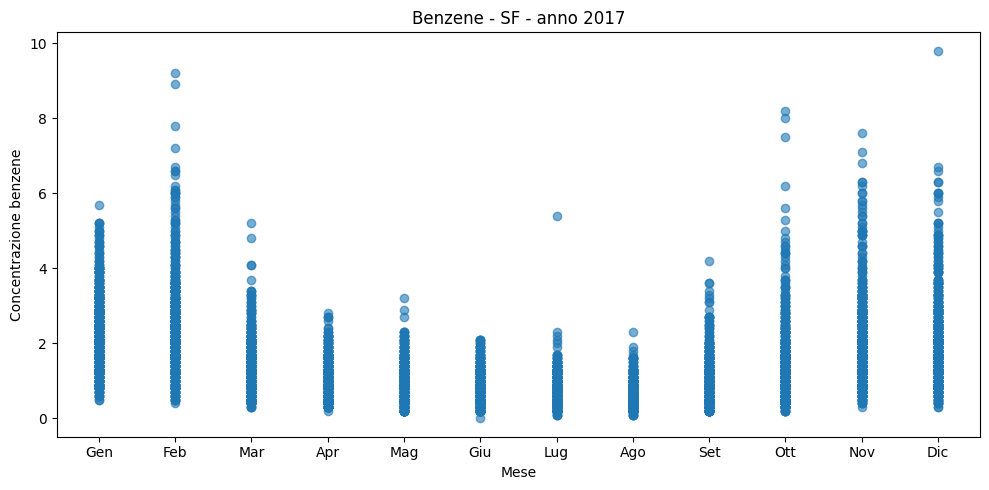

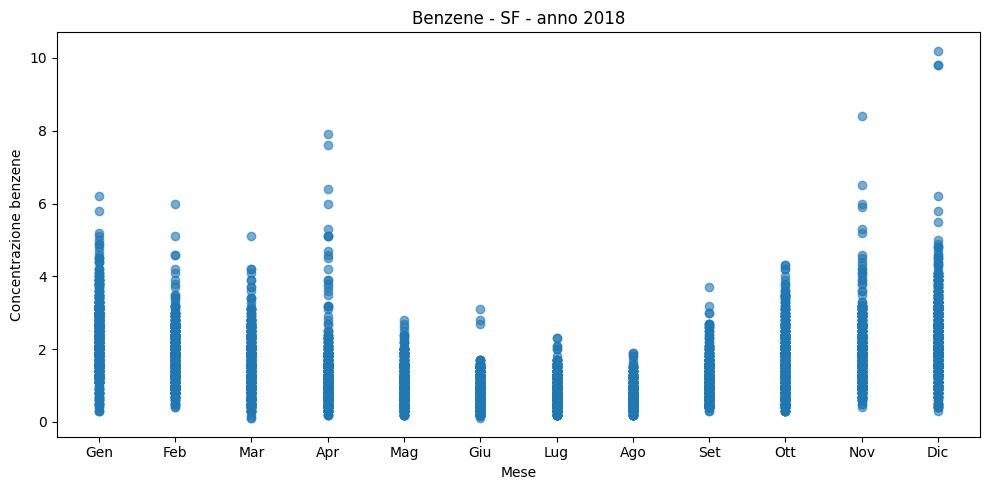

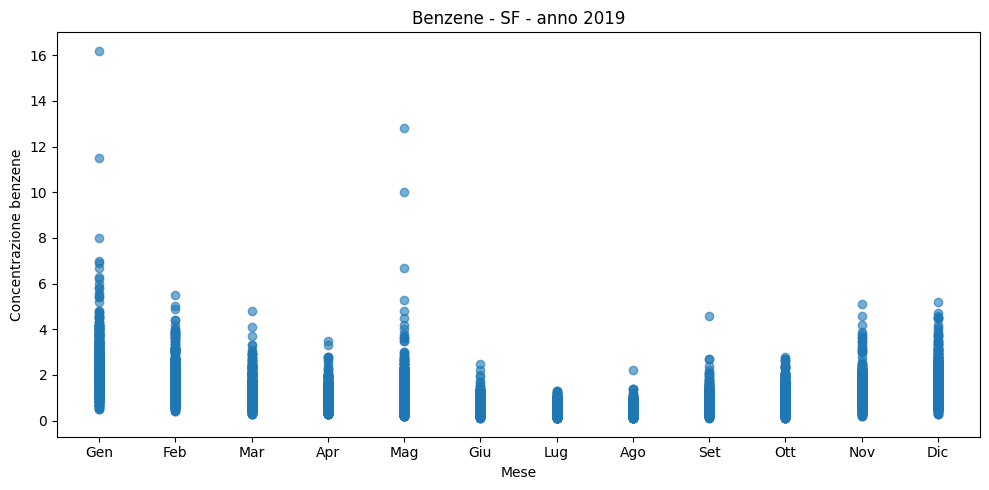

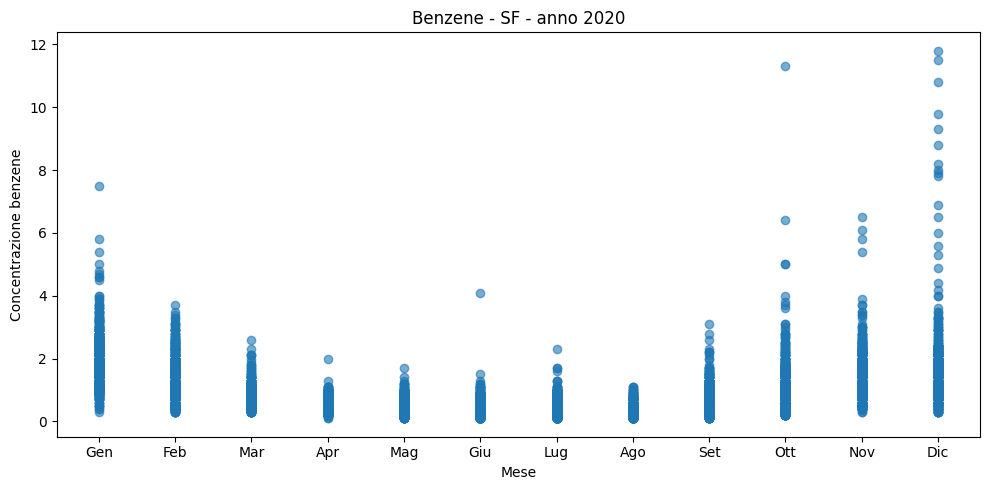

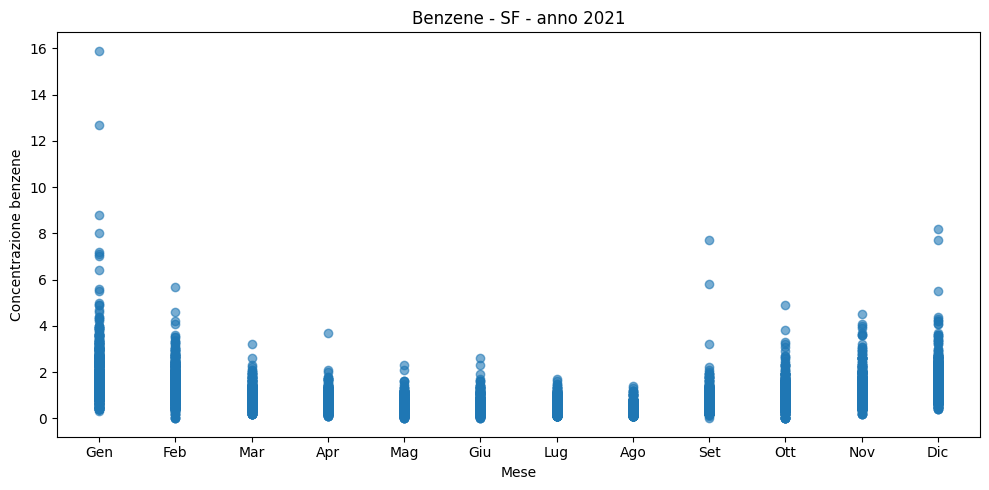

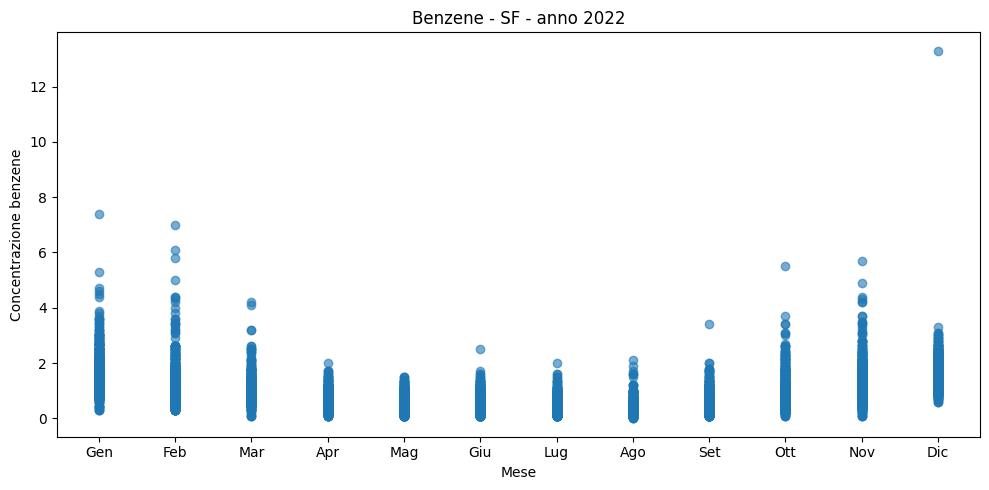

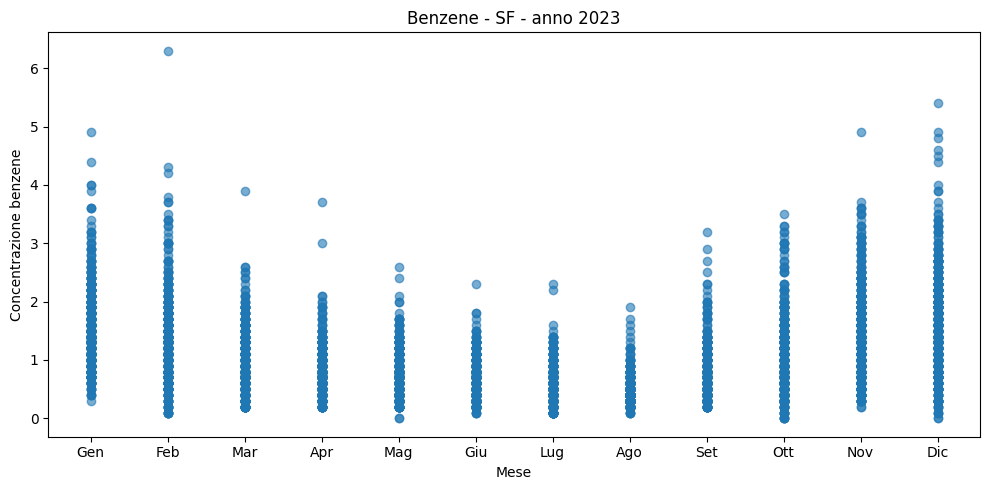

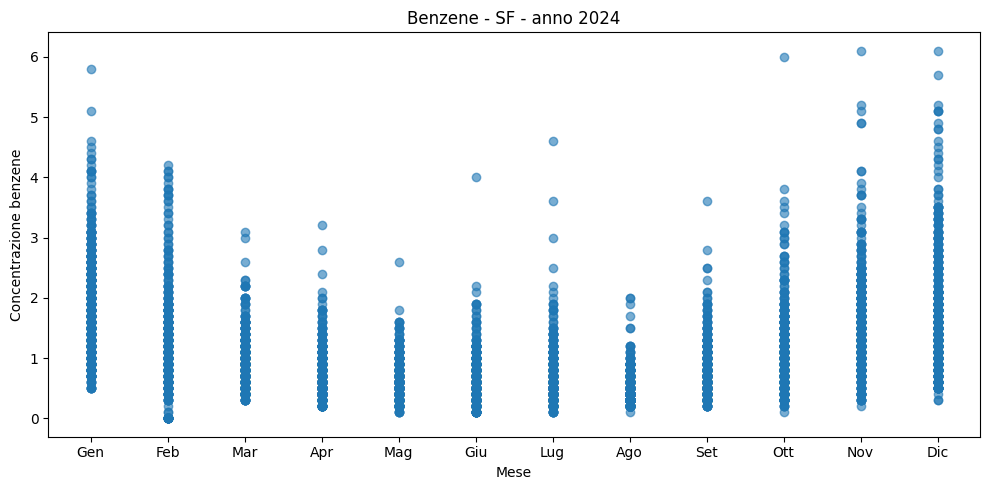

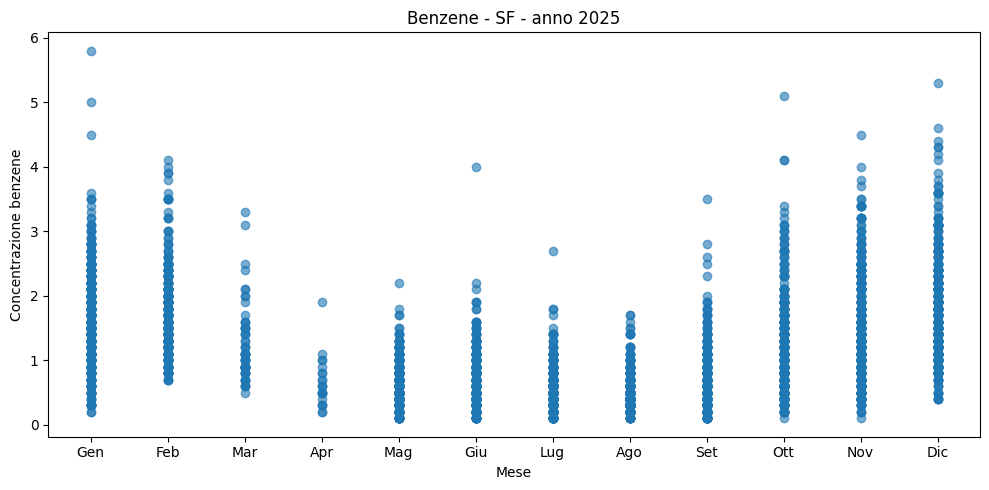

In [317]:
#plotto valori del benzene in ogni anno per vedere quale è più simile a ciò che 
# accade negli anni di cui devo riempire i missing
df_SF2["data_inizio"] = pd.to_datetime(df_SF2["data_inizio"], errors="coerce")
df_SF2["valore"] = pd.to_numeric(df_SF2["valore"], errors="coerce")
df_SF2['giorno'] = df_SF2['data_inizio'].dt.date

df_SF2["anno"] = df_SF2["data_inizio"].dt.year
df_SF2["mese"] = df_SF2["data_inizio"].dt.month

lista_anni = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

for anno in lista_anni:
    dati_anno = df_SF2.loc[
        (df_SF2["anno"] == anno) &
        (df_SF2["agente"] == "C6H6 (BENZENE)") &
        (df_SF2["valore"].notna()),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione benzene")
    plt.title(f"Benzene - SF - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [318]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di
#  benzene del 2023. creo df con solo questi valori

df_SF_2023 = df_SF2.loc[df_SF2['data_inizio'].dt.year == 2023]

In [319]:
#creo df con valori che userò per riempire 
df_C6H6_daily = (
    df_SF_2023[df_SF_2023['agente'] == "C6H6 (BENZENE)"]
    .groupby('giorno')['valore']
    .agg(
        media_C6H6='mean',
        mediana_C6H6='median',
        massimo_C6H6='max'
    )
    .reset_index()
)

#arrotondo la media
df_C6H6_daily['media_C6H6'] = df_C6H6_daily['media_C6H6'].round(2)

In [320]:
#controllo che tra i giorni in cui SF ha registrato benzene nel 2023 
# ci siano quelli che mi servono per riempire i missing

df_SF_missing_C6H6 = df_filled_SF.loc[df_filled_SF['media_C6H6'].isna()]

df_SF_missing_C6H6["mese_giorno"] = (
    pd.to_datetime(df_SF_missing_C6H6["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_C6H6_daily["mese_giorno"] = (
    pd.to_datetime(df_C6H6_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [321]:
set_missing = set(df_SF_missing_C6H6["mese_giorno"])
set_daily = set(df_C6H6_daily["mese_giorno"])

intersezione = set_missing.intersection(set_daily)

len(sorted(intersezione))

#ho 51/53 giorni, decido di riempire con questi e fillare 
# i due che rimarranno interpolando.


51

In [322]:
#creo lista di giorni da riempire
lista_C6H6_to_fill=sorted(intersezione)


In [323]:
lista_C6H6_to_fill_mg = (
   pd.to_datetime(lista_C6H6_to_fill, errors="coerce")
   .strftime("%m-%d")
    .tolist()
)

C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\284329004.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(lista_C6H6_to_fill, errors="coerce")


In [324]:
#trasformo i valori della colonna giorno dei due df e gli 
# elementi della lista nello stesso formato (datetime)

df_filled_SF["mese_giorno"] = (
    pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)
df_C6H6_daily["mese_giorno"] = pd.to_datetime(df_C6H6_daily["mese_giorno"])

#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_SF = df_filled_SF[df_filled_SF["mese_giorno"] != "02-29"].copy()
df_C6H6_daily = df_C6H6_daily[df_C6H6_daily["mese_giorno"] != "02-29"].copy()

lista_C6H6_to_fill = pd.to_datetime(lista_C6H6_to_fill)

df_filled_SF["mese_giorno"] = pd.to_datetime(df_filled_SF["mese_giorno"])
df_C6H6_daily["mese_giorno"] = pd.to_datetime(df_C6H6_daily["mese_giorno"])

C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\402522900.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_C6H6_daily["mese_giorno"] = pd.to_datetime(df_C6H6_daily["mese_giorno"])
C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\402522900.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lista_C6H6_to_fill = pd.to_datetime(lista_C6H6_to_fill)
C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\402522900.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filled_SF["mese_giorno"] = pd.to_datetime(df_filled_SF["mese_giorno"])


In [325]:
# Forzo mese_giorno in entrambi i dataframe come stringa MM-DD
df_filled_SF["mese_giorno"] = (
    pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_C6H6_daily["mese_giorno"] = (
    pd.to_datetime(df_C6H6_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

lista_C6H6_to_fill_mg = (
    pd.to_datetime(lista_C6H6_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe robuste
mappa_media = df_C6H6_daily.groupby("mese_giorno")["media_C6H6"].median()
mappa_mediana = df_C6H6_daily.groupby("mese_giorno")["mediana_C6H6"].median()
mappa_max = df_C6H6_daily.groupby("mese_giorno")["massimo_C6H6"].median()

# Maschere
mask_base = df_filled_SF["mese_giorno"].isin(lista_C6H6_to_fill_mg)

mask_media = mask_base & df_filled_SF["media_C6H6"].isna()
mask_mediana = mask_base & df_filled_SF["mediana_C6H6"].isna()
mask_max = mask_base & df_filled_SF["massimo_C6H6"].isna()

print("mask_media:", mask_media.sum())
print("valori media trovati:", df_filled_SF.loc[mask_media, "mese_giorno"].map(mappa_media).notna().sum())

# Riempio
df_filled_SF.loc[mask_media, "media_C6H6"] = (
    df_filled_SF.loc[mask_media, "mese_giorno"].map(mappa_media)
)

df_filled_SF.loc[mask_mediana, "mediana_C6H6"] = (
    df_filled_SF.loc[mask_mediana, "mese_giorno"].map(mappa_mediana)
)

df_filled_SF.loc[mask_max, "massimo_C6H6"] = (
    df_filled_SF.loc[mask_max, "mese_giorno"].map(mappa_max)
)

print(lista_C6H6_to_fill_mg)

mask_media: 51
valori media trovati: 51
['02-17', '02-18', '02-25', '02-26', '02-27', '03-05', '03-06', '03-07', '03-08', '03-09', '03-10', '03-11', '03-12', '03-13', '03-14', '03-15', '03-16', '03-20', '03-21', '03-22', '03-23', '03-24', '03-25', '03-26', '03-27', '03-28', '03-29', '03-30', '03-31', '04-01', '04-02', '04-03', '04-04', '04-05', '04-06', '04-07', '04-08', '04-09', '04-10', '04-11', '04-12', '04-13', '04-14', '04-15', '04-16', '04-17', '04-18', '04-19', '04-29', '10-20', '11-10']


In [326]:
#controllo di avere ancora due valori missing 

df_filled_SF.loc[df_filled_SF.media_C6H6.isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno
433,2025-03-17,20.0,11.0,0.28,0.3,0.4,34.00,34.0,34.0,21.75,24.5,44.0,5.00,4.0,8.0,NaN,NaN,NaN,False,False,False,False,False,True,03-17
434,2025-03-19,24.0,11.0,0.48,0.4,1.0,88.44,84.0,131.0,39.13,37.0,79.0,12.36,13.0,34.0,NaN,NaN,NaN,False,False,False,False,False,True,03-19


In [327]:
# creo flag delle righe che ho riempito con valori dal 2023
lista_C6H6_2023 = ['2024-02-17',
'2024-02-18',
'2024-10-20',
'2025-02-25',
'2025-02-26',
'2025-02-27',
'2025-03-05',
'2025-03-06',
'2025-03-07',
'2025-03-08',
'2025-03-09',
'2025-03-10',
'2025-03-11',
'2025-03-12',
'2025-03-13',
'2025-03-14',
'2025-03-15',
'2025-03-16',
'2025-03-20',
'2025-03-21',
'2025-03-22',
'2025-03-23',
'2025-03-24',
'2025-03-25',
'2025-03-26',
'2025-03-27',
'2025-03-28',
'2025-03-29',
'2025-03-30',
'2025-03-31',
'2025-04-01',
'2025-04-02',
'2025-04-03',
'2025-04-04',
'2025-04-05',
'2025-04-06',
'2025-04-07',
'2025-04-08',
'2025-04-09',
'2025-04-10',
'2025-04-11',
'2025-04-12',
'2025-04-13',
'2025-04-14',
'2025-04-15',
'2025-04-16',
'2025-04-17',
'2025-04-18',
'2025-04-19',
'2025-04-29',
'2025-11-10']
lista_C6H6_2023 = pd.to_datetime(lista_C6H6_2023)
df_filled_SF['flag_C6H6_2023'] = pd.to_datetime(df_filled_SF['giorno']).isin(pd.to_datetime(lista_C6H6_2023))
df_filled_SF['flag_C6H6_2023'].value_counts()

flag_C6H6_2023
False    654
True      51
Name: count, dtype: int64

In [328]:
#flaggo i valori che sono rimasti e che interpolerò
lista_interpol_C6H6 = ["2025-03-17", "2025-03-19"]
lista_interpol_C6H6 = pd.to_datetime(lista_interpol_C6H6)

df_filled_SF['flag_C6H6_interpol'] = df_filled_SF['giorno'].isin(lista_interpol_C6H6)
df_filled_SF.flag_C6H6_interpol.value_counts()

flag_C6H6_interpol
False    703
True       2
Name: count, dtype: int64

In [329]:
#riempio i due valori rimasti interpolando
df_filled_SF['media_C6H6'] = df_filled_SF['media_C6H6'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

df_filled_SF['mediana_C6H6'] = df_filled_SF['mediana_C6H6'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

df_filled_SF['massimo_C6H6'] = df_filled_SF['massimo_C6H6'].interpolate(
    method="linear",
    limit=2,
    limit_direction="both"
)

NB: il modo in cui ho riempito i valori mancanti, usando la colonna mese_giorno per decidere dove inserire i valori, funziona perché non c'erano giorni missing in comune negli anni 2024 e 2025 (non c'erano quindi, ad esempio, due righe missing con 'giorno' = 2024-03-03 e 'giorno' = 2025-03-03). Questo ha fatto sì che la colonna 'mese_giorno' permettesse di identificare le righe missing in modo univoco.

### NOX (OSSIDI DI AZOTO)

In [330]:
#guardo i missing

df_filled_SF.loc[df_filled_SF['media_NOX'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol
429,2025-03-13,9.0,1.0,0.33,0.2,0.8,NaN,NaN,NaN,23.04,17.5,60.0,3.75,3.0,8.0,1.03,0.9,1.7,False,False,False,False,False,True,03-13,True,False
458,2025-04-12,24.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,21.46,22.0,38.0,NaN,NaN,NaN,0.97,1.0,2.1,True,True,False,False,False,True,04-12,True,False
466,2025-04-29,22.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,8.43,9.0,14.0,NaN,NaN,NaN,0.67,0.7,1.1,False,False,False,True,True,True,04-29,True,False
578,2025-08-24,14.0,8.0,0.08,0.1,0.2,NaN,NaN,NaN,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False,True,False,False,08-24,False,False
579,2025-08-25,16.0,8.0,0.10,0.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False,True,False,False,08-25,False,False
580,2025-08-26,19.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False,True,False,False,08-26,False,False


In [331]:
#li conto

df_filled_SF['media_NOX'].isna().sum(), df_filled_SF['mediana_NOX'].isna().sum(), df_filled_SF['massimo_NOX'].isna().sum()

(np.int64(6), np.int64(6), np.int64(6))

In [332]:
#stampo i giorni per creare flag

df_filled_SF.loc[df_filled_SF['media_NOX'].isna()]['giorno']

429   2025-03-13
458   2025-04-12
466   2025-04-29
578   2025-08-24
579   2025-08-25
580   2025-08-26
Name: giorno, dtype: datetime64[s]

In [333]:
lista_NOX_missing_SF = pd.to_datetime(['2025-03-13',
'2025-04-12',
'2025-04-29',
'2025-08-24',
'2025-08-25',
'2025-08-26'])

df_filled_SF['flag_NOX_missing'] = df_filled_SF['giorno'].isin(lista_NOX_missing_SF)
df_filled_SF.flag_NOX_missing.value_counts()

flag_NOX_missing
False    699
True       6
Name: count, dtype: int64

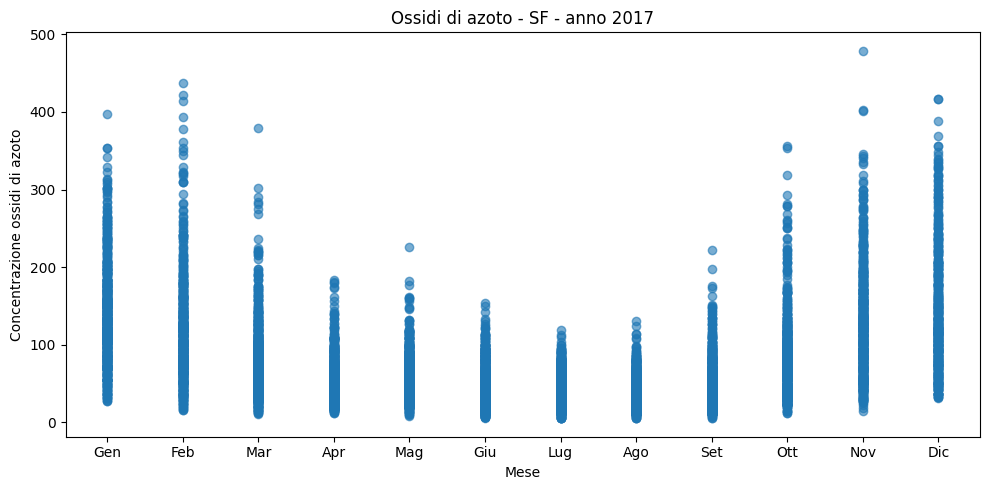

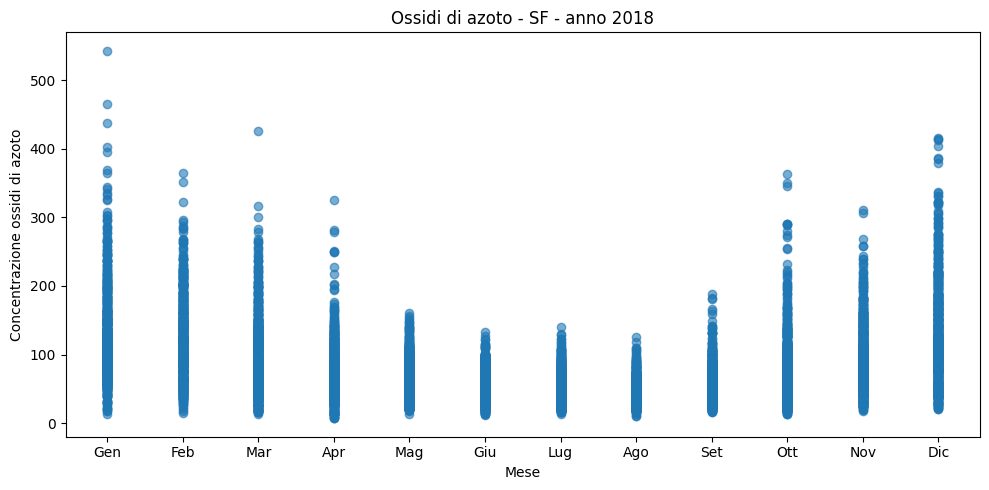

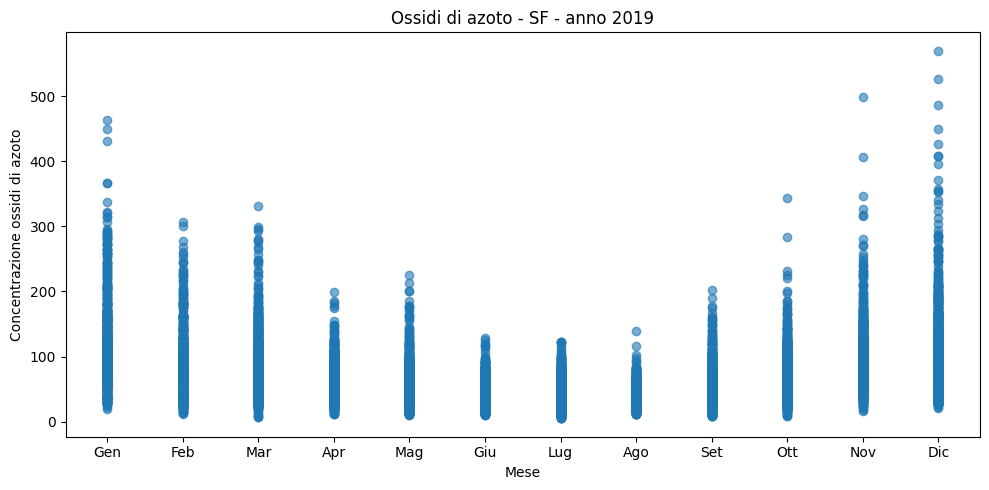

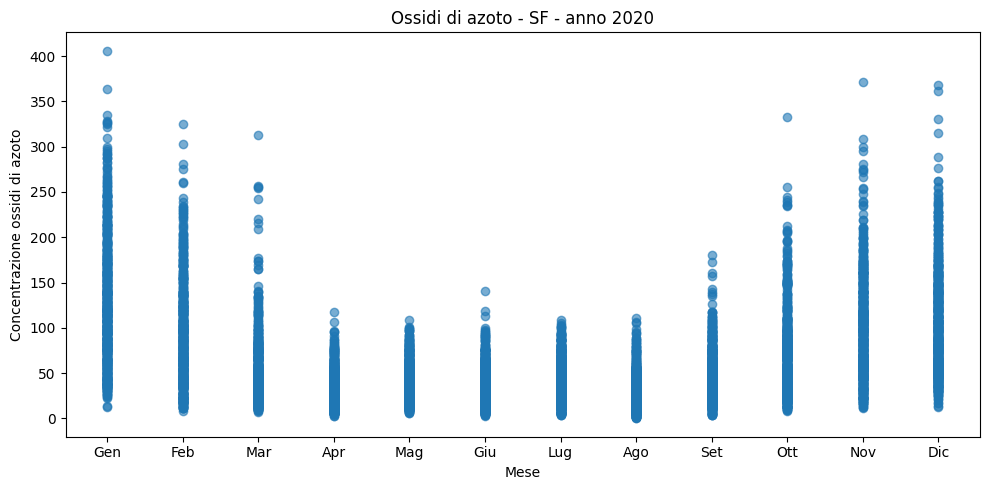

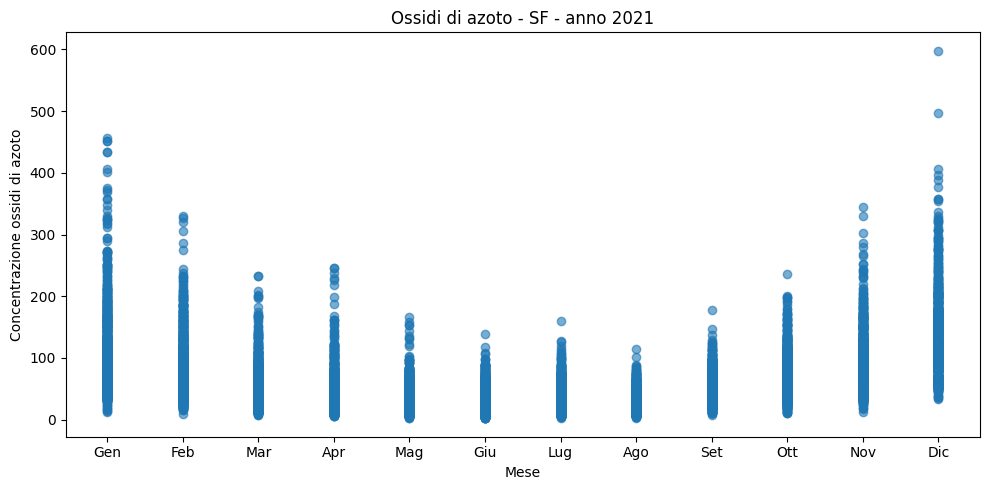

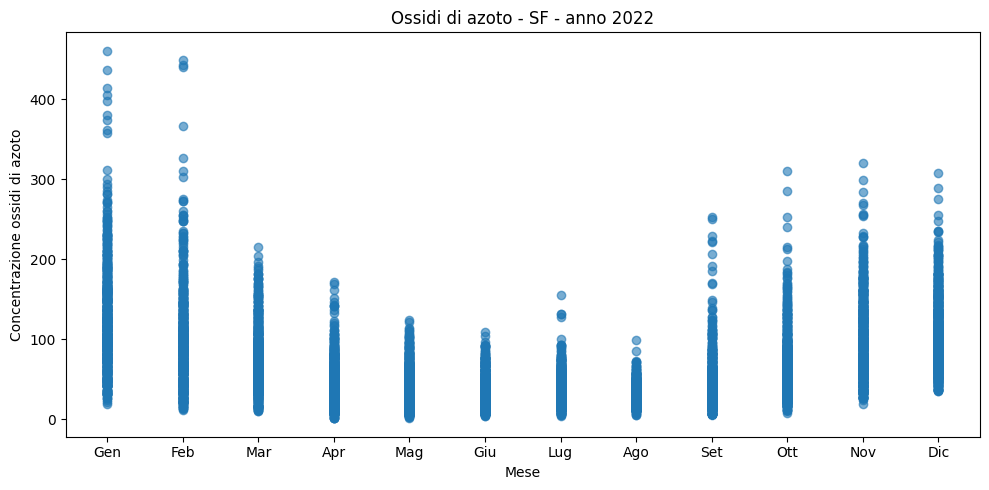

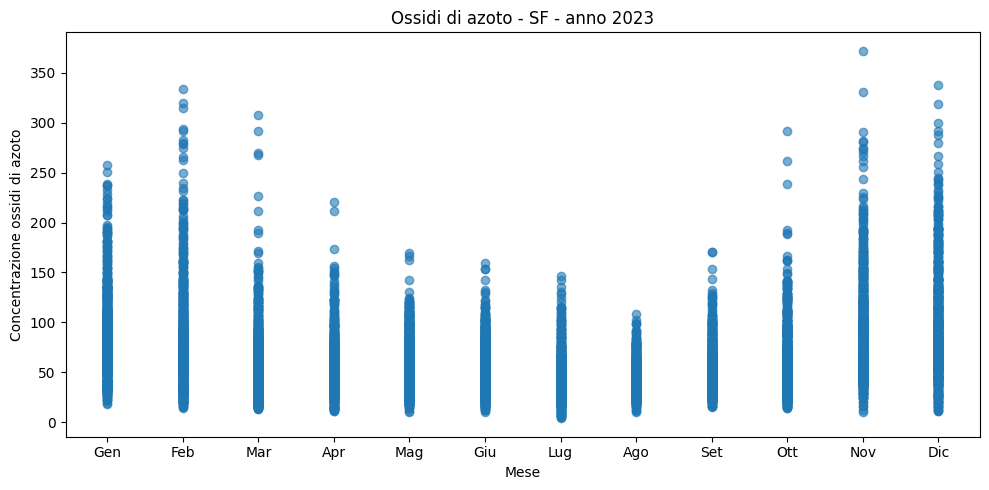

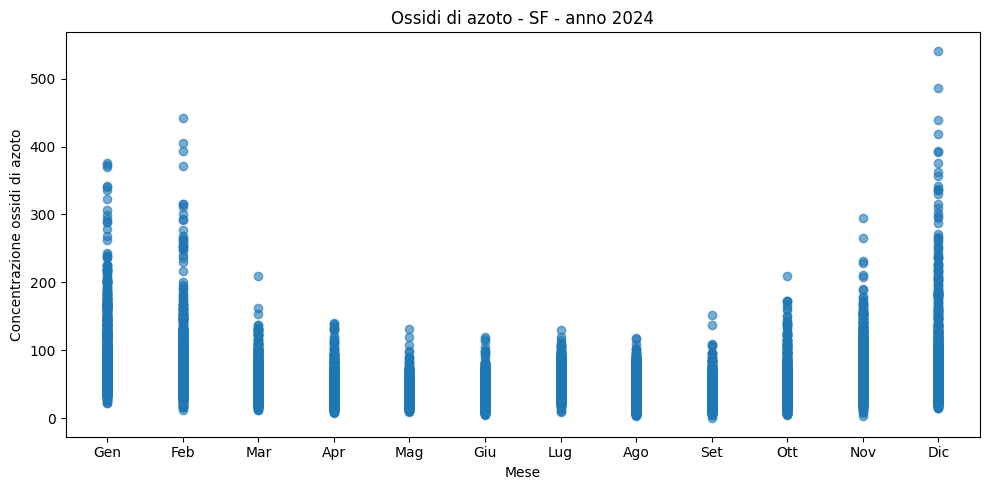

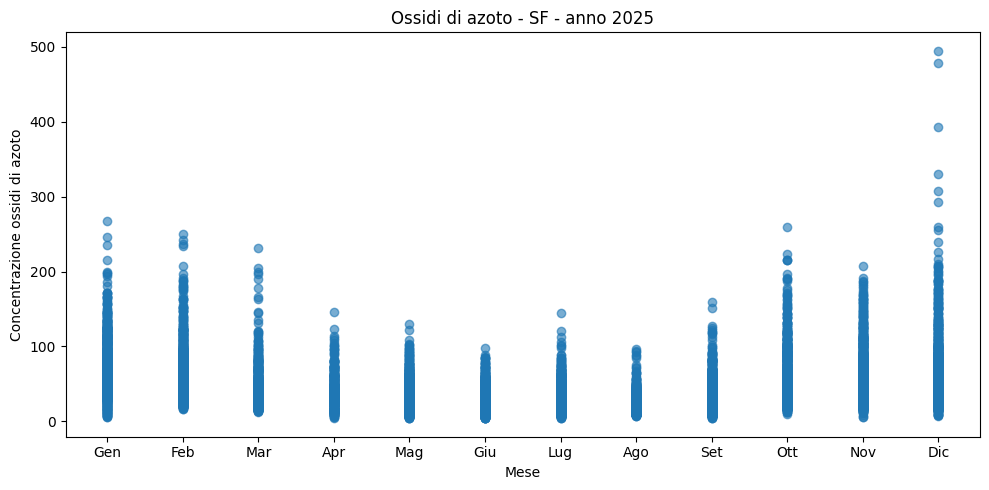

In [334]:
#osservo le registrazioni di NOX dei vari anni per vedere se ha senso usarle per riempire i missing
df_SF2["data_inizio"] = pd.to_datetime(df_SF2["data_inizio"], errors="coerce")
df_SF2["valore"] = pd.to_numeric(df_SF2["valore"], errors="coerce")

df_SF2["anno"] = df_SF2["data_inizio"].dt.year
df_SF2["mese"] = df_SF2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_SF2.loc[
        (df_SF2["anno"] == anno) &
        (df_SF2["agente"] == "NOX (OSSIDI DI AZOTO)") &
        (df_SF2["valore"].notna()),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione ossidi di azoto")
    plt.title(f"Ossidi di azoto - SF - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [335]:
#dato che non ce n'è nessuna particolarmente simile, decido di interpolare i valori sparsi che ho missing 
df_filled_SF["giorno"] = pd.to_datetime(df_filled_SF["giorno"])
df_filled_SF = df_filled_SF.sort_values("giorno").reset_index(drop=True)

# Date che vuoi interpolare
date_da_interpolare = pd.to_datetime([
    "2025-03-13",
    "2025-04-12",
    "2025-04-29",
])

mask_interp = df_filled_SF["giorno"].isin(date_da_interpolare)

colonne_nox = [
    "media_NOX",
    "mediana_NOX",
    "massimo_NOX",
]

for col in colonne_nox:
    valori_interpolati = df_filled_SF[col].interpolate(
        method="linear",
        limit=1,
        limit_direction="both"
    )
    
    df_filled_SF.loc[mask_interp, col] = valori_interpolati.loc[mask_interp]

In [336]:
#creo flag per i giorni che ho interpolato
df_filled_SF['flag_NOX_interpol'] = df_filled_SF['giorno'].isin(pd.to_datetime(['2025-03-13','2025-04-12', '2025-04-29']))
#controllo che la flag mi indichi tre valori
df_filled_SF.flag_NOX_interpol.value_counts()

flag_NOX_interpol
False    702
True       3
Name: count, dtype: int64

In [337]:
#controllo che mi siano rimasti solo i tre missing di agosto
df_filled_SF.loc[df_filled_SF['media_NOX'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol
577,2025-08-24,14.0,8.0,0.08,0.1,0.2,NaN,NaN,NaN,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False,True,False,False,08-24,False,False,True,False
578,2025-08-25,16.0,8.0,0.10,0.1,0.1,NaN,NaN,NaN,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False,True,False,False,08-25,False,False,True,False
579,2025-08-26,19.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False,True,False,False,08-26,False,False,True,False


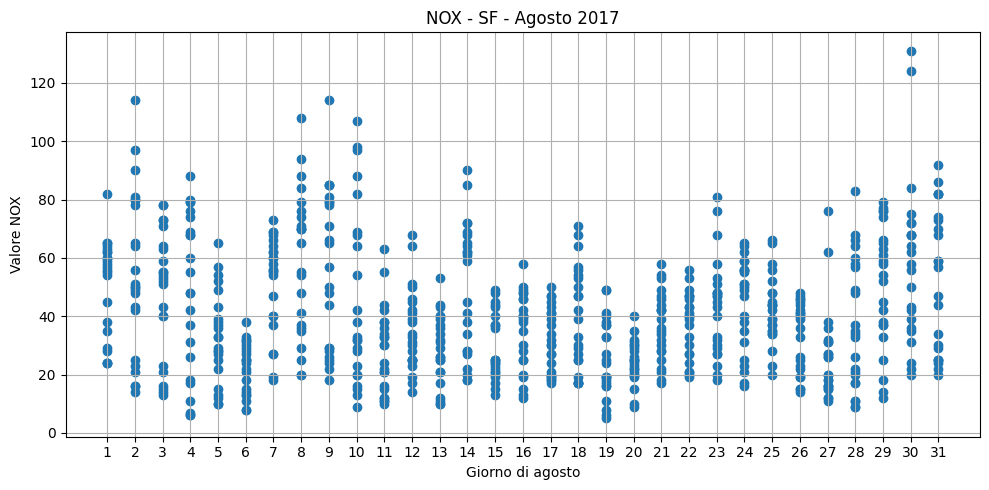

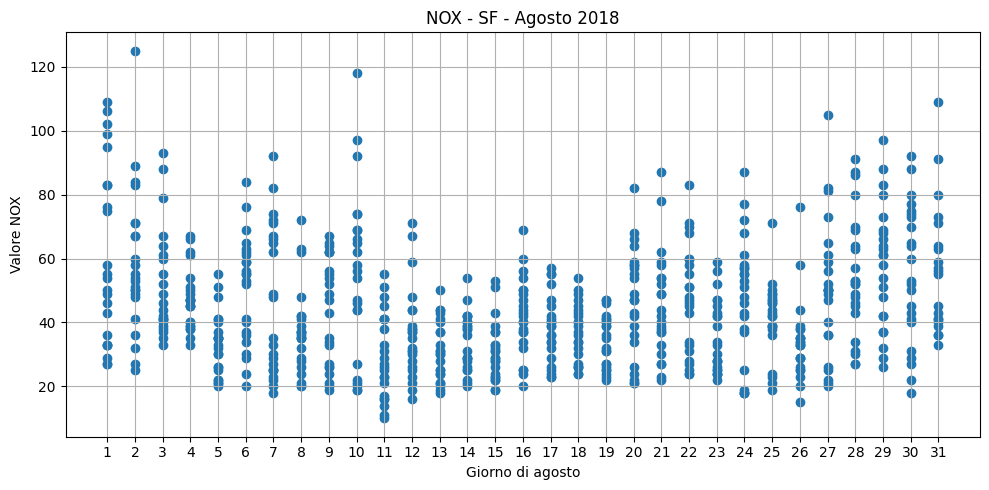

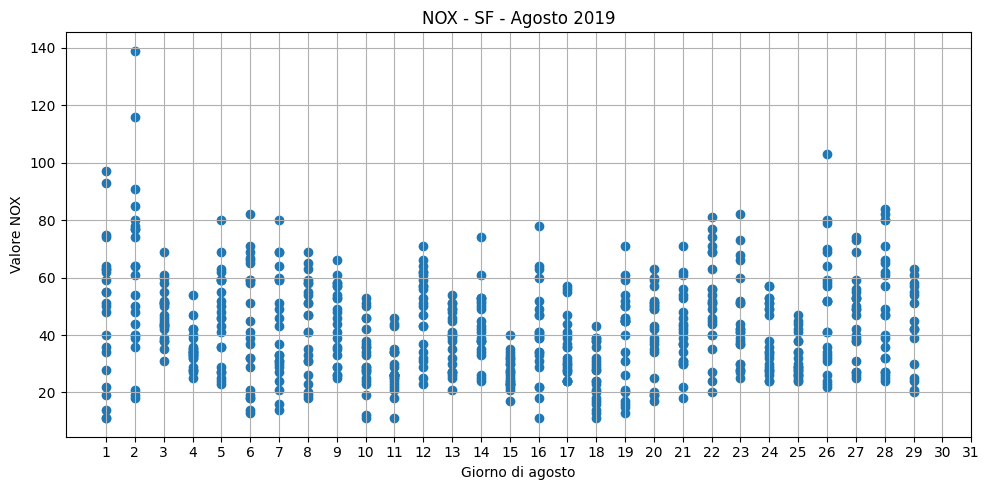

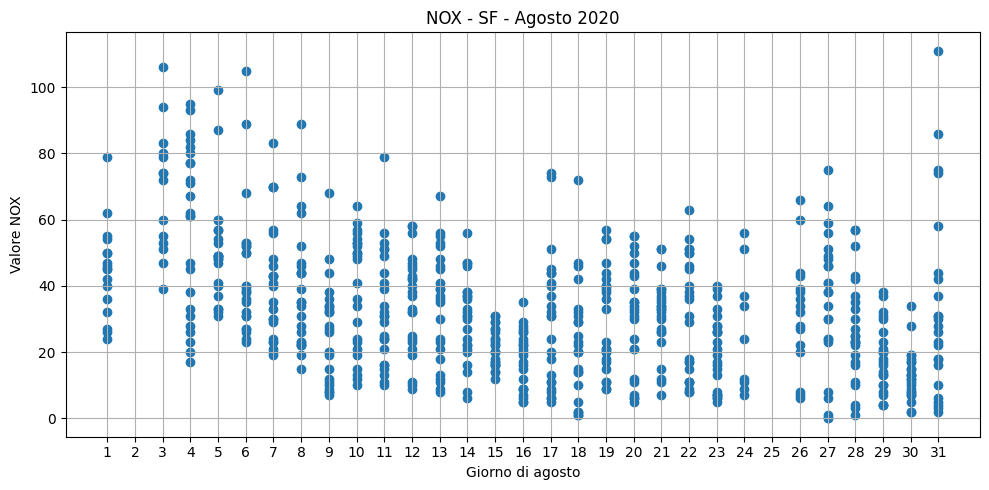

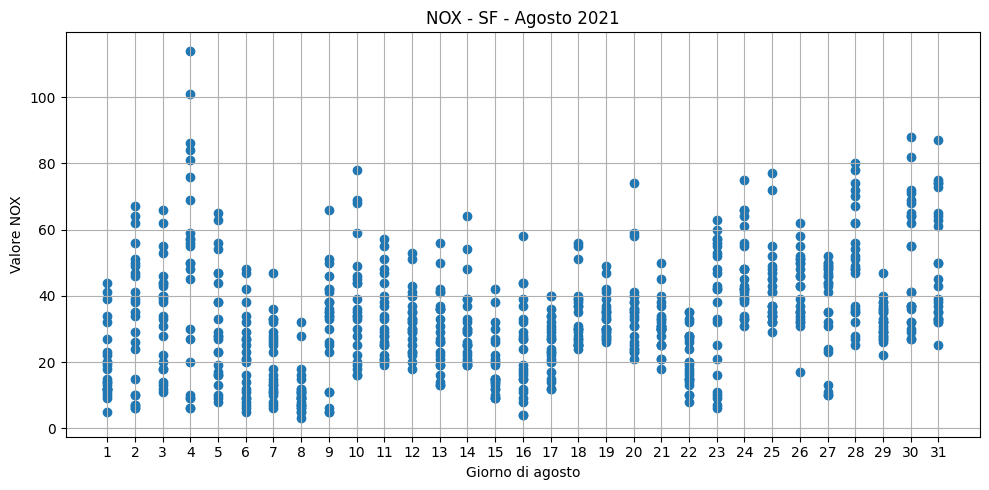

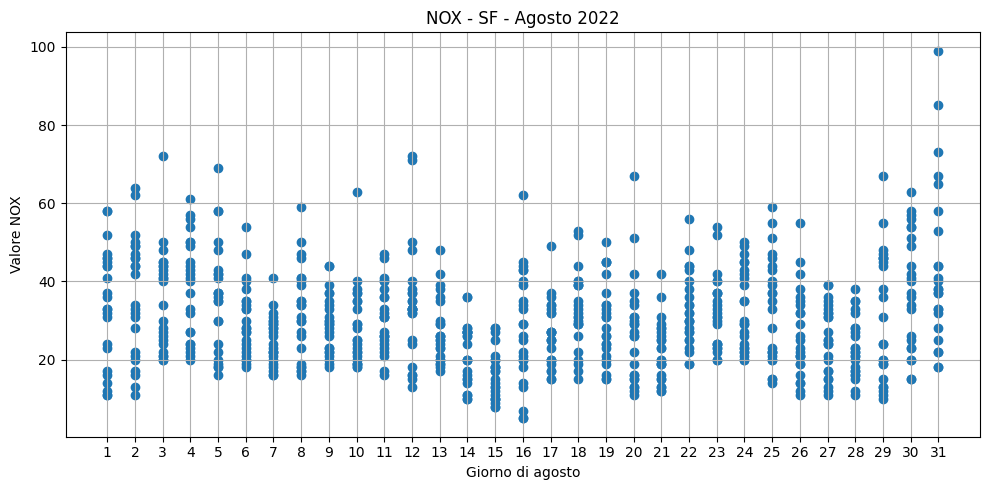

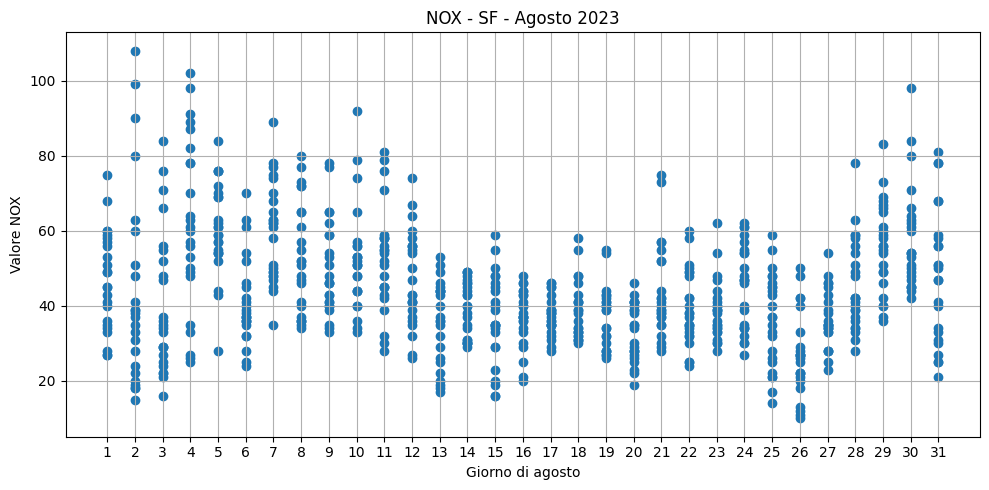

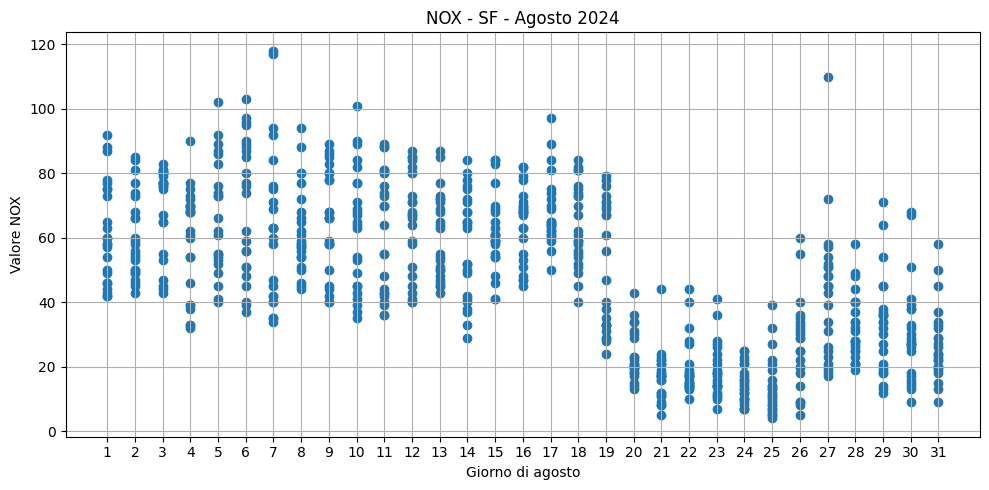

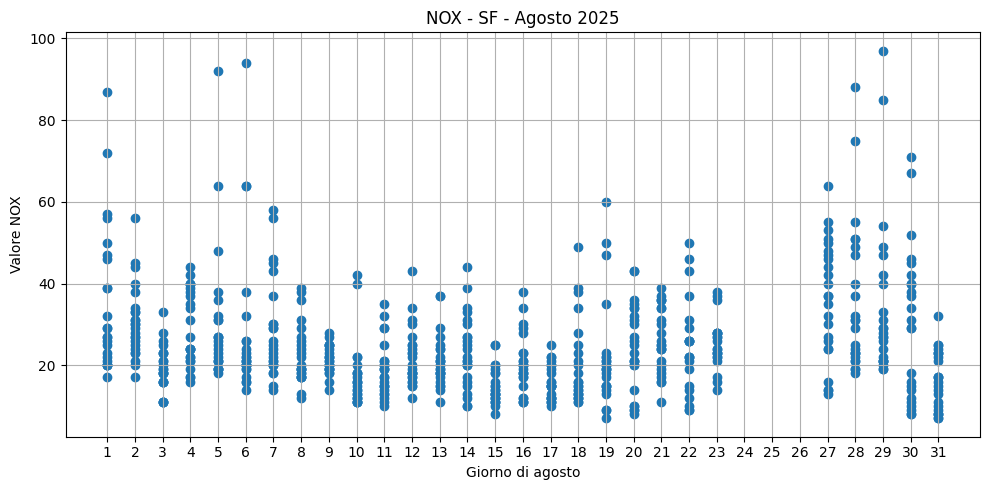

In [338]:
#per capire come riempire i tre giorni di agosto rimasti missing, guardo le registrazioni di NOX nel mese di agosto negli anni precedenti 

df = df_SF2.copy()

df["data_inizio"] = pd.to_datetime(df["data_inizio"], errors="coerce")
df["valore"] = pd.to_numeric(df["valore"], errors="coerce")

df["anno"] = df["data_inizio"].dt.year
df["mese"] = df["data_inizio"].dt.month
df["giorno_mese"] = df["data_inizio"].dt.day

df_nox_agosto = df.loc[
    (df["agente"] =="NOX (OSSIDI DI AZOTO)")
    & (df["mese"] == 8)
    & df["valore"].notna()
].copy()

#print("Righe NOX ad agosto:", len(df_nox_agosto))
#print(df_nox_agosto["anno"].value_counts().sort_index())

anni = sorted(df_nox_agosto["anno"].dropna().unique())

for anno in anni:
    dati_anno = df_nox_agosto.loc[
        df_nox_agosto["anno"] == anno
    ].sort_values("data_inizio")

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["giorno_mese"],
        dati_anno["valore"]
    )

    plt.xlabel("Giorno di agosto")
    plt.ylabel("Valore NOX")
    plt.title(f"NOX - SF - Agosto {int(anno)}")

    plt.xticks(range(1, 32))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [339]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di NOX del 2019. creo df con solo questi valori
df_SF_2019 = df_SF2.loc[df_SF2['data_inizio'].dt.year == 2019]
df_NOX_daily = (
    df_SF_2019[df_SF_2019['agente'] == "NOX (OSSIDI DI AZOTO)"]
    .groupby('giorno')['valore']
    .agg(
        media_NOX='mean',
        mediana_NOX='median',
        massimo_NOX='max'
    )
    .reset_index()
)
df_NOX_daily['media_NOX'] = df_NOX_daily['media_NOX'].round(2)
df_NOX_daily.head()


,giorno,media_NOX,mediana_NOX,massimo_NOX
0,2019-01-01,110.00,85.0,208.0
1,2019-01-02,114.30,116.0,190.0
2,2019-01-03,99.78,85.0,204.0
3,2019-01-04,100.30,87.0,280.0
4,2019-01-05,131.00,115.0,287.0


In [340]:
#trasformo i valori della colonna giorno dei due df e gli elementi della lista nello stesso formato (datetime)

df_filled_SF["mese_giorno"] = (
    pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)
df_NOX_daily["mese_giorno"] = (
    pd.to_datetime(df_NOX_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)
df_NOX_daily["mese_giorno"] = pd.to_datetime(df_NOX_daily["mese_giorno"])

lista_NOX_to_fill = pd.to_datetime(['2025-08-24', '2025-08-25', '2025-08-26'])


C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\799199056.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_NOX_daily["mese_giorno"] = pd.to_datetime(df_NOX_daily["mese_giorno"])


In [341]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_SF = df_filled_SF[df_filled_SF["mese_giorno"] != "02-29"].copy()
df_NOX_daily = df_NOX_daily[df_NOX_daily["mese_giorno"] != "02-29"].copy()

In [342]:
#creo mese_giorno a cui attaccarmi da giorno nei dataframe filled
df_filled_SF["mese_giorno"] = (
    pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

#creo mese_giorno corretto da giorno oppure data_inizio nel daily
# Se df_NOX_daily ha una colonna giorno:
df_NOX_daily["mese_giorno"] = (
    pd.to_datetime(df_NOX_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

#trasformo anche la lista, che deve diventare MM-DD
lista_NOX_to_fill_mg = (
    pd.to_datetime(lista_NOX_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

print(lista_NOX_to_fill_mg)



['08-24', '08-25', '08-26']


In [343]:
#creo mappe: mese_giorno -> valori storici/daily NOX
mappa_media = df_NOX_daily.set_index("mese_giorno")["media_NOX"]
mappa_max = df_NOX_daily.set_index("mese_giorno")["massimo_NOX"]
mappa_mediana = df_NOX_daily.set_index("mese_giorno")["mediana_NOX"]

#creo maschera che mi dice che giorni devo riempire
mask_NOX = df_filled_SF["mese_giorno"].isin(lista_NOX_to_fill_mg)

# controllo di riempire solo dove il valore è missing
mask_media = mask_NOX & df_filled_SF["media_NOX"].isna()
mask_mediana = mask_NOX & df_filled_SF["mediana_NOX"].isna()
mask_max = mask_NOX & df_filled_SF["massimo_NOX"].isna()

#riempio
df_filled_SF.loc[mask_media, "media_NOX"] = (
    df_filled_SF.loc[mask_media, "mese_giorno"].map(mappa_media)
)

df_filled_SF.loc[mask_mediana, "mediana_NOX"] = (
    df_filled_SF.loc[mask_mediana, "mese_giorno"].map(mappa_mediana)
)

df_filled_SF.loc[mask_max, "massimo_NOX"] = (
    df_filled_SF.loc[mask_max, "mese_giorno"].map(mappa_max)
)

In [344]:
#controllo se sono rimasti ancora dei missing
df_filled_SF.loc[df_filled_SF['media_NOX'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol


In [345]:
#creo flag che mi dice con che valore di NOX ho riempito
df_filled_SF['flag_NOX_2019'] = df_filled_SF['giorno'].isin(pd.to_datetime(['2025-08-24', '2025-08-25', '2025-08-26']))

In [346]:
#controllo che la flag mi segni effettivamente tre valori
df_filled_SF.flag_NOX_2019.value_counts()

flag_NOX_2019
False    702
True       3
Name: count, dtype: int64

### CO (MONOSSIDO DI CARBONIO)

In [347]:
df_filled_SF.loc[df_filled_SF['media_CO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019
447,2025-04-02,24.0,13.0,NaN,NaN,NaN,48.050,42.50,81.0,35.17,33.0,51.0,8.83,7.0,23.0,0.62,0.70,1.1,False,False,False,False,False,True,04-02,True,False,False,False,False
448,2025-04-03,24.0,15.0,NaN,NaN,NaN,39.600,39.00,65.0,33.77,32.0,81.0,7.54,7.0,18.0,0.93,1.00,1.9,False,False,False,False,False,True,04-03,True,False,False,False,False
449,2025-04-04,22.0,11.0,NaN,NaN,NaN,52.000,49.00,70.0,33.67,38.0,54.0,6.83,5.5,16.0,0.76,0.70,1.3,False,False,False,False,False,True,04-04,True,False,False,False,False
450,2025-04-05,17.0,11.0,NaN,NaN,NaN,41.310,40.00,82.0,29.29,29.5,65.0,2.00,2.0,2.0,0.82,0.70,1.7,True,True,False,False,False,True,04-05,True,False,False,False,False
451,2025-04-06,24.0,9.0,NaN,NaN,NaN,21.100,21.50,46.0,16.70,16.0,38.0,NaN,NaN,NaN,0.88,0.90,1.8,True,True,False,False,False,True,04-06,True,False,False,False,False
452,2025-04-07,22.0,6.0,NaN,NaN,NaN,50.080,43.50,108.0,36.71,34.5,63.0,NaN,NaN,NaN,0.80,0.75,1.8,True,True,False,False,False,True,04-07,True,False,False,False,False
453,2025-04-08,20.0,7.0,NaN,NaN,NaN,46.450,43.50,96.0,34.08,35.0,52.0,NaN,NaN,NaN,0.76,0.70,1.1,True,True,False,False,False,True,04-08,True,False,False,False,False
454,2025-04-09,26.0,10.0,NaN,NaN,NaN,44.300,45.00,80.0,33.79,32.5,51.0,NaN,NaN,NaN,0.70,0.65,1.2,True,True,False,False,False,True,04-09,True,False,False,False,False
455,2025-04-10,36.0,16.0,NaN,NaN,NaN,53.380,43.50,95.0,39.00,32.0,74.0,NaN,NaN,NaN,0.89,0.90,1.1,True,True,False,False,False,True,04-10,True,False,False,False,False
456,2025-04-11,20.0,10.0,NaN,NaN,NaN,35.090,31.00,70.0,28.50,27.0,47.0,NaN,NaN,NaN,0.72,0.70,1.1,True,True,False,False,False,True,04-11,True,False,False,False,False


In [348]:
(df_filled_SF['media_CO'].isna()).sum()

np.int64(23)

In [349]:
(df_filled_SF['mediana_CO'].isna()).sum()

np.int64(23)

In [350]:
(df_filled_SF['massimo_CO'].isna()).sum()

np.int64(23)

In [351]:
lista_missing_CO=['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19', '2025-04-29', '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29']
lista_missing_CO= pd.to_datetime(lista_missing_CO)

df_filled_SF['flag_CO_missing'] = df_filled_SF['giorno'].isin(lista_missing_CO)
df_filled_SF.flag_CO_missing.value_counts()

flag_CO_missing
False    682
True      23
Name: count, dtype: int64

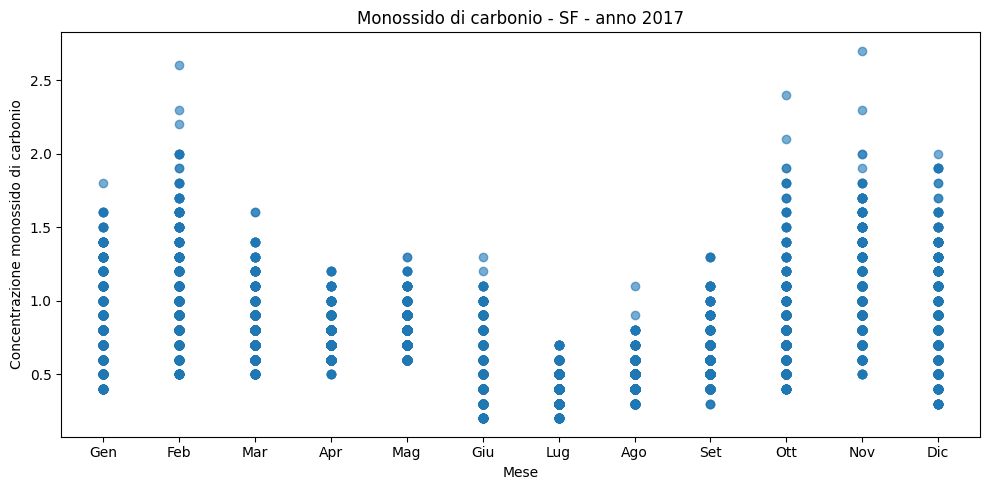

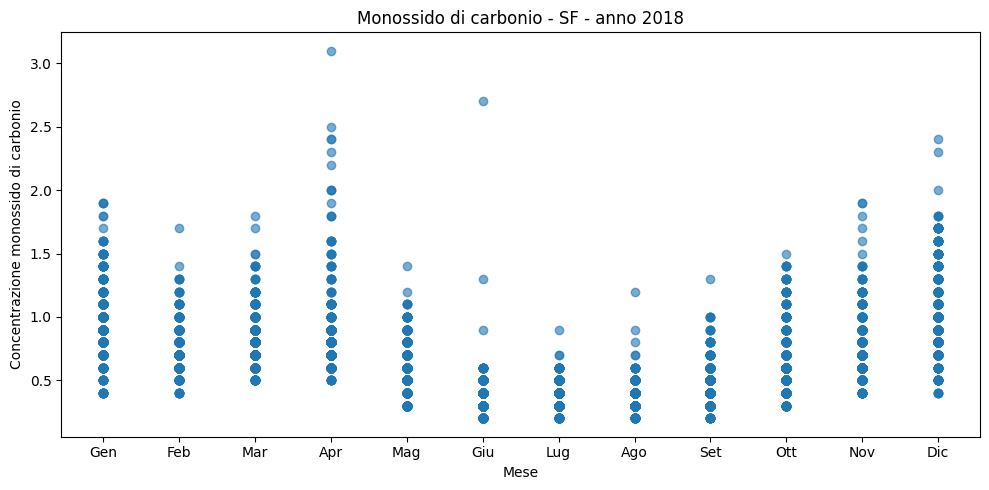

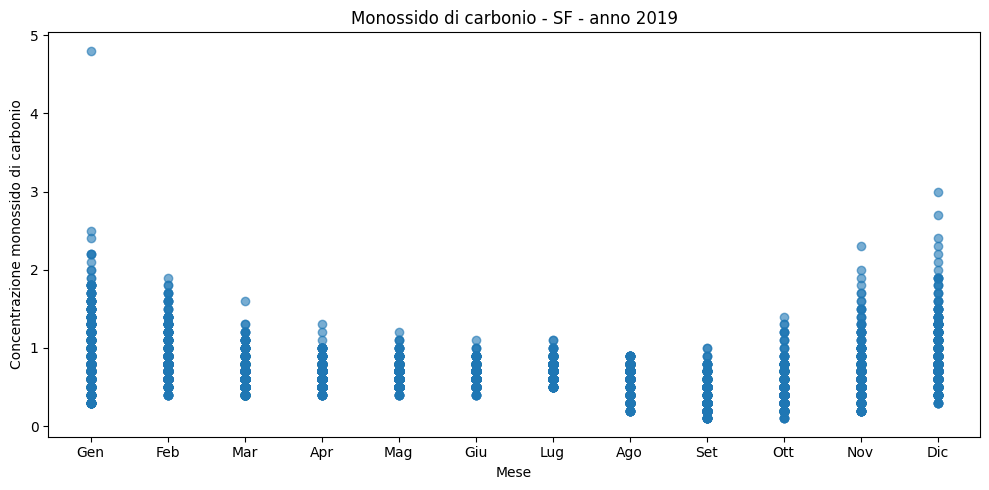

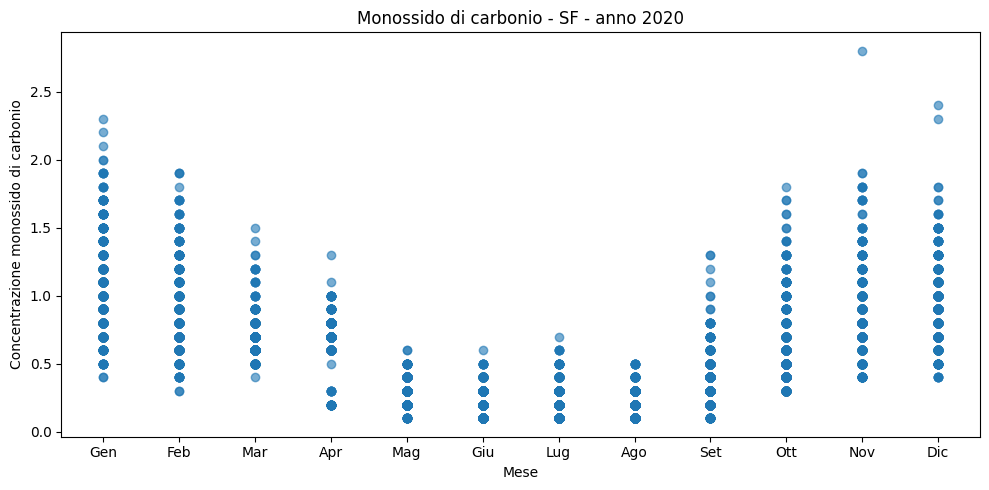

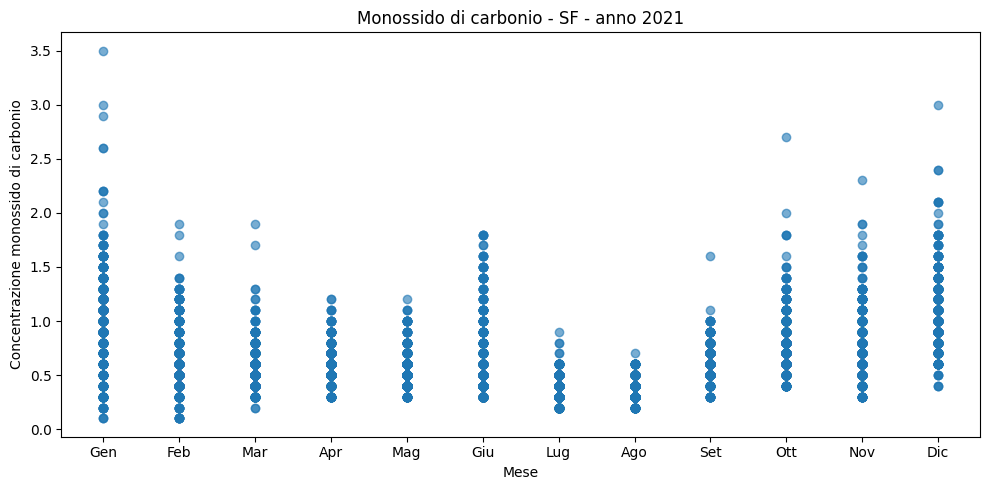

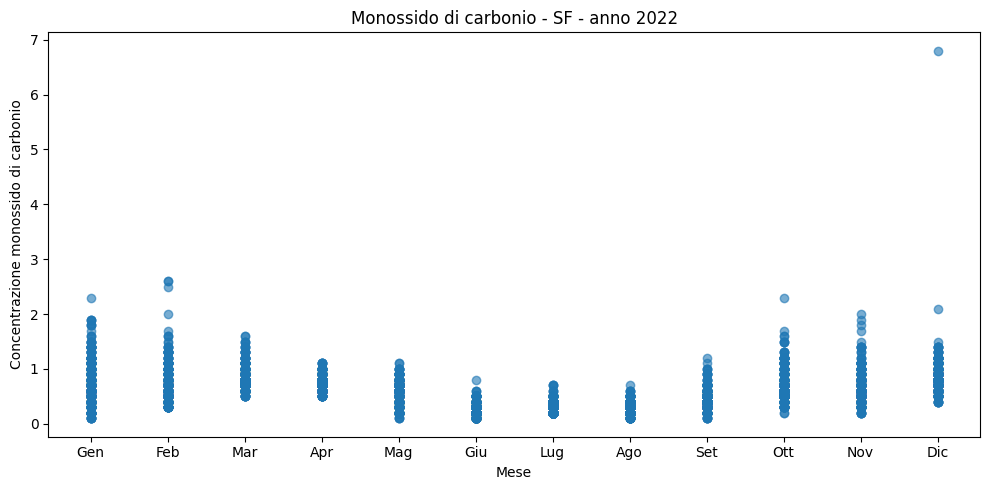

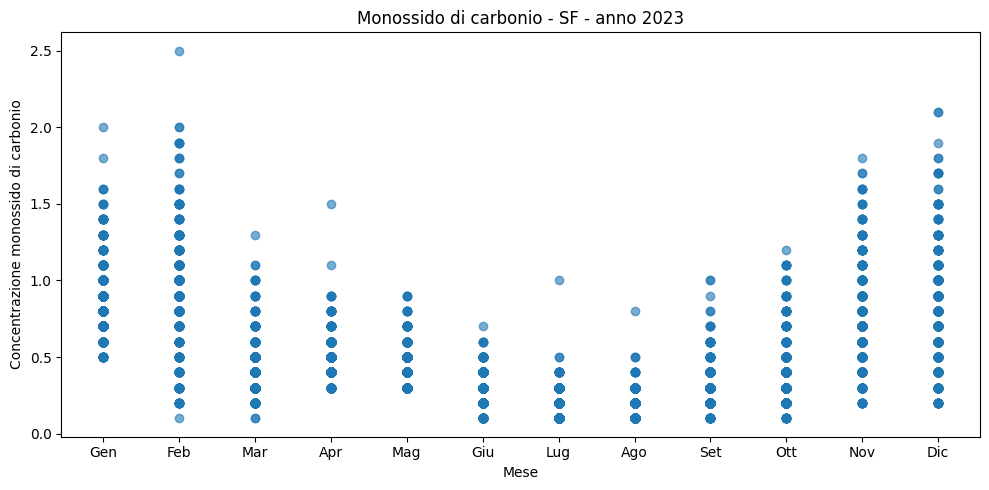

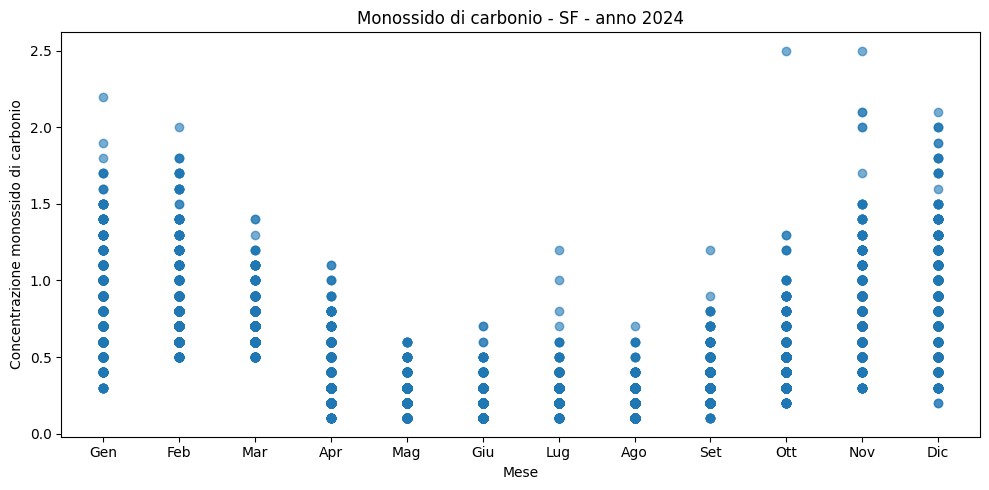

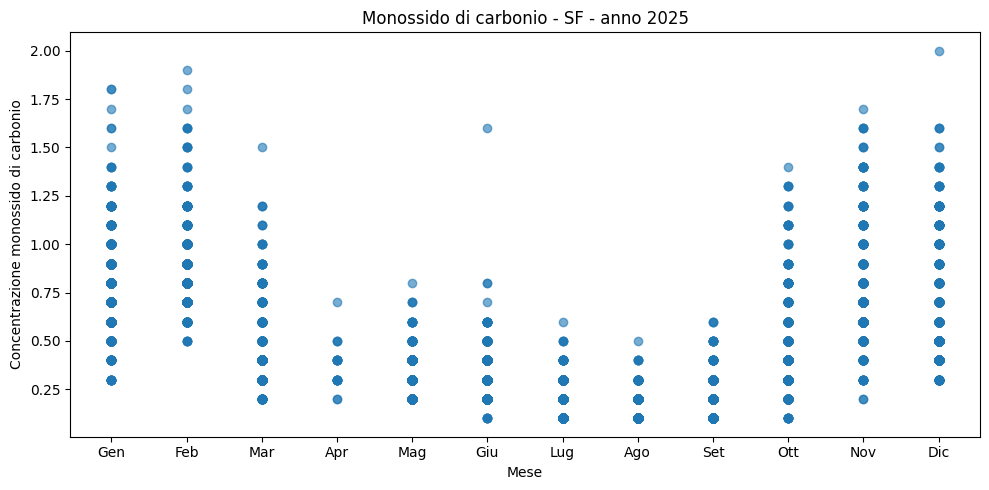

In [352]:
#osservo i valori di CO negli anni

df_SF2["data_inizio"] = pd.to_datetime(df_SF2["data_inizio"], errors="coerce")
df_SF2["valore"] = pd.to_numeric(df_SF2["valore"], errors="coerce")

df_SF2["anno"] = df_SF2["data_inizio"].dt.year
df_SF2["mese"] = df_SF2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_SF2.loc[
        (df_SF2["anno"] == anno) &
        (df_SF2["agente"] == "CO (MONOSSIDO DI CARBONIO)") &
        (df_SF2["valore"]),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione monossido di carbonio")
    plt.title(f"Monossido di carbonio - SF - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [353]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di monossido
# di carbonio del 2023. creo df con solo questi valori

df_CO_daily = (
    df_SF_2023[df_SF_2023['agente'] ==  "CO (MONOSSIDO DI CARBONIO)"]
    .groupby('giorno')['valore']
    .agg(
        media_CO='mean',
        mediana_CO='median',
        massimo_CO='max'
    )
    .reset_index()
)

df_CO_daily['media_CO'] = df_CO_daily['media_CO'].round(2)

In [354]:
df_SF_missing_CO =df_merge_SF.loc[df_merge_SF['media_CO'].isna()]

df_SF_missing_CO["mese_giorno"] = (
    pd.to_datetime(df_SF_missing_CO["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_CO_daily["mese_giorno"] = (
    pd.to_datetime(df_CO_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [355]:
lista_CO_to_fill=list(df_SF_missing_CO['mese_giorno'])

In [356]:
set_missing = set(df_SF_missing_CO["mese_giorno"])
set_daily = set(df_CO_daily["mese_giorno"])

intersezione = set_missing.intersection(set_daily)

len(sorted(intersezione))

23

In [357]:
#trasformo i valori della colonna giorno dei due df e gli elementi della lista nello stesso formato (datetime)

df_filled_SF["mese_giorno"] = (
    pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)
df_CO_daily["mese_giorno"] = pd.to_datetime(df_CO_daily["mese_giorno"])

lista_CO_to_fill = pd.to_datetime(lista_CO_to_fill)


C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\3797292375.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_CO_daily["mese_giorno"] = pd.to_datetime(df_CO_daily["mese_giorno"])
C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\3797292375.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lista_CO_to_fill = pd.to_datetime(lista_CO_to_fill)


In [358]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_SF = df_filled_SF[df_filled_SF["mese_giorno"] != "02-29"].copy()
df_CO_daily = df_CO_daily[df_CO_daily["mese_giorno"] != "02-29"].copy()

In [359]:
#trasformo i valori della colonna giorno dei due df e gli elementi della lista nello stesso formato (datetime)

df_filled_SF["mese_giorno"] = pd.to_datetime(df_filled_SF["mese_giorno"])
df_CO_daily["mese_giorno"] = pd.to_datetime(df_CO_daily["mese_giorno"])



C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\4152307262.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filled_SF["mese_giorno"] = pd.to_datetime(df_filled_SF["mese_giorno"])


In [360]:
# Creo mese_giorno corretto
df_filled_SF["giorno"] = pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
df_filled_SF["mese_giorno"] = df_filled_SF["giorno"].dt.strftime("%m-%d")
df_filled_SF["anno"] = df_filled_SF["giorno"].dt.year

df_CO_daily["mese_giorno"] = (
    pd.to_datetime(df_CO_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

lista_CO_to_fill_mg = (
    pd.to_datetime(lista_CO_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe da storico/daily
mappa_media = df_CO_daily.groupby("mese_giorno")["media_CO"].median()
mappa_mediana = df_CO_daily.groupby("mese_giorno")["mediana_CO"].median()
mappa_max = df_CO_daily.groupby("mese_giorno")["massimo_CO"].median()

# Maschera: solo giorni della lista, solo anno 2025
mask_CO = (
    df_filled_SF["mese_giorno"].isin(lista_CO_to_fill_mg)
    & (df_filled_SF["anno"] == 2025)
)

print("Righe selezionate:", mask_CO.sum())

df_filled_SF.loc[mask_CO, "media_CO"] = (
    df_filled_SF.loc[mask_CO, "mese_giorno"].map(mappa_media)
)

df_filled_SF.loc[mask_CO, "mediana_CO"] = (
    df_filled_SF.loc[mask_CO, "mese_giorno"].map(mappa_mediana)
)

df_filled_SF.loc[mask_CO, "massimo_CO"] = (
    df_filled_SF.loc[mask_CO, "mese_giorno"].map(mappa_max)
)

Righe selezionate: 23


In [361]:
df_filled_SF.loc[df_filled_SF['media_CO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno


In [362]:
#lista_filled=['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-05', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19', '2025-04-29', '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29']
lista_filled = lista_missing_CO

In [363]:
#creo flag per i valori di CO che ho riempito con dati del 2023
df_filled_SF['flag_CO_2023'] = df_filled_SF['giorno'].isin(pd.to_datetime(lista_filled))
df_filled_SF.flag_CO_2023.value_counts()

flag_CO_2023
False    682
True      23
Name: count, dtype: int64

In [364]:
df_filled_SF.columns

Index(['giorno', 'PM10', 'PM2.5', 'media_CO', 'mediana_CO', 'massimo_CO',
       'media_NOX', 'mediana_NOX', 'massimo_NOX', 'media_NO2', 'mediana_NO2',
       'massimo_NO2', 'media_NO', 'mediana_NO', 'massimo_NO', 'media_C6H6',
       'mediana_C6H6', 'massimo_C6H6', 'flag_PM25_missing', 'flag_PM25_GM',
       'flag_PM25_interpol', 'flag_NO2_missing', 'flag_NO2_GM',
       'flag_C6H6_missing', 'mese_giorno', 'flag_C6H6_2023',
       'flag_C6H6_interpol', 'flag_NOX_missing', 'flag_NOX_interpol',
       'flag_NOX_2019', 'flag_CO_missing', 'anno', 'flag_CO_2023'],
      dtype='str')

### NO2 (BIOSSIDO DI AZOTO)

In [365]:
df_filled_SF.loc[df_filled_SF['media_NO2'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023
573,2025-08-20,22.0,10.0,0.16,0.2,0.2,24.25,24.0,43.0,NaN,NaN,NaN,2.71,2.0,7.0,0.37,0.4,0.6,False,False,False,True,False,False,08-20,False,False,False,False,False,False,2025,False
574,2025-08-21,15.0,7.0,0.16,0.2,0.3,26.12,25.0,39.0,NaN,NaN,NaN,3.96,4.0,8.0,0.45,0.4,0.9,False,False,False,True,False,False,08-21,False,False,False,False,False,False,2025,False
575,2025-08-22,14.0,8.0,0.15,0.1,0.3,24.52,22.0,50.0,NaN,NaN,NaN,3.24,2.0,11.0,0.45,0.4,0.7,False,False,False,True,False,False,08-22,False,False,False,False,False,False,2025,False
576,2025-08-23,14.0,9.0,0.16,0.1,0.4,25.33,24.0,38.0,NaN,NaN,NaN,3.04,3.0,7.0,0.48,0.5,0.9,False,False,False,True,False,False,08-23,False,False,False,False,False,False,2025,False
577,2025-08-24,14.0,8.0,0.08,0.1,0.2,38.70,34.0,57.0,NaN,NaN,NaN,2.08,2.0,6.0,0.37,0.4,0.6,False,False,False,True,False,False,08-24,False,False,True,False,True,False,2025,False
578,2025-08-25,16.0,8.0,0.10,0.1,0.1,32.43,29.0,47.0,NaN,NaN,NaN,5.21,3.0,19.0,0.58,0.5,0.9,False,False,False,True,False,False,08-25,False,False,True,False,True,False,2025,False
579,2025-08-26,19.0,9.0,0.18,0.2,0.3,49.48,52.0,103.0,NaN,NaN,NaN,3.29,2.0,9.0,0.53,0.5,1.2,False,False,False,True,False,False,08-26,False,False,True,False,True,True,2025,True


In [366]:
df_filled_SF['media_NO2'].isna().sum()

np.int64(7)

In [367]:
df_filled_SF['mediana_NO2'].isna().sum()

np.int64(7)

In [368]:
df_filled_SF['massimo_NO2'].isna().sum()

np.int64(7)

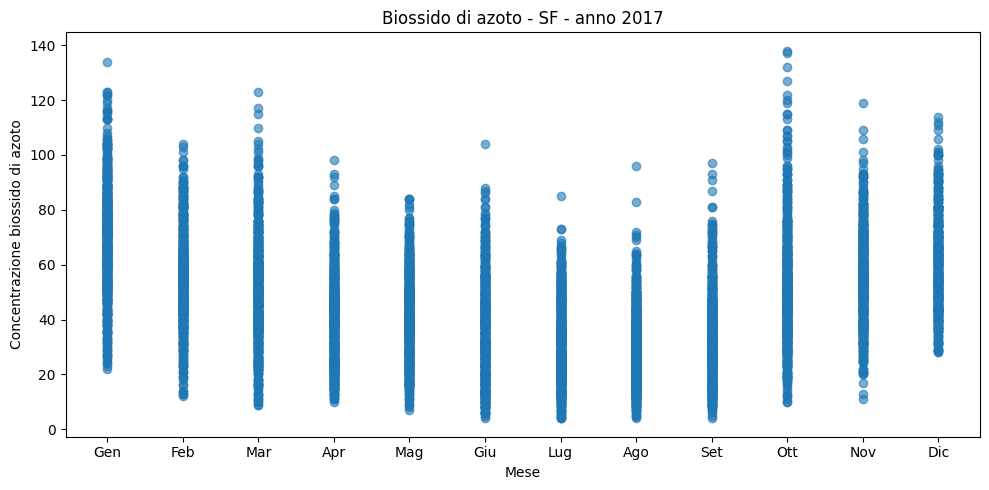

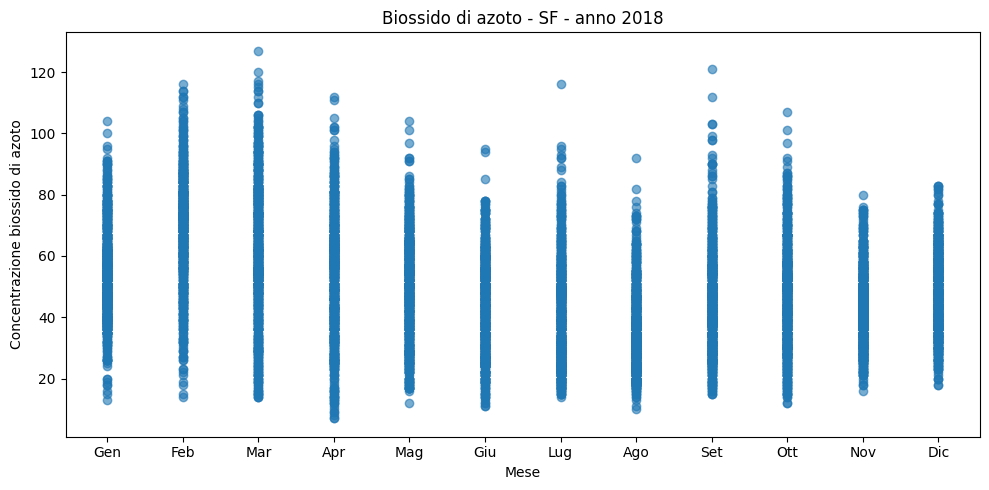

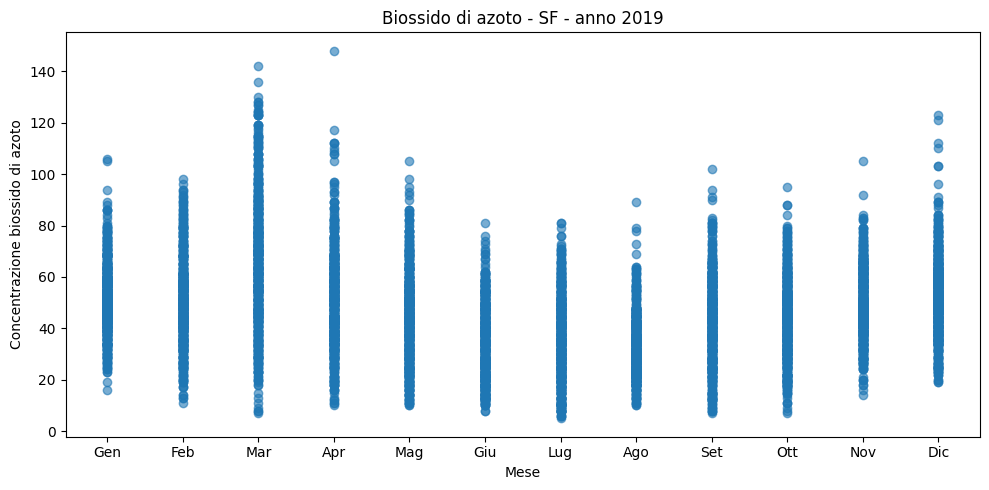

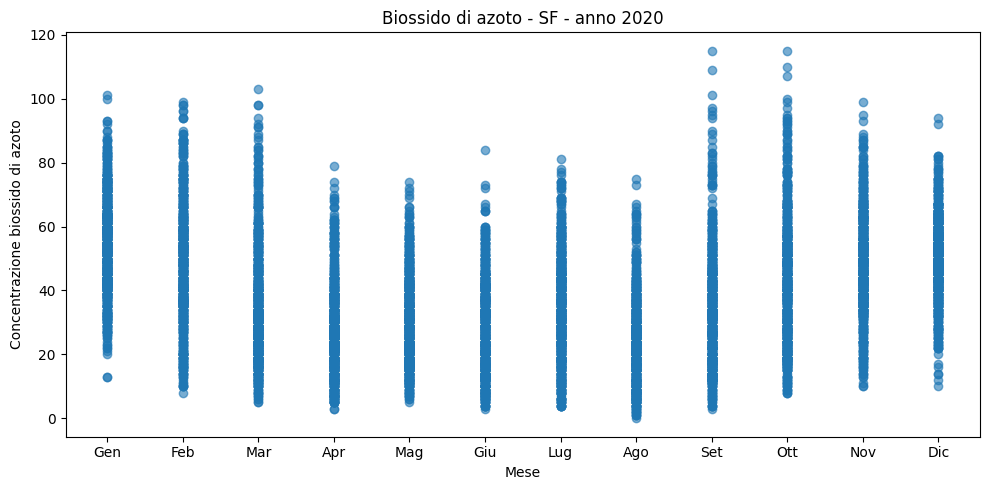

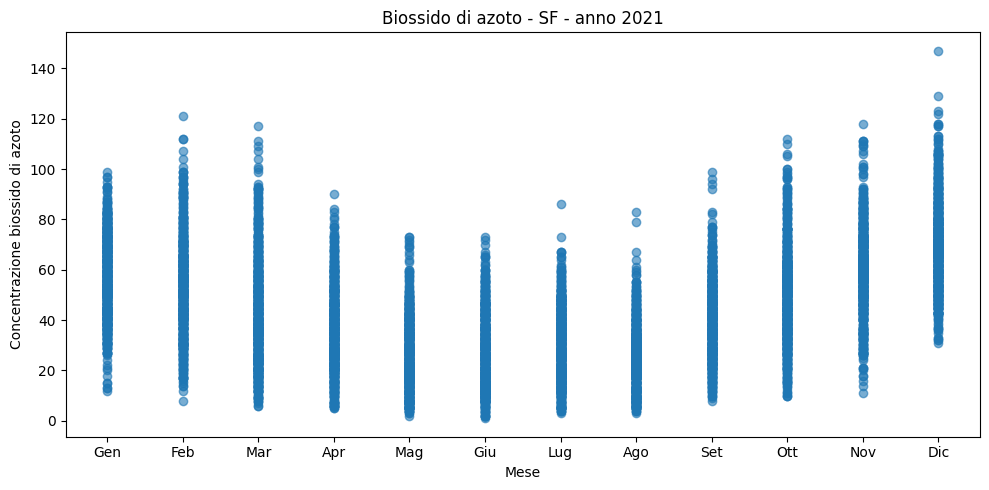

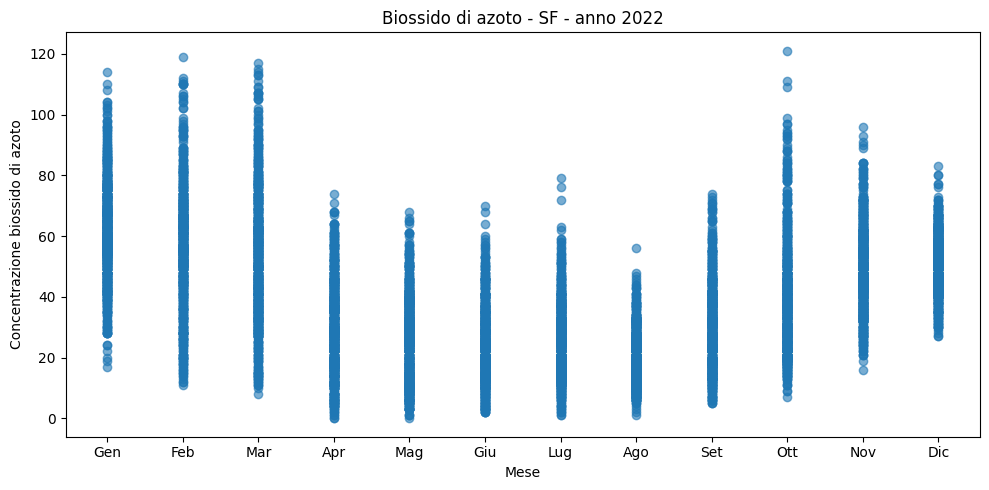

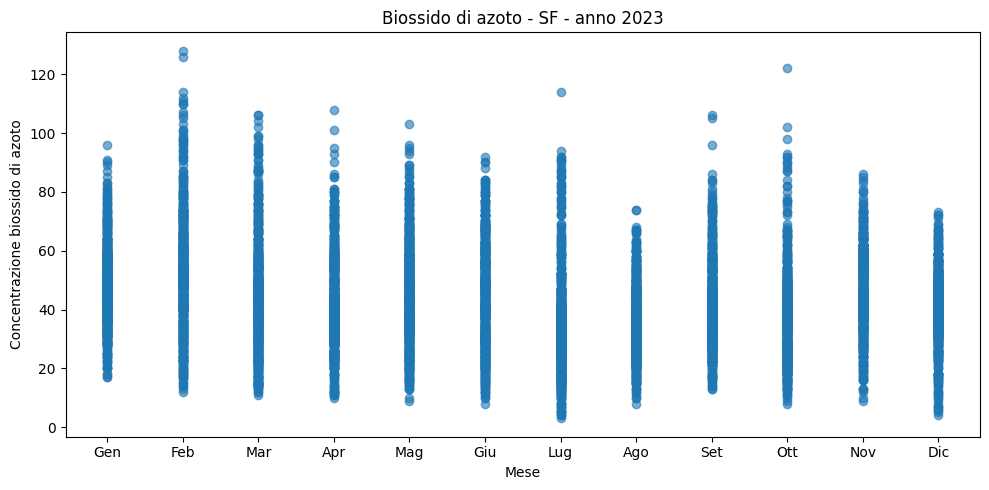

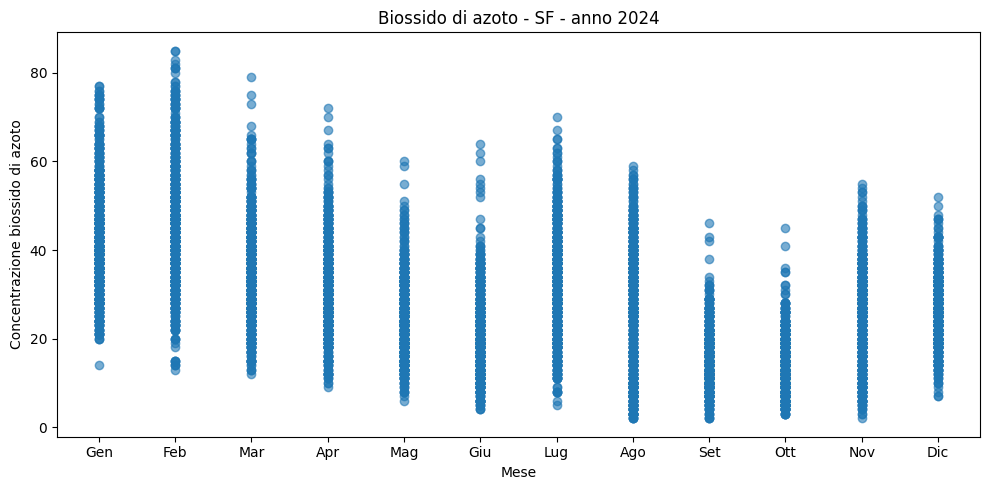

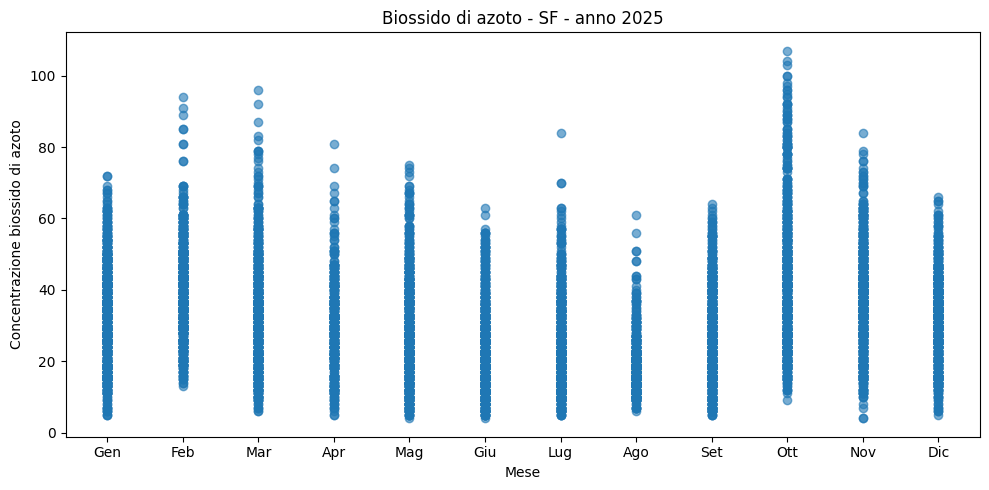

In [369]:

df_SF2["data_inizio"] = pd.to_datetime(df_SF2["data_inizio"], errors="coerce")
df_SF2["valore"] = pd.to_numeric(df_SF2["valore"], errors="coerce")

df_SF2["anno"] = df_SF2["data_inizio"].dt.year
df_SF2["mese"] = df_SF2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_SF2.loc[
        (df_SF2["anno"] == anno) &
        (df_SF2["agente"] == "NO2 (BIOSSIDO DI AZOTO)") &
        (df_SF2["valore"].notna()),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione biossido di azoto")
    plt.title(f"Biossido di azoto - SF - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [370]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i
#  valori di biossido di azoto del 2023. creo df con solo questi valori
df_NO2_daily = (
    df_SF_2023[df_SF_2023['agente'] == "NO2 (BIOSSIDO DI AZOTO)"]
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_NO2_daily['media_NO2'] = df_NO2_daily['media_NO2'].round(2)

In [371]:
df_SF_missing_NO2 =df_merge_SF.loc[df_merge_SF['media_NO2'].isna()]

df_SF_missing_NO2["mese_giorno"] = (
    pd.to_datetime(df_SF_missing_NO2["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_NO2_daily["mese_giorno"] = (
    pd.to_datetime(df_NO2_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [372]:
set_missing = set(df_SF_missing_NO2["mese_giorno"])
set_daily = set(df_NO2_daily["mese_giorno"])

intersezione = set_missing.intersection(set_daily)

len(sorted(intersezione))

13

In [373]:
lista_NO2_to_fill=['08-20', '08-21', '08-22', '08-23', '08-24', '08-25', '08-26']

In [374]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_SF = df_filled_SF[df_filled_SF["mese_giorno"] != "02-29"].copy()
df_NO2_daily = df_NO2_daily[df_NO2_daily["mese_giorno"] != "02-29"].copy()

In [375]:
# Creo mese_giorno corretto
df_filled_SF["giorno"] = pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
df_filled_SF["mese_giorno"] = df_filled_SF["giorno"].dt.strftime("%m-%d")
df_filled_SF["anno"] = df_filled_SF["giorno"].dt.year


df_NO2_daily["mese_giorno"] = (
    pd.to_datetime(df_NO2_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

lista_NO2_to_fill_mg = (
    pd.to_datetime(lista_NO2_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe da storico/daily
mappa_media = df_NO2_daily.groupby("mese_giorno")["media_NO2"].median()
mappa_mediana = df_NO2_daily.groupby("mese_giorno")["mediana_NO2"].median()
mappa_max = df_NO2_daily.groupby("mese_giorno")["massimo_NO2"].median()

# Maschera: solo giorni della lista, solo anno 2025
mask_NO2 = (
    df_filled_SF["mese_giorno"].isin(lista_NO2_to_fill_mg)
    & (df_filled_SF["anno"] == 2025)
)

print("Righe selezionate:", mask_NO2.sum())

df_filled_SF.loc[mask_NO2, "media_NO2"] = (
    df_filled_SF.loc[mask_NO2, "mese_giorno"].map(mappa_media)
)

df_filled_SF.loc[mask_NO2, "mediana_NO2"] = (
    df_filled_SF.loc[mask_NO2, "mese_giorno"].map(mappa_mediana)
)

df_filled_SF.loc[mask_NO2, "massimo_NO2"] = (
    df_filled_SF.loc[mask_NO2, "mese_giorno"].map(mappa_max)
)

Righe selezionate: 7


C:\Users\Boom\AppData\Local\Temp\ipykernel_16412\3432643732.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(lista_NO2_to_fill, errors="coerce")


In [376]:
df_filled_SF.loc[df_filled_SF['media_NO2'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023


In [377]:
lista_filled =[ '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26', '2025-08-20']
df_filled_SF['flag_NO2_2023'] = df_filled_SF['giorno'].isin(pd.to_datetime(lista_filled))
df_filled_SF.flag_NO2_2023.value_counts()

flag_NO2_2023
False    698
True       7
Name: count, dtype: int64

### NO (MONOSSIDO DI AZOTO)

In [378]:
df_filled_SF.loc[df_filled_SF['media_NO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023
394,2025-02-07,47.0,32.0,0.89,0.90,1.2,88.170,90.00,147.0,46.17,45.0,61.0,NaN,NaN,NaN,1.84,1.80,2.3,False,False,False,False,False,False,02-07,False,False,False,False,False,False,2025,False,False
395,2025-02-08,54.0,43.0,0.91,0.90,1.1,88.920,85.50,141.0,48.12,45.5,66.0,NaN,NaN,NaN,2.01,2.00,2.6,False,False,False,False,False,False,02-08,False,False,False,False,False,False,2025,False,False
396,2025-02-09,19.0,14.0,0.75,0.70,0.8,38.580,38.50,67.0,28.12,28.0,40.0,NaN,NaN,NaN,1.42,1.40,1.8,False,False,False,False,False,False,02-09,False,False,False,False,False,False,2025,False,False
397,2025-02-10,30.0,18.0,0.82,0.80,1.1,62.750,60.00,117.0,37.33,36.5,59.0,NaN,NaN,NaN,1.67,1.60,2.3,False,False,False,False,False,False,02-10,False,False,False,False,False,False,2025,False,False
451,2025-04-06,24.0,9.0,0.57,0.60,0.9,21.100,21.50,46.0,16.70,16.0,38.0,NaN,NaN,NaN,0.88,0.90,1.8,True,True,False,False,False,True,04-06,True,False,False,False,False,True,2025,True,False
452,2025-04-07,22.0,6.0,0.55,0.50,0.9,50.080,43.50,108.0,36.71,34.5,63.0,NaN,NaN,NaN,0.80,0.75,1.8,True,True,False,False,False,True,04-07,True,False,False,False,False,True,2025,True,False
453,2025-04-08,20.0,7.0,0.49,0.50,0.6,46.450,43.50,96.0,34.08,35.0,52.0,NaN,NaN,NaN,0.76,0.70,1.1,True,True,False,False,False,True,04-08,True,False,False,False,False,True,2025,True,False
454,2025-04-09,26.0,10.0,0.46,0.40,0.6,44.300,45.00,80.0,33.79,32.5,51.0,NaN,NaN,NaN,0.70,0.65,1.2,True,True,False,False,False,True,04-09,True,False,False,False,False,True,2025,True,False
455,2025-04-10,36.0,16.0,0.51,0.50,0.6,53.380,43.50,95.0,39.00,32.0,74.0,NaN,NaN,NaN,0.89,0.90,1.1,True,True,False,False,False,True,04-10,True,False,False,False,False,True,2025,True,False
456,2025-04-11,20.0,10.0,0.46,0.50,0.7,35.090,31.00,70.0,28.50,27.0,47.0,NaN,NaN,NaN,0.72,0.70,1.1,True,True,False,False,False,True,04-11,True,False,False,False,False,True,2025,True,False


In [379]:
df_filled_SF.media_NO.isna().sum(), df_filled_SF.mediana_NO.isna().sum(), df_filled_SF.massimo_NO.isna().sum()

(np.int64(19), np.int64(19), np.int64(19))

In [380]:
lista_NO_to_fill =['2025-02-07', '2025-02-08', '2025-02-09', '2025-02-10', '2025-04-06', '2025-04-07', '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11', '2025-04-12', '2025-04-13', '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17', '2025-04-18', '2025-04-19', '2025-04-29']

In [381]:
#creo flag missing

df_filled_SF['flag_NO_missing'] = df_filled_SF['giorno'].isin(pd.to_datetime(lista_NO_to_fill))
df_filled_SF.flag_NO_missing.value_counts()

flag_NO_missing
False    686
True      19
Name: count, dtype: int64

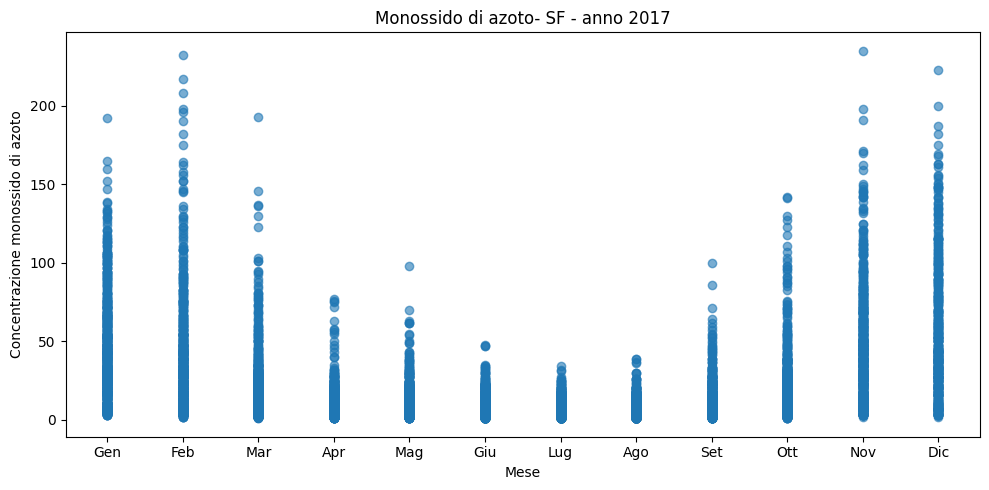

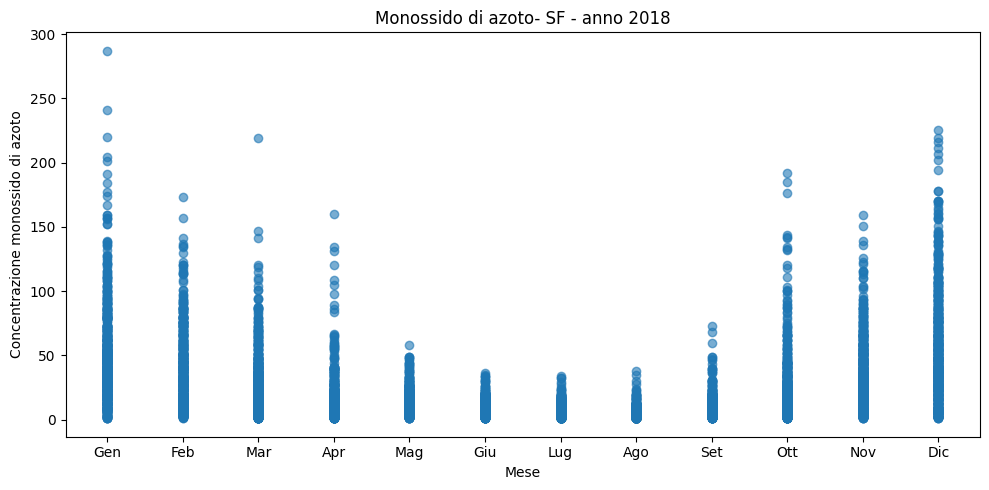

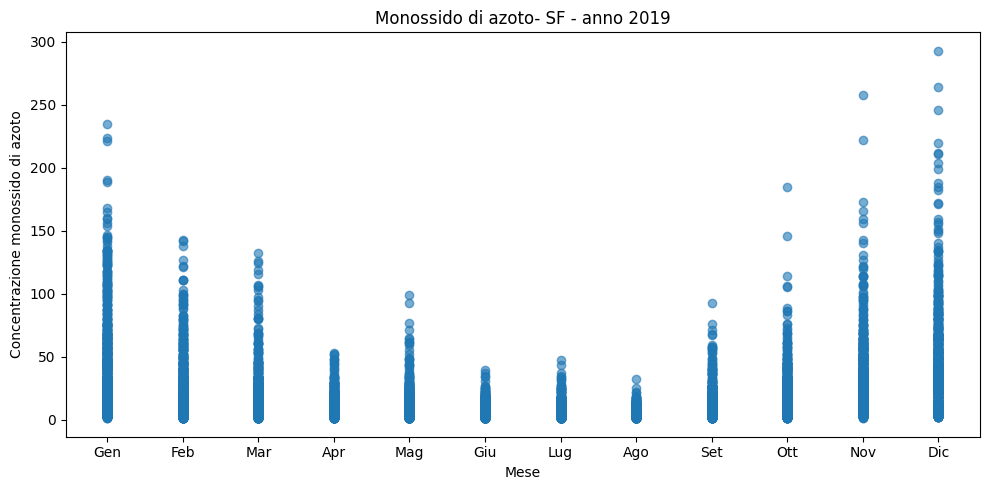

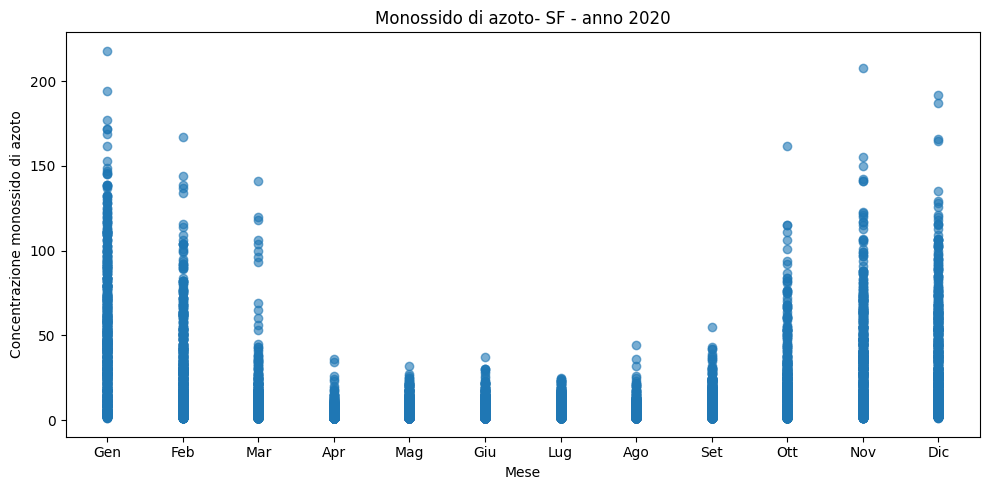

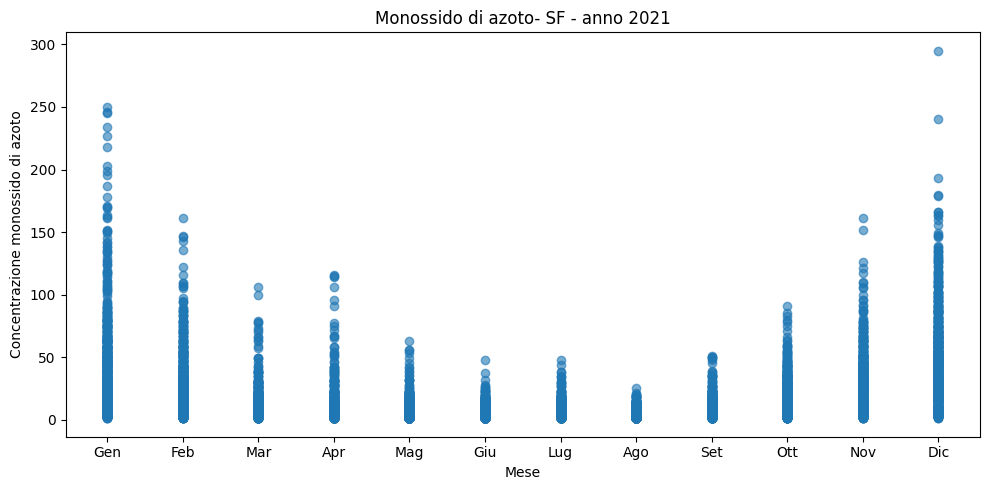

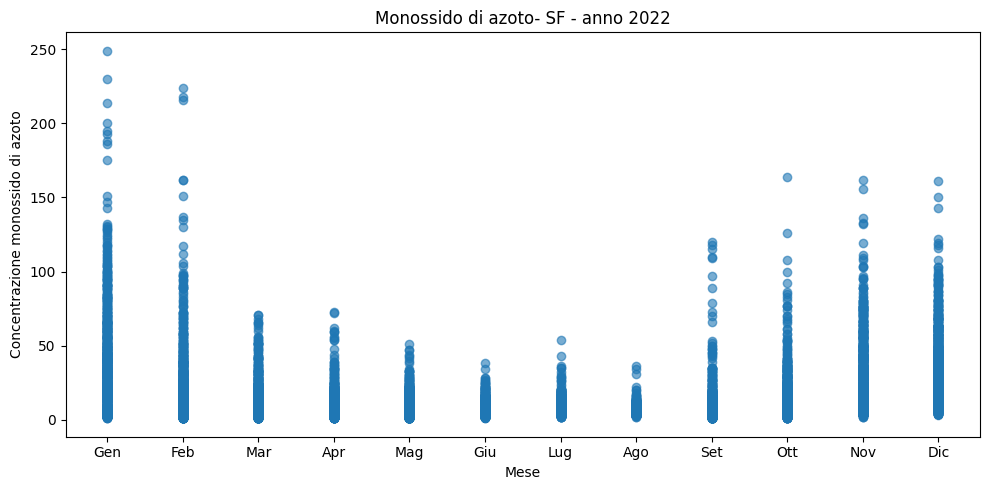

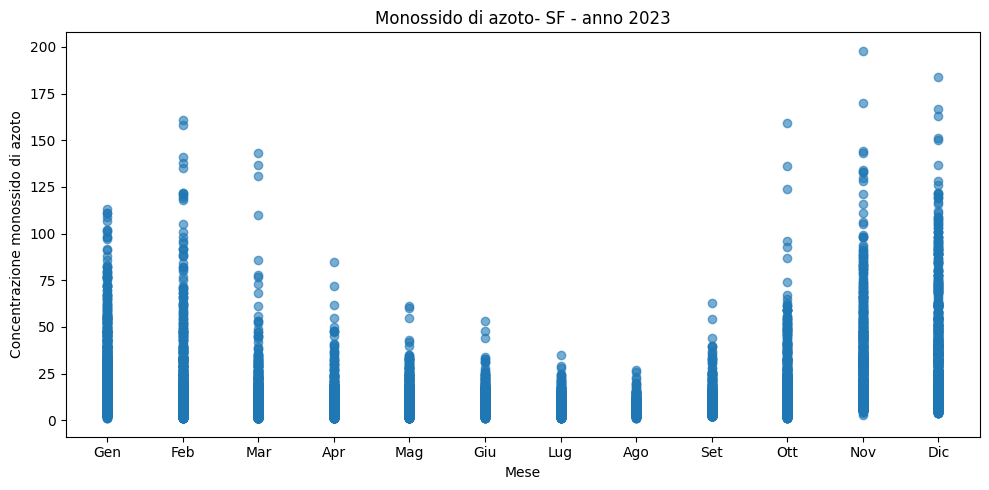

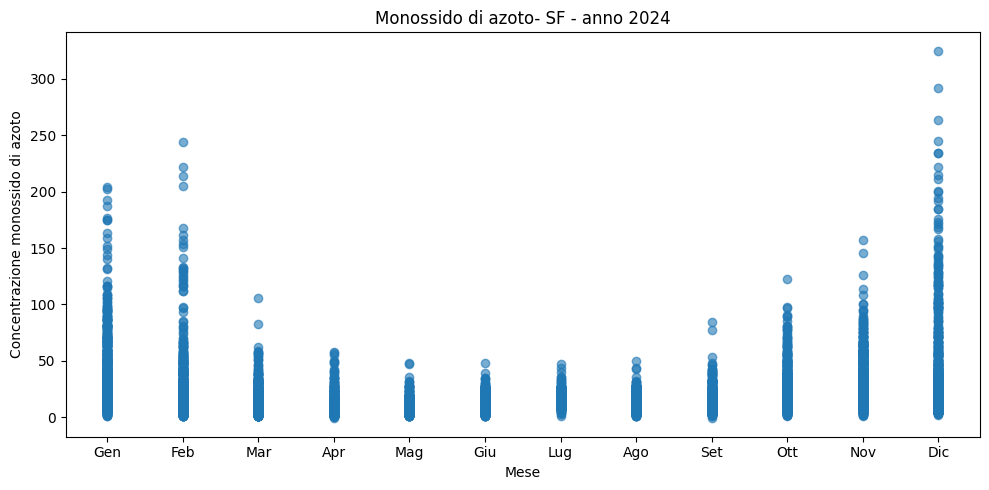

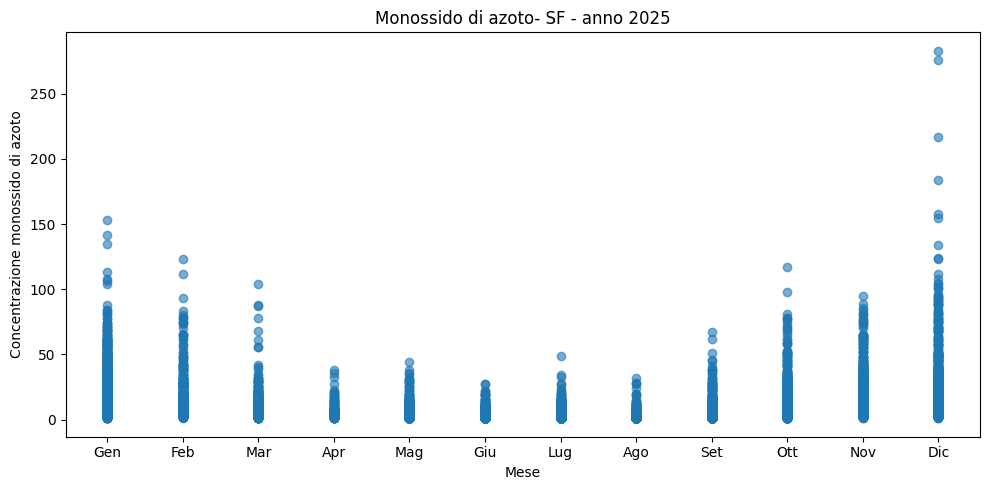

In [382]:

df_SF2["data_inizio"] = pd.to_datetime(df_SF2["data_inizio"], errors="coerce")
df_SF2["valore"] = pd.to_numeric(df_SF2["valore"], errors="coerce")

df_SF2["anno"] = df_SF2["data_inizio"].dt.year
df_SF2["mese"] = df_SF2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_SF2.loc[
        (df_SF2["anno"] == anno) &
        (df_SF2["agente"] == "NO (MONOSSIDO DI AZOTO)") &
        (df_SF2["valore"]),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione monossido di azoto")
    plt.title(f"Monossido di azoto- SF - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [383]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di benzene del 2023. creo df con solo questi valori

df_NO_daily = (
    df_SF_2023[df_SF_2023['agente'] ==  "NO (MONOSSIDO DI AZOTO)"]
    .groupby('giorno')['valore']
    .agg(
        media_NO='mean',
        mediana_NO='median',
        massimo_NO='max'
    )
    .reset_index()
)

df_NO_daily['media_NO'] = df_NO_daily['media_NO'].round(2)

In [384]:
#creo colonna mese_giorno
df_NO_daily["mese_giorno"] = (
    pd.to_datetime(df_NO_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [385]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_SF = df_filled_SF[df_filled_SF["mese_giorno"] != "02-29"].copy()
df_NO_daily = df_NO_daily[df_NO_daily["mese_giorno"] != "02-29"].copy()

In [386]:
# Creo mese_giorno corretto
df_filled_SF["giorno"] = pd.to_datetime(df_filled_SF["giorno"], errors="coerce")
df_filled_SF["mese_giorno"] = df_filled_SF["giorno"].dt.strftime("%m-%d")
df_filled_SF["anno"] = df_filled_SF["giorno"].dt.year

lista_NO_to_fill_mg = (
    pd.to_datetime(lista_NO_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe da storico/daily
mappa_media = df_NO_daily.groupby("mese_giorno")["media_NO"].median()
mappa_mediana = df_NO_daily.groupby("mese_giorno")["mediana_NO"].median()
mappa_max = df_NO_daily.groupby("mese_giorno")["massimo_NO"].median()

# Maschera: solo giorni della lista, solo anno 2025
mask_NO = (
    df_filled_SF["mese_giorno"].isin(lista_NO_to_fill_mg)
    & (df_filled_SF["anno"] == 2025)
)


df_filled_SF.loc[mask_NO, "media_NO"] = (
    df_filled_SF.loc[mask_NO, "mese_giorno"].map(mappa_media)
)

df_filled_SF.loc[mask_NO, "mediana_NO"] = (
    df_filled_SF.loc[mask_NO, "mese_giorno"].map(mappa_mediana)
)

df_filled_SF.loc[mask_NO, "massimo_NO"] = (
    df_filled_SF.loc[mask_NO, "mese_giorno"].map(mappa_max)
)

In [387]:
df_filled_SF.loc[df_filled_SF['media_NO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing


In [388]:
df_filled_SF['flag_NO_2023'] = df_filled_SF['giorno'].isin(pd.to_datetime(lista_NO_to_fill))
df_filled_SF.flag_NO_2023.value_counts()

flag_NO_2023
False    686
True      19
Name: count, dtype: int64

## CONTROLLO SF

In [389]:
df_filled_SF.loc[df_filled_SF['media_CO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


In [390]:
df_filled_SF.loc[df_filled_SF['media_NO'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


In [391]:
df_filled_SF.loc[df_filled_SF['media_NO2'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


In [392]:
df_filled_SF.loc[df_filled_SF['media_NOX'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


In [393]:
df_filled_SF.loc[df_filled_SF['media_C6H6'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


In [394]:
df_filled_SF.loc[df_filled_SF['PM2.5'].isna()]

,giorno,PM10,PM2.5,media_CO,mediana_CO,massimo_CO,media_NOX,mediana_NOX,massimo_NOX,media_NO2,mediana_NO2,massimo_NO2,media_NO,mediana_NO,massimo_NO,media_C6H6,mediana_C6H6,massimo_C6H6,flag_PM25_missing,flag_PM25_GM,flag_PM25_interpol,flag_NO2_missing,flag_NO2_GM,flag_C6H6_missing,mese_giorno,flag_C6H6_2023,flag_C6H6_interpol,flag_NOX_missing,flag_NOX_interpol,flag_NOX_2019,flag_CO_missing,anno,flag_CO_2023,flag_NO2_2023,flag_NO_missing,flag_NO_2023


## GM IMPUTAZIONE FINALE

Faccio un check sui missing rimasti

In [395]:
df_filled_GM.loc[df_filled_GM.media_NO2.isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF,flag_O3_missing,flag_O3_VC,flag_O3_interpol,flag_NO2_missing
565,2025-08-23,14.0,53.48,41.0,113.0,7.0,NaN,NaN,NaN,False,False,False,False,False,True
566,2025-08-24,16.0,43.33,44.5,70.0,5.0,NaN,NaN,NaN,False,False,False,False,False,True
567,2025-08-25,15.0,50.58,49.0,97.0,6.0,NaN,NaN,NaN,False,False,False,False,False,True
568,2025-08-26,17.0,66.21,60.0,119.0,9.0,NaN,NaN,NaN,False,False,False,False,False,True


In [396]:
df_filled_GM.media_NO2.isna().sum(), df_filled_GM.mediana_NO2.isna().sum(), df_filled_GM.massimo_NO2.isna().sum()

(np.int64(4), np.int64(4), np.int64(4))

In [397]:
df_filled_GM['PM2.5'].isna().sum()

np.int64(0)

In [398]:
df_filled_GM['media_O3'].isna().sum(), df_filled_GM['mediana_O3'].isna().sum(), df_filled_GM['massimo_O3'].isna().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [399]:
lista_NO2_to_fill = ['2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26']

### NO2

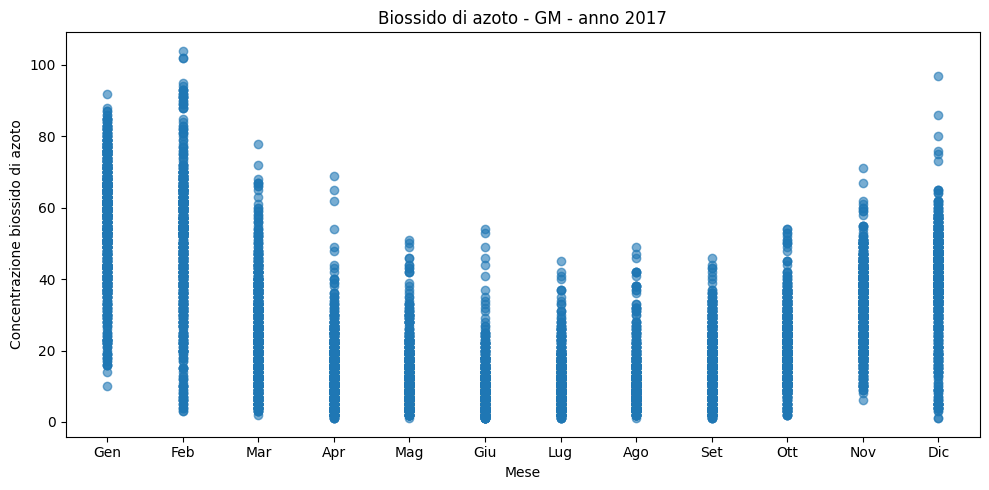

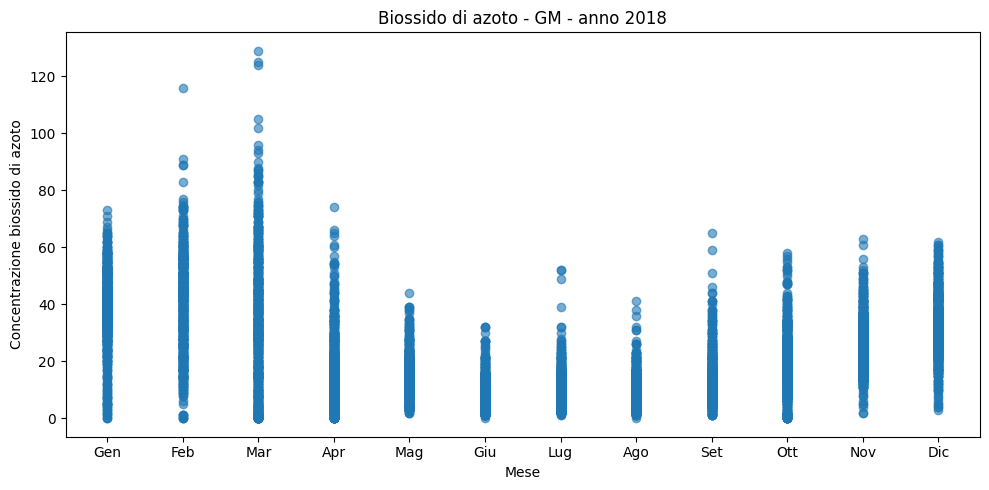

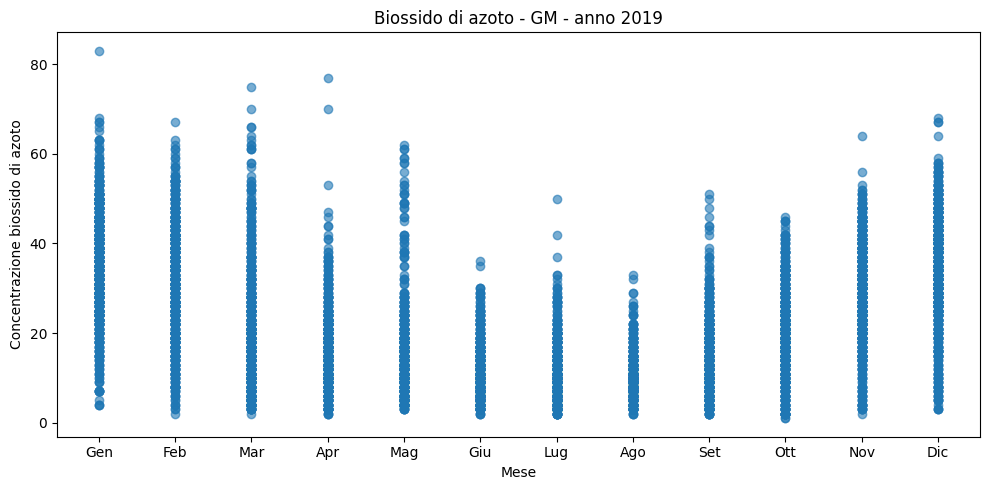

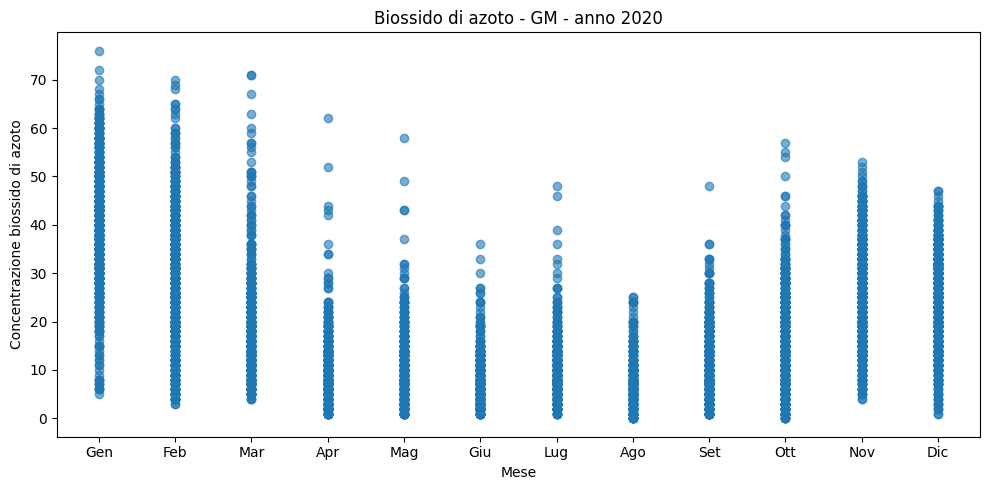

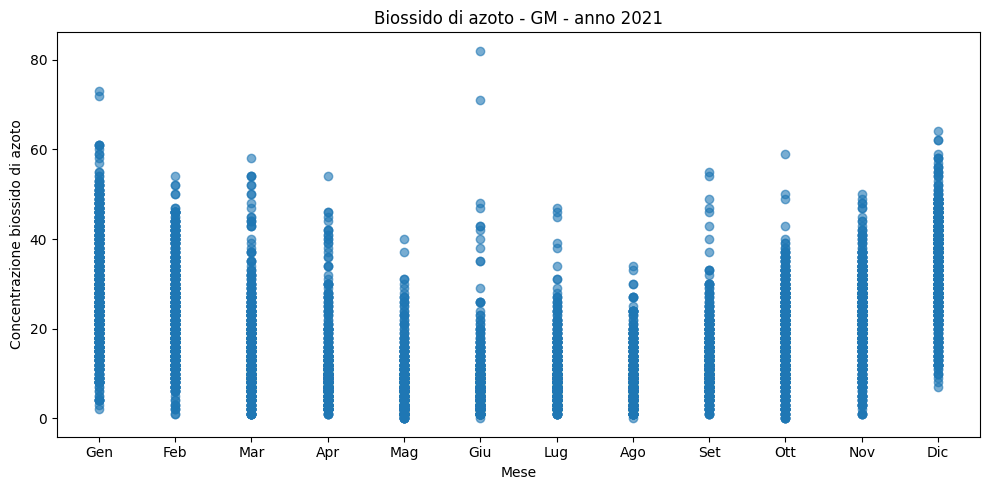

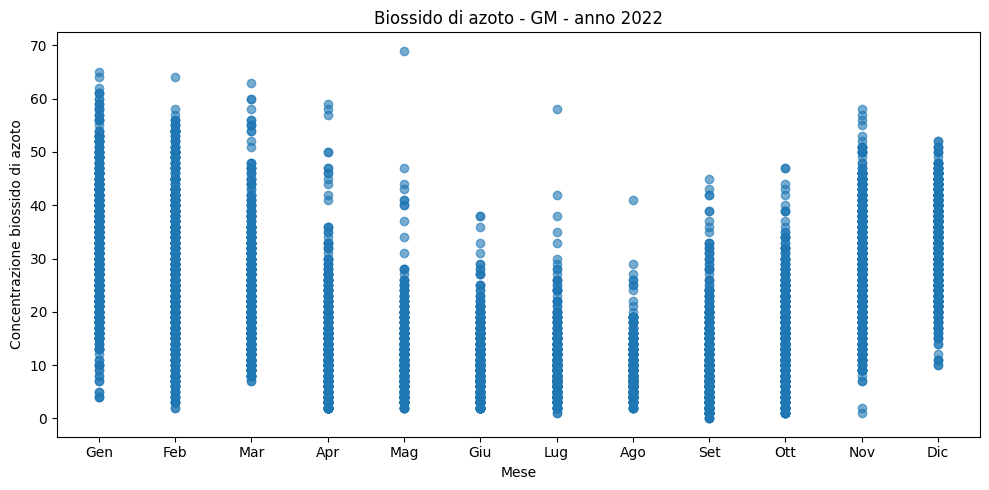

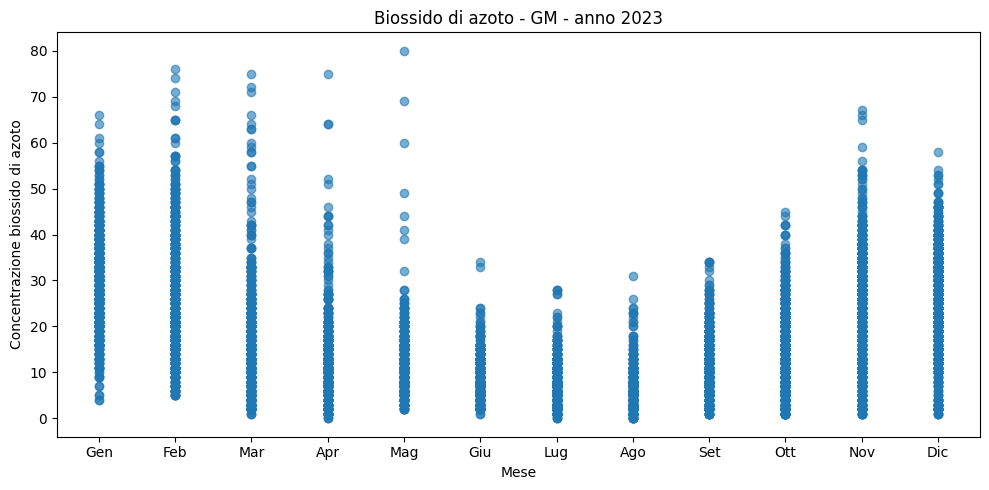

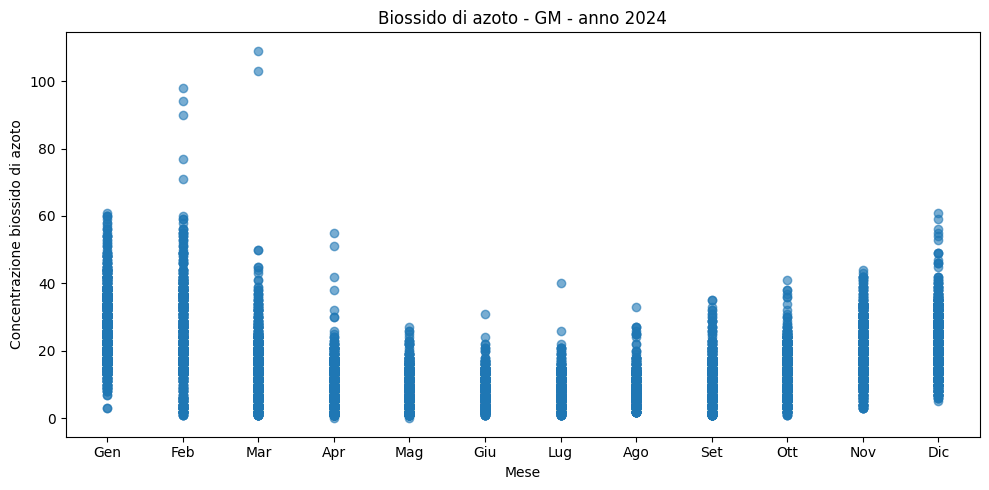

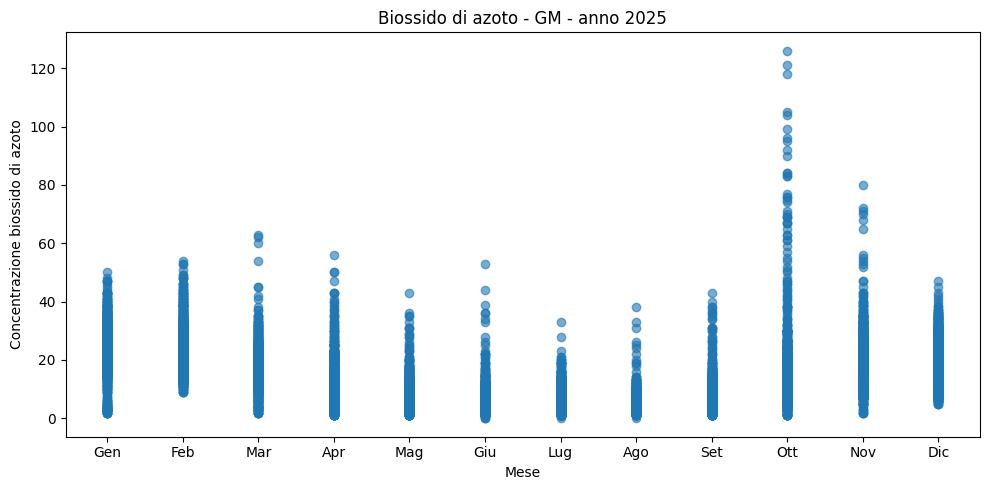

In [400]:
#stampo valori NO2 anni precedenti 

df_GM2["data_inizio"] = pd.to_datetime(df_GM2["data_inizio"], errors="coerce")
df_GM2["valore"] = pd.to_numeric(df_GM2["valore"], errors="coerce")

df_GM2["anno"] = df_GM2["data_inizio"].dt.year
df_GM2["mese"] = df_GM2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_GM2.loc[
        (df_GM2["anno"] == anno) &
        (df_GM2["agente"] == "NO2 (BIOSSIDO DI AZOTO)") &
        (df_GM2["valore"].notna()),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione biossido di azoto")
    plt.title(f"Biossido di azoto - GM - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()

In [401]:
df_GM2['giorno'] = df_GM2['data_inizio'].dt.date

df_GM_2023 = df_GM2.loc[df_GM2['data_inizio'].dt.year == 2023]


In [402]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di benzene del 2023. creo df con solo questi valori
df_NO2_daily = (
    df_GM_2023[df_GM_2023['agente'] == "NO2 (BIOSSIDO DI AZOTO)"]
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_NO2_daily['media_NO2'] = df_NO2_daily['media_NO2'].round(2)

In [403]:
df_GM_missing_NO2 =df_filled_GM.loc[df_filled_GM['media_NO2'].isna()]

df_GM_missing_NO2["mese_giorno"] = (
    pd.to_datetime(df_GM_missing_NO2["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_NO2_daily["mese_giorno"] = (
    pd.to_datetime(df_NO2_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [404]:
set_missing = set(df_GM_missing_NO2["mese_giorno"])
set_daily = set(df_NO2_daily["mese_giorno"])

intersezione = set_missing.intersection(set_daily)

len(sorted(intersezione))



4

In [405]:
# Creo mese_giorno corretto da giorno nel dataframe filled
df_filled_GM["mese_giorno"] = (
    pd.to_datetime(df_filled_GM["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)


In [406]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_GM = df_filled_GM[df_filled_GM["mese_giorno"] != "02-29"].copy()
df_NO2_daily = df_NO2_daily[df_NO2_daily["mese_giorno"] != "02-29"].copy()

In [407]:
# Anche la lista deve diventare MM-DD
lista_NO2_to_fill_mg = (
    pd.to_datetime(lista_NO2_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

print(lista_NO2_to_fill_mg)



['08-23', '08-24', '08-25', '08-26']


In [408]:
# Creo mese_giorno corretto
df_filled_GM["giorno"] = pd.to_datetime(df_filled_GM["giorno"], errors="coerce")
df_filled_GM["mese_giorno"] = df_filled_GM["giorno"].dt.strftime("%m-%d")
df_filled_GM["anno"] = df_filled_GM["giorno"].dt.year

df_NO2_daily["mese_giorno"] = (
    pd.to_datetime(df_NO2_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

lista_NO2_to_fill_mg = (
    pd.to_datetime(lista_NO2_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe da storico/daily
mappa_media = df_NO2_daily.groupby("mese_giorno")["media_NO2"].median()
mappa_mediana = df_NO2_daily.groupby("mese_giorno")["mediana_NO2"].median()
mappa_max = df_NO2_daily.groupby("mese_giorno")["massimo_NO2"].median()

# Maschera: solo giorni della lista, solo anno 2025
mask_NO2 = (
    df_filled_GM["mese_giorno"].isin(lista_NO2_to_fill_mg)
    & (df_filled_GM["anno"] == 2025)
)


df_filled_GM.loc[mask_NO2, "media_NO2"] = (
    df_filled_GM.loc[mask_NO2, "mese_giorno"].map(mappa_media)
)

df_filled_GM.loc[mask_NO2, "mediana_NO2"] = (
    df_filled_GM.loc[mask_NO2, "mese_giorno"].map(mappa_mediana)
)

df_filled_GM.loc[mask_NO2, "massimo_NO2"] = (
    df_filled_GM.loc[mask_NO2, "mese_giorno"].map(mappa_max)
)

In [409]:
df_filled_GM.loc[df_filled_GM['media_NO2'].isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF,flag_O3_missing,flag_O3_VC,flag_O3_interpol,flag_NO2_missing,mese_giorno,anno


In [410]:
df_filled_GM['flag_NO2_2023'] = df_filled_GM['giorno'].isin(pd.to_datetime(lista_NO2_to_fill))

df_filled_GM.flag_NO2_2023.value_counts()

flag_NO2_2023
False    687
True       4
Name: count, dtype: int64

## CONTROLLO GM

In [411]:
df_filled_GM.loc[df_filled_GM.media_NO2.isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,PM2.5,media_NO2,mediana_NO2,massimo_NO2,flag_PM25_missing,flag_PM25_SF,flag_O3_missing,flag_O3_VC,flag_O3_interpol,flag_NO2_missing,mese_giorno,anno,flag_NO2_2023


## VC IMPUTAZIONE FINALE

Controllo di non avere missing O3

In [412]:
df_filled_VC.loc[df_filled_VC['media_O3'].isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2,flag_O3_missing,flag_O3_GM,flag_NO2_missing,flag_NO2_VC


### NO2

In [413]:
df_filled_VC.loc[df_filled_VC['media_NO2'].isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2,flag_O3_missing,flag_O3_GM,flag_NO2_missing,flag_NO2_VC
563,2025-08-19,14.0,83.83,87.0,131.0,NaN,NaN,NaN,False,False,True,False
564,2025-08-20,21.0,65.54,66.5,125.0,NaN,NaN,NaN,False,False,True,False
565,2025-08-21,17.0,29.17,24.0,67.0,NaN,NaN,NaN,False,False,True,False
566,2025-08-22,11.0,67.08,68.5,131.0,NaN,NaN,NaN,False,False,True,False
567,2025-08-23,11.0,63.54,49.0,128.0,NaN,NaN,NaN,False,False,True,False
568,2025-08-24,12.0,52.25,52.0,81.0,NaN,NaN,NaN,False,False,True,False
569,2025-08-25,12.0,53.50,52.0,116.0,NaN,NaN,NaN,False,False,True,False
570,2025-08-26,14.0,71.12,67.5,134.0,NaN,NaN,NaN,False,False,True,False


In [414]:
df_filled_VC.media_NO2.isna().sum(),df_filled_VC.media_NO2.isna().sum(), df_filled_VC.massimo_NO2.isna().sum()

(np.int64(8), np.int64(8), np.int64(8))

In [415]:
df_filled_VC.loc[df_filled_VC['media_NO2'].isna()]['giorno']

563   2025-08-19
564   2025-08-20
565   2025-08-21
566   2025-08-22
567   2025-08-23
568   2025-08-24
569   2025-08-25
570   2025-08-26
Name: giorno, dtype: datetime64[s]

In [416]:
lista_NO2_to_fill = ['2025-05-17', '2025-05-18', '2025-06-24', '2025-08-19', '2025-08-20', '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24', '2025-08-25', '2025-08-26', '2025-08-27']

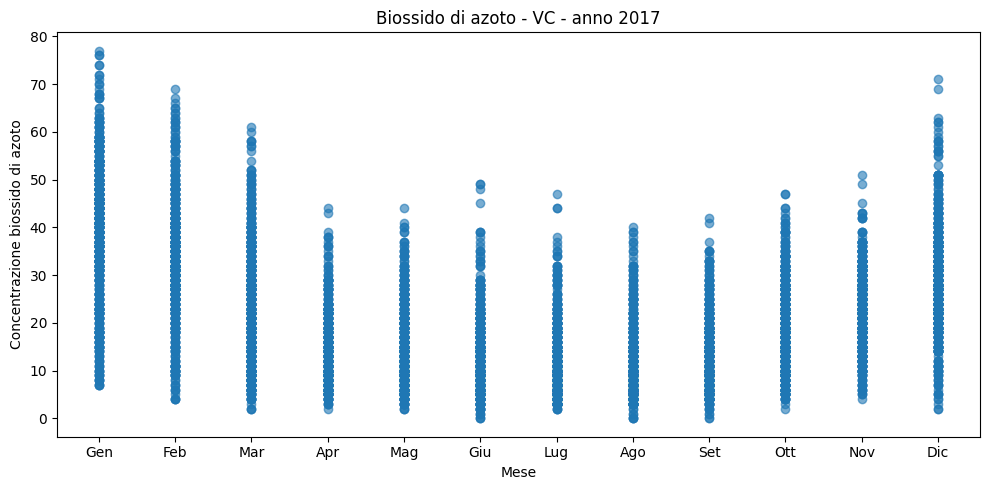

2017 (8160, 2)


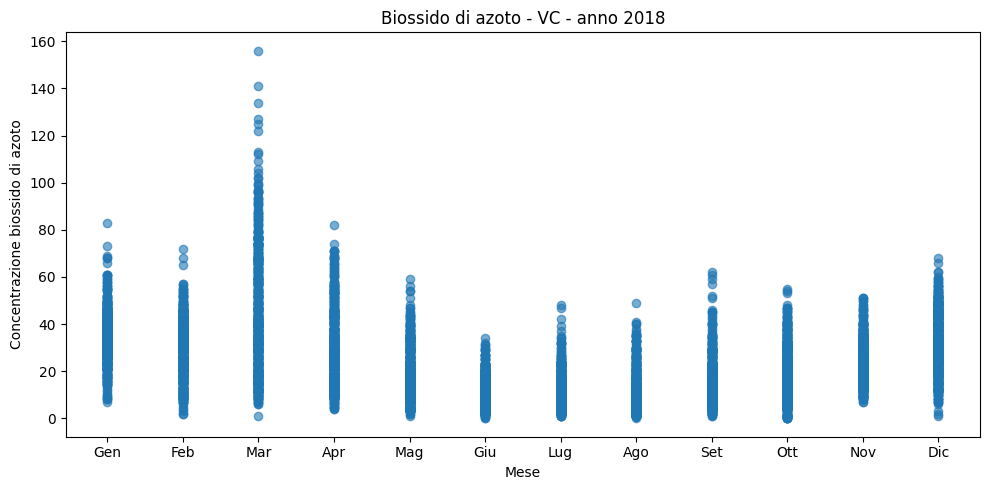

2018 (8307, 2)


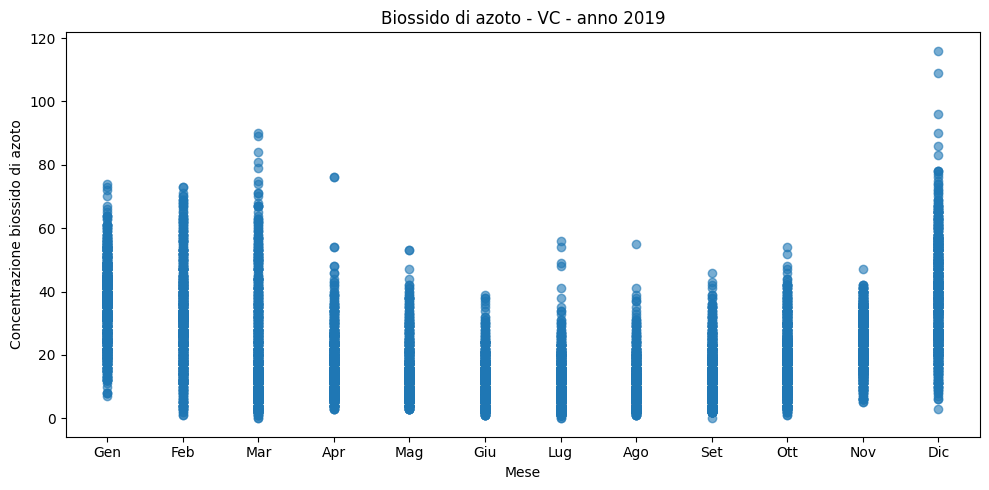

2019 (8372, 2)


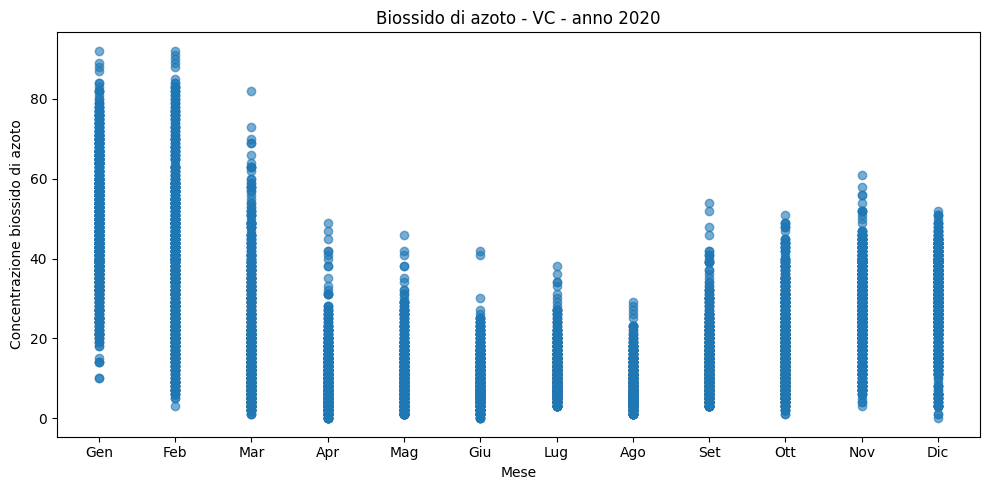

2020 (8605, 2)


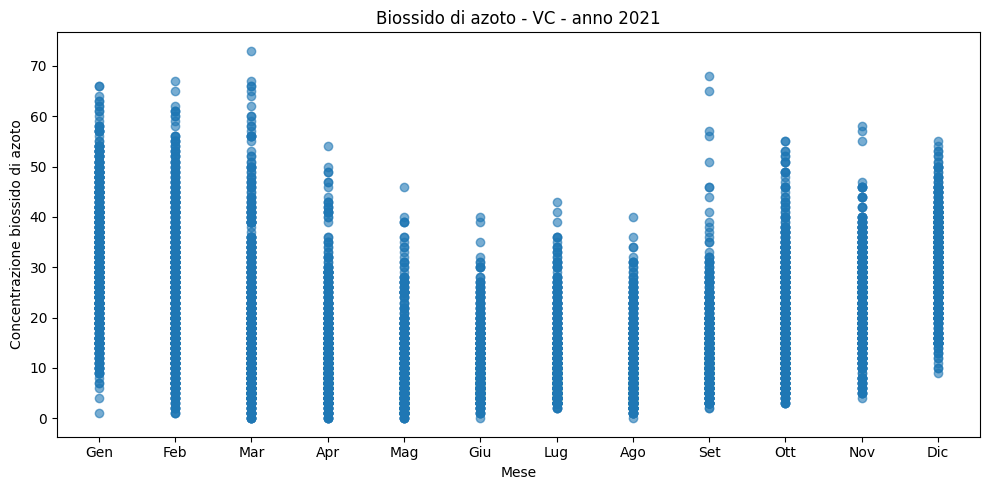

2021 (8545, 2)


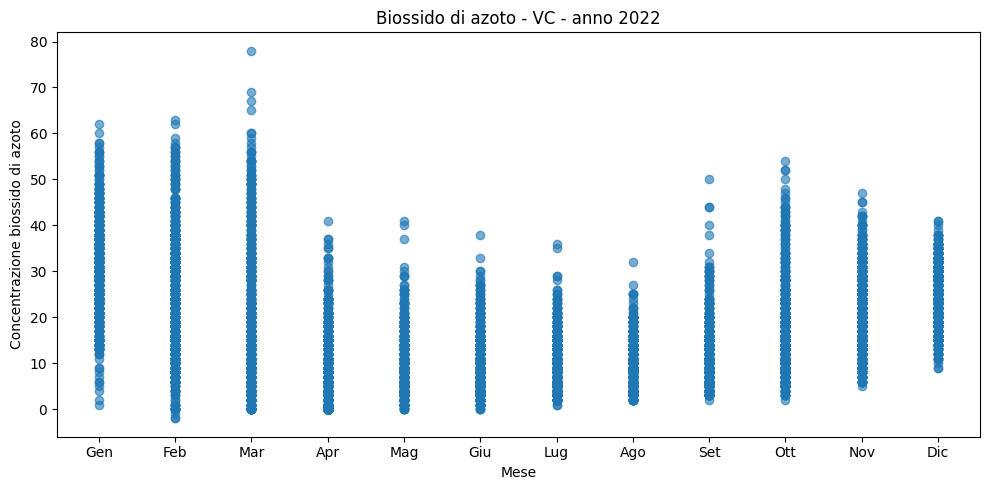

2022 (8693, 2)


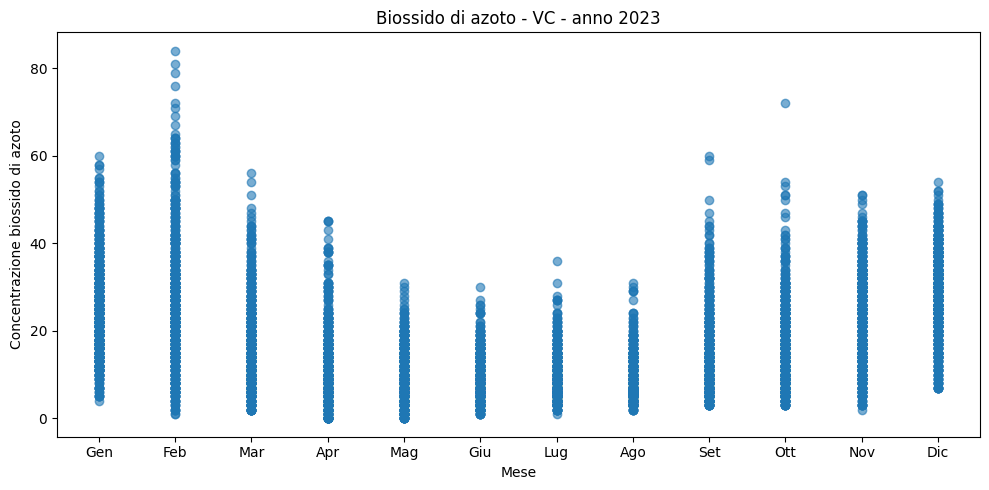

2023 (8719, 2)


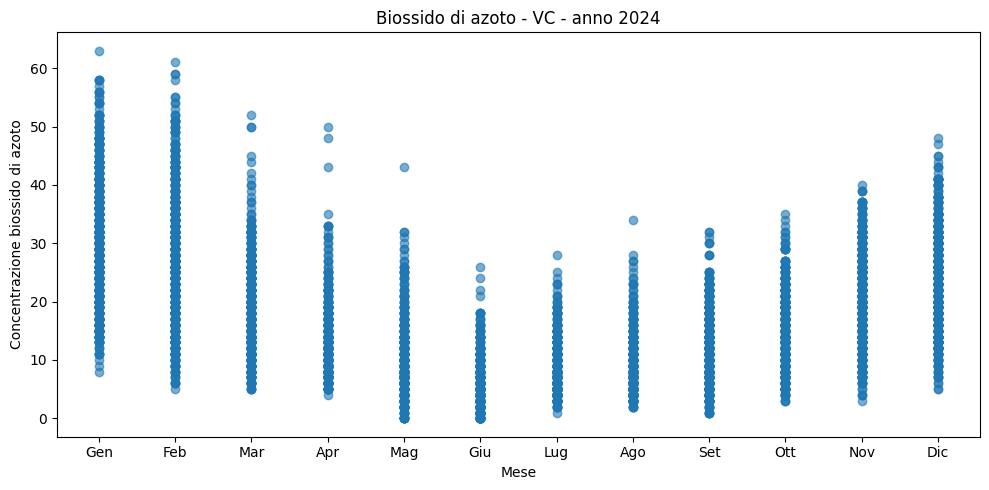

2024 (8731, 2)


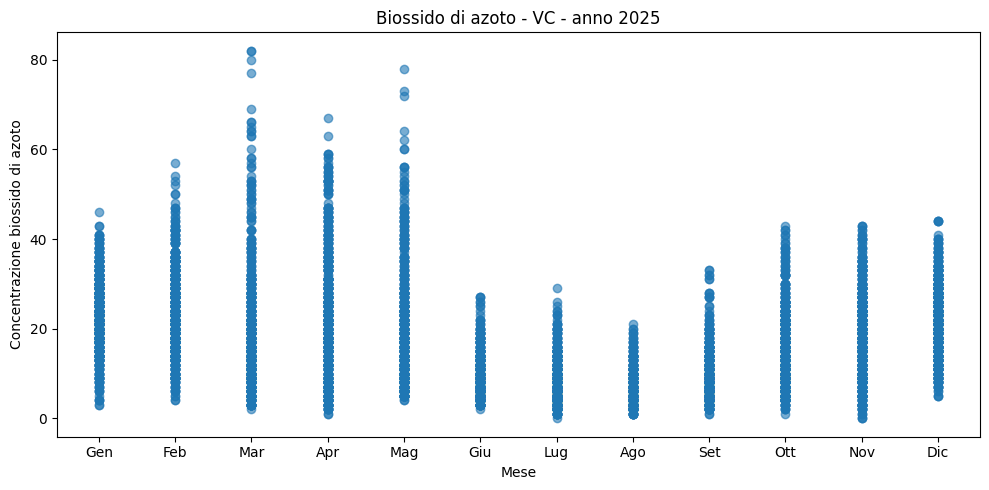

2025 (8176, 2)


In [417]:
#stampo valori NO2 anni precedenti 
df_VC2["data_inizio"] = pd.to_datetime(df_VC2["data_inizio"], errors="coerce")
df_VC2["valore"] = pd.to_numeric(df_VC2["valore"], errors="coerce")

df_VC2["anno"] = df_VC2["data_inizio"].dt.year
df_VC2["mese"] = df_VC2["data_inizio"].dt.month



for anno in lista_anni:
    dati_anno = df_VC2.loc[
        (df_VC2["anno"] == anno) &
        (df_VC2["agente"] == "NO2 (BIOSSIDO DI AZOTO)") &
        (df_VC2["valore"].notna()),
        ["mese", "valore"]
    ]

    plt.figure(figsize=(10, 5))

    plt.scatter(
        dati_anno["mese"],
        dati_anno["valore"],
        alpha=0.6
    )

    plt.xlabel("Mese")
    plt.ylabel("Concentrazione biossido di azoto")
    plt.title(f"Biossido di azoto - VC - anno {int(anno)}")

    plt.xticks(
        ticks=range(1, 13),
        labels=[
            "Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
            "Lug", "Ago", "Set", "Ott", "Nov", "Dic"
        ]
    )

    plt.tight_layout()
    plt.show()
    
    dati_anno = df_VC2.loc[
        (df_VC2["anno"] == anno) &
        (df_VC2["agente"] == "NO2 (BIOSSIDO DI AZOTO)") &
        (df_VC2["valore"].notna()),
        ["mese", "valore"]
    ]

    print(anno, dati_anno.shape)

In [418]:
#dopo aver osservato le distribuzioni, scelgo di riempire con i valori di NO2 del 2023. creo df con solo questi valori

df_VC2['giorno'] = df_VC2['data_inizio'].dt.date

df_VC_2023 = df_VC2.loc[df_VC2['data_inizio'].dt.year == 2023]

df_NO2_daily = (
    df_VC_2023[df_VC_2023['agente'] == "NO2 (BIOSSIDO DI AZOTO)"]
    .groupby('giorno')['valore']
    .agg(
        media_NO2='mean',
        mediana_NO2='median',
        massimo_NO2='max'
    )
    .reset_index()
)

df_NO2_daily['media_NO2'] = df_NO2_daily['media_NO2'].round(2)

In [419]:
df_VC_missing_NO2 =df_filled_VC.loc[df_filled_VC['media_NO2'].isna()]

df_VC_missing_NO2["mese_giorno"] = (
    pd.to_datetime(df_VC_missing_NO2["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

df_NO2_daily["mese_giorno"] = (
    pd.to_datetime(df_NO2_daily["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)
# Creo mese_giorno corretto da giorno nei dataframe filled
df_filled_VC["mese_giorno"] = (
    pd.to_datetime(df_filled_VC["giorno"], errors="coerce")
    .dt.strftime("%m-%d")
)

In [420]:
#escludo il 29 febbraio che mi dà pb e che comunque non è missing
df_filled_VC = df_filled_VC[df_filled_VC["mese_giorno"] != "02-29"].copy()
df_NO2_daily = df_NO2_daily[df_NO2_daily["mese_giorno"] != "02-29"].copy()

In [421]:
# Creo mese_giorno corretto
df_filled_VC["giorno"] = pd.to_datetime(df_filled_VC["giorno"], errors="coerce")
df_filled_VC["mese_giorno"] = df_filled_VC["giorno"].dt.strftime("%m-%d")
df_filled_VC["anno"] = df_filled_VC["giorno"].dt.year

#anche la lista deve diventare mese-giorno
lista_NO2_to_fill_mg = (
    pd.to_datetime(lista_NO2_to_fill, errors="coerce")
    .strftime("%m-%d")
    .tolist()
)

# Mappe da storico/daily
mappa_media = df_NO2_daily.groupby("mese_giorno")["media_NO2"].median()
mappa_mediana = df_NO2_daily.groupby("mese_giorno")["mediana_NO2"].median()
mappa_max = df_NO2_daily.groupby("mese_giorno")["massimo_NO2"].median()

# Maschera: solo giorni della lista, solo anno 2025
mask_NO2 = (
    df_filled_VC["mese_giorno"].isin(lista_NO2_to_fill_mg)
    & (df_filled_VC["anno"] == 2025)
)


df_filled_VC.loc[mask_NO2, "media_NO2"] = (
    df_filled_VC.loc[mask_NO2, "mese_giorno"].map(mappa_media)
)

df_filled_VC.loc[mask_NO2, "mediana_NO2"] = (
    df_filled_VC.loc[mask_NO2, "mese_giorno"].map(mappa_mediana)
)

df_filled_VC.loc[mask_NO2, "massimo_NO2"] = (
    df_filled_VC.loc[mask_NO2, "mese_giorno"].map(mappa_max)
)

In [422]:
df_filled_VC['flag_NO2_2023'] = df_filled_VC['giorno'].isin(pd.to_datetime(lista_NO2_to_fill))
df_filled_VC.flag_NO2_2023.value_counts()

flag_NO2_2023
False    679
True      12
Name: count, dtype: int64

## CONTROLLO VC

In [423]:
df_filled_VC.loc[df_filled_VC.media_NO2.isna()]

,giorno,PM10,media_O3,mediana_O3,massimo_O3,media_NO2,mediana_NO2,massimo_NO2,flag_O3_missing,flag_O3_GM,flag_NO2_missing,flag_NO2_VC,mese_giorno,anno,flag_NO2_2023


# ESPORTO DF FILLED

In [424]:
df_filled_SF.to_parquet(os.path.join(data_dir,"df_filled_SF.parquet"))
df_filled_GM.to_parquet(os.path.join(data_dir,"df_filled_GM.parquet"))
df_filled_VC.to_parquet(os.path.join(data_dir,"df_filled_VC.parquet"))